In [1]:
import json
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import ast

ROOT_dir = Path('/Users/jliu/workspace/RAG/results/selection/neuron')

In [2]:

def zipf_analysis(
    values: list[float], 
    fit_mode: str = "linear_region",
    linear_region: tuple[float, float] = (2.0, 5.0)
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray] | None:
    """
    Analyze values using Zipf's law with configurable fitting approach.
    
    Parameters:
    -----------
    values: Input values to analyze
    fit_mode: "linear_region" or "whole" - controls fitting approach
    linear_region: Log rank range (min, max) to use for linear region fitting
    
    Returns:
    --------
    Tuple of (log_ranks, log_vals, zipf_line, coeffs) or None if analysis fails
    """
    arr = np.array(values)
    
    # Handle different data types and structures
    if arr.ndim > 1:
        arr = arr.flatten()
    
    # Remove non-finite values and take absolute values
    arr = arr[np.isfinite(arr)]
    abs_vals = np.abs(arr)
    
    # Filter out zero values (can't take log of zero)
    positive_vals = abs_vals[abs_vals > 0]
  
    # Check if we have enough valid data points
    if len(positive_vals) < 10:
        print(f"Warning: Only {len(positive_vals)} positive values found, skipping analysis")
        return None
    
    sorted_vals = np.sort(positive_vals)[::-1]  # Sort in descending order
    ranks = np.arange(1, len(sorted_vals) + 1)
    log_ranks = np.log(ranks)
    log_vals = np.log(sorted_vals)
    
    # Choose fitting approach based on fit_mode
    if fit_mode == "linear_region":
        # Define linear region for fitting
        min_log_rank, max_log_rank = linear_region
        linear_mask = (log_ranks >= min_log_rank) & (log_ranks <= max_log_rank)
        
        # Check if we have enough points in the linear region
        if np.sum(linear_mask) < 5:
            print(f"Warning: Only {np.sum(linear_mask)} points in linear region, skipping analysis")
            return None
        
        # Fit linear model only to the linear region
        coeffs = np.polyfit(log_ranks[linear_mask], log_vals[linear_mask], deg=1)
    
    elif fit_mode == "whole":
        # Fit to the entire range
        coeffs = np.polyfit(log_ranks, log_vals, deg=1)
    
    else:
        raise ValueError(f"Invalid fit_mode: {fit_mode}. Use 'linear_region' or 'whole'")
    
    # Generate line for the entire range for visualization
    zipf_line = np.poly1d(coeffs)(log_ranks)
    
    return log_ranks, log_vals, zipf_line, coeffs



In [3]:
def plot_zipf_distribution(
    log_ranks: np.ndarray,
    log_vals: np.ndarray,
    zipf_line: np.ndarray,
    coeffs: np.ndarray,
    label: str,
    color: str,  # <-- NEW PARAMETER
    fit_mode: str = "linear_region",
    linear_region: tuple[float, float] = (2.0, 5.0),
    ylim: tuple[float, float] | None = None
) -> None:
    """Plot a Zipf distribution on an existing figure."""
    
    # Plot data points
    plt.plot(log_ranks, log_vals, 'o', color=color, alpha=0.5, markersize=4)

    # Highlight the linear region used for fitting if applicable
    if fit_mode == "linear_region":
        min_log_rank, max_log_rank = linear_region
        linear_mask = (log_ranks >= min_log_rank) & (log_ranks <= max_log_rank)
        if np.any(linear_mask):
            plt.plot(log_ranks[linear_mask], log_vals[linear_mask], 'o', 
                     color=color, alpha=0.8, markersize=5)

    # Plot fitted Zipf line
    plt.plot(log_ranks, zipf_line, '-', color=color, linewidth=2, label=label)

    # Styling stays the same
    plt.xlabel('Log Rank', fontsize=12)
    plt.ylabel('Log Value', fontsize=12)
    plt.grid(True, alpha=0.3)
    if ylim is not None:
        plt.ylim(ylim)


In [4]:

def load_data(file_path,y_col = "abs_delta_loss_post_ablation",linear_region=(2.0,5.0)):
    df = pd.read_csv(file_path)
    df[y_col] = df[y_col].apply(ast.literal_eval)
    df["step"] = df["step"].astype(int)  # Convert to int for proper sorting

    # Sort by step to ensure proper ordering
    df = df.sort_values('step')
    row = df.iloc[-1]
    step = row["step"]
    vals = row[y_col]

    # Perform Zipf analysis
    fit_mode = "linear_region"
    analysis_result = zipf_analysis(vals, fit_mode, linear_region)
    log_ranks, log_vals, zipf_line, coeffs = analysis_result
    return log_ranks, log_vals, zipf_line, coeffs
                    
 

In [27]:
def plot_all(interval,model,y_col = "delta_loss_post",linear_region=(3, 5)):

    min_pct = 0
    max_pct = interval
    file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
    print(len(log_vals_longtail))
    plt.figure(figsize=(8, 6))

    # Longtail_50 — use red
    plot_zipf_distribution(
        log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
        label="longtail", color="red", linear_region=linear_region
    )
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.title(f"{min_pct}_{max_pct}_{model}")
    plt.show()

    min_pct = 100 - interval
    max_pct = 100
    file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
    print(len(log_vals_longtail))
    plt.figure(figsize=(8, 6))

    # Longtail_50 — use red
    plot_zipf_distribution(
        log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
        label="longtail", color="red", linear_region=linear_region
    )
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.title(f"{min_pct}_{max_pct}_{model}")
    plt.show()



1727


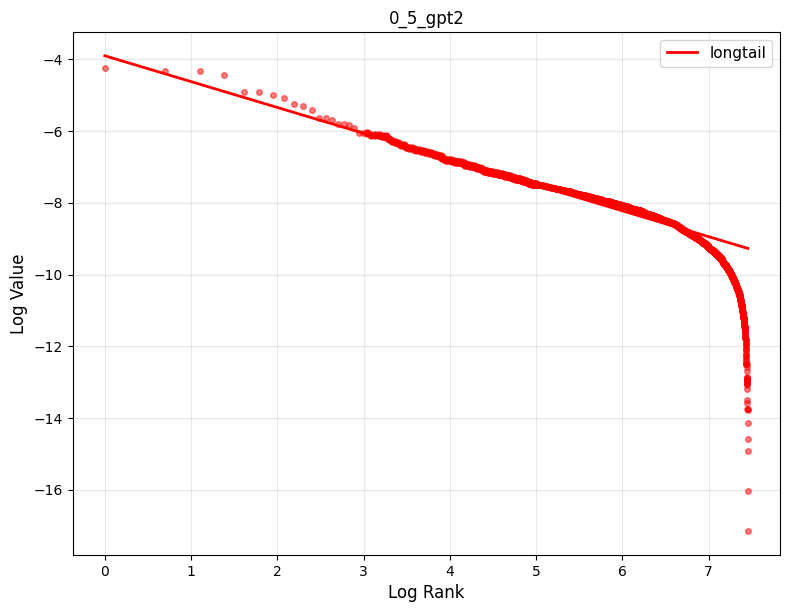

1579


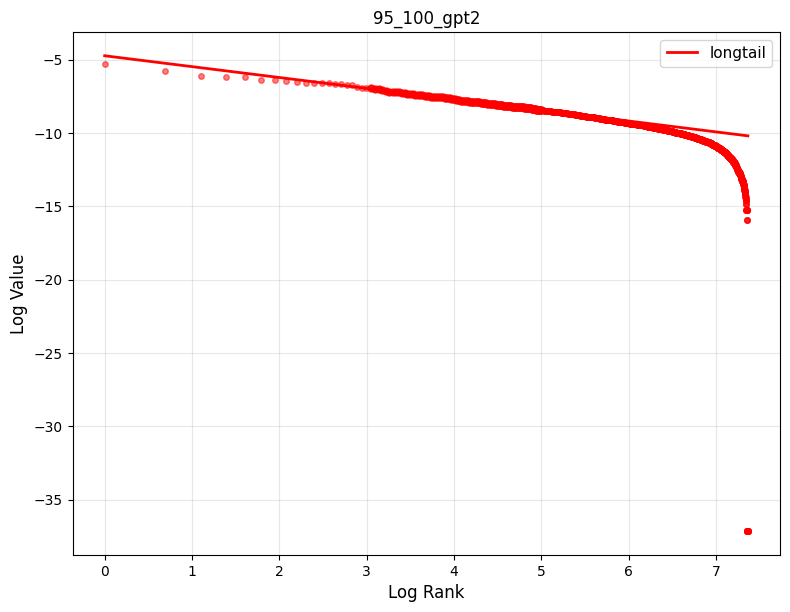

2105


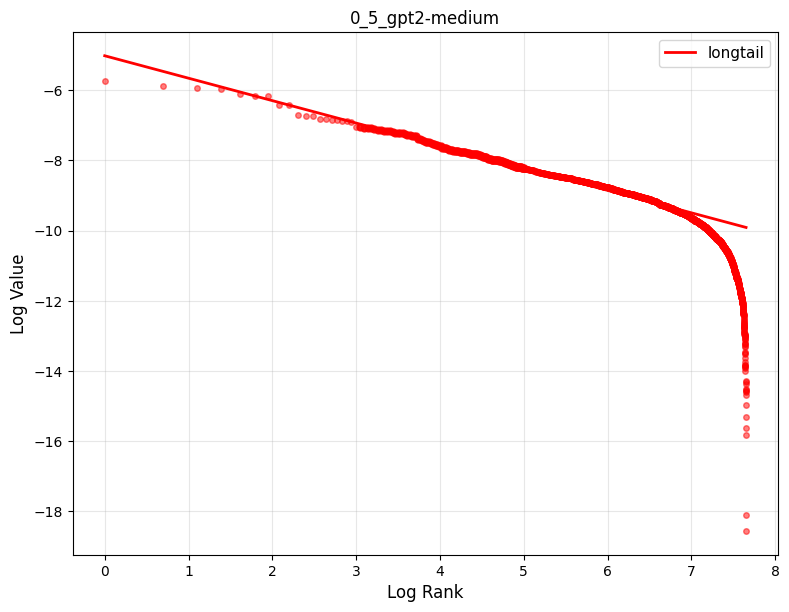

2062


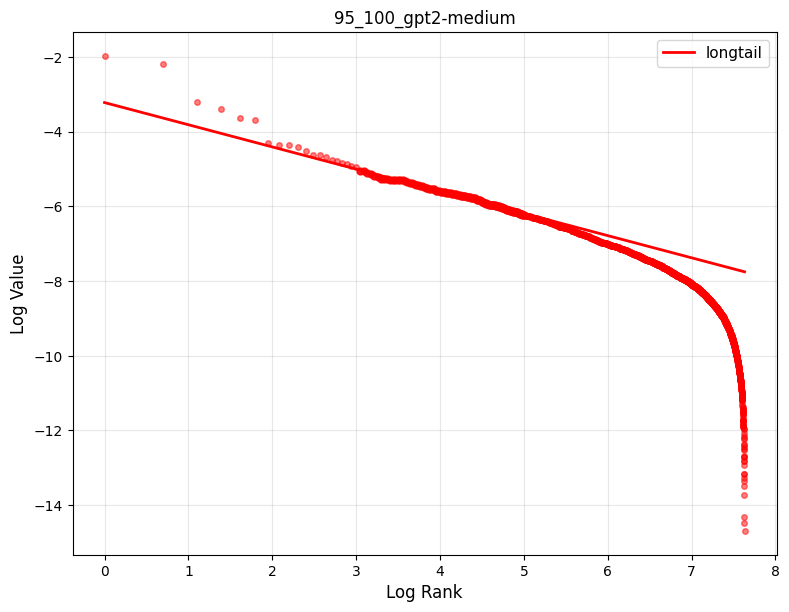

2652


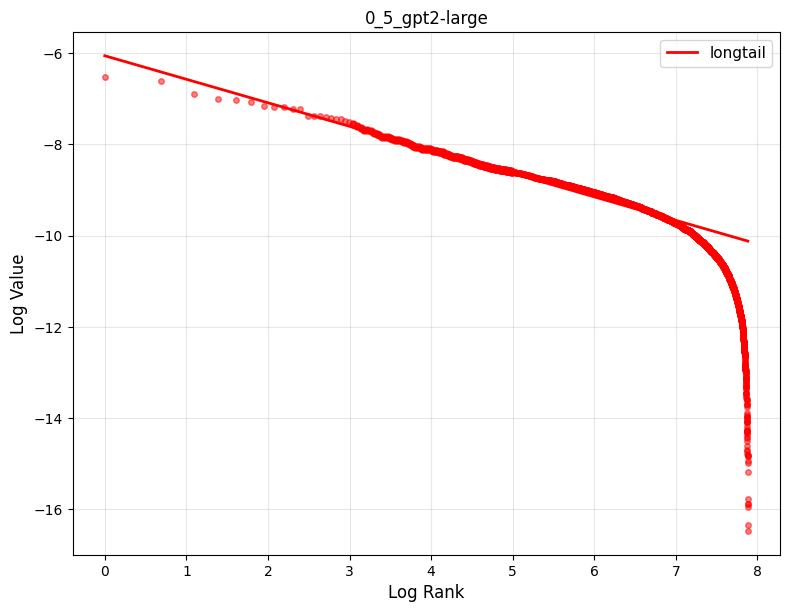

2763


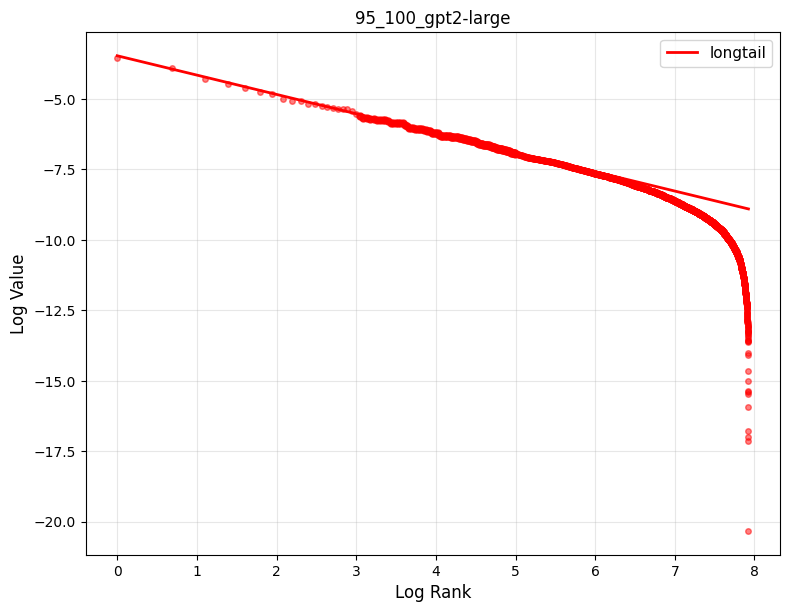

3233


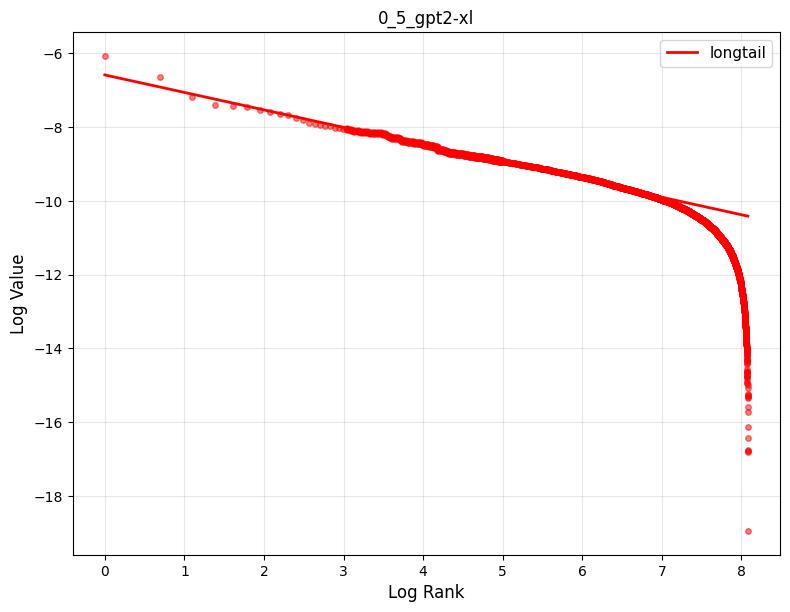

3441


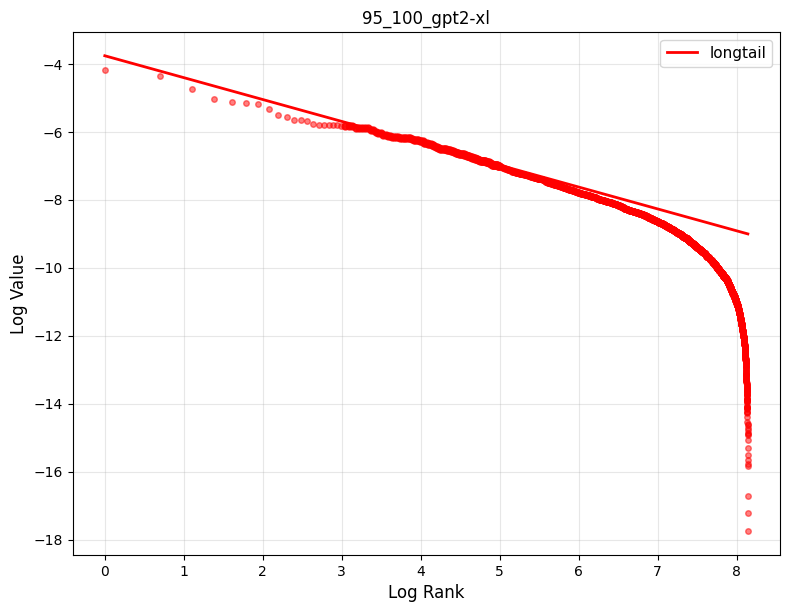

Have not got results of 5: EleutherAI/pythia-70m-deduped
Have not got results of 5: EleutherAI/pythia-160m-deduped
Have not got results of 5: EleutherAI/pythia-410m-deduped
2041


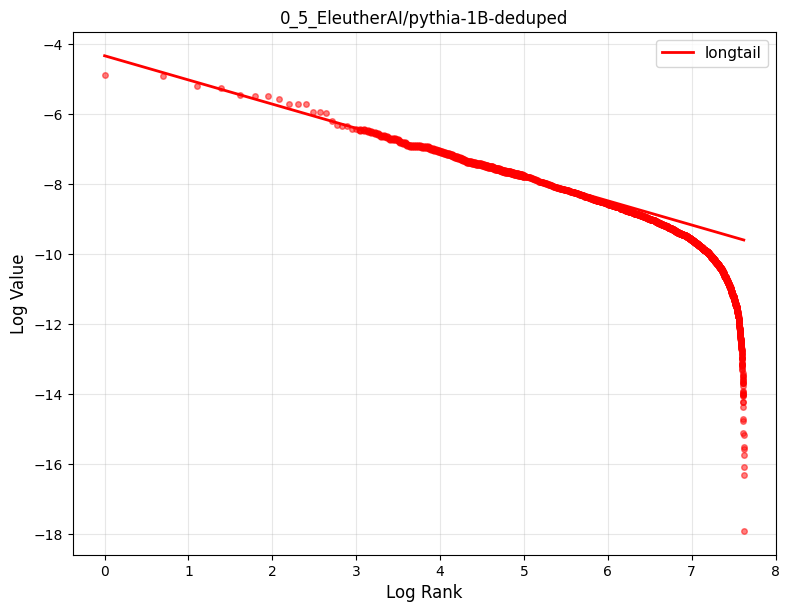

457


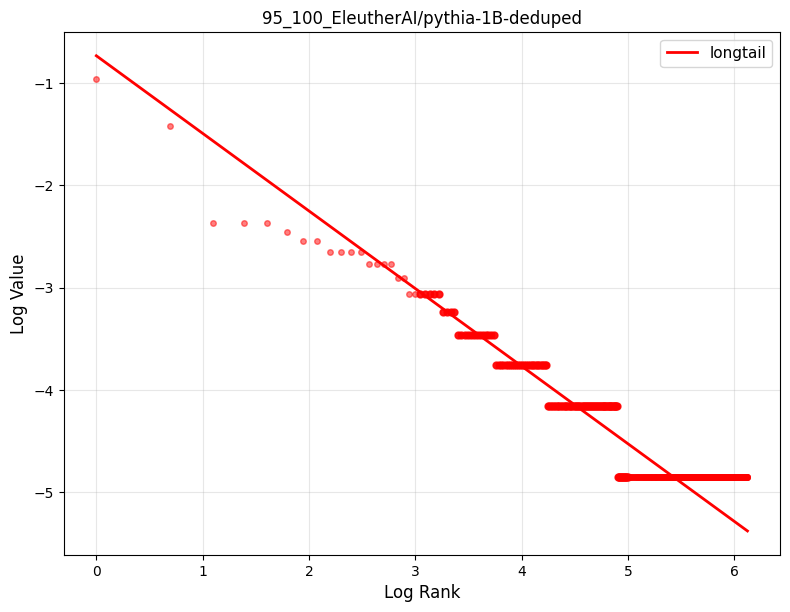

3417


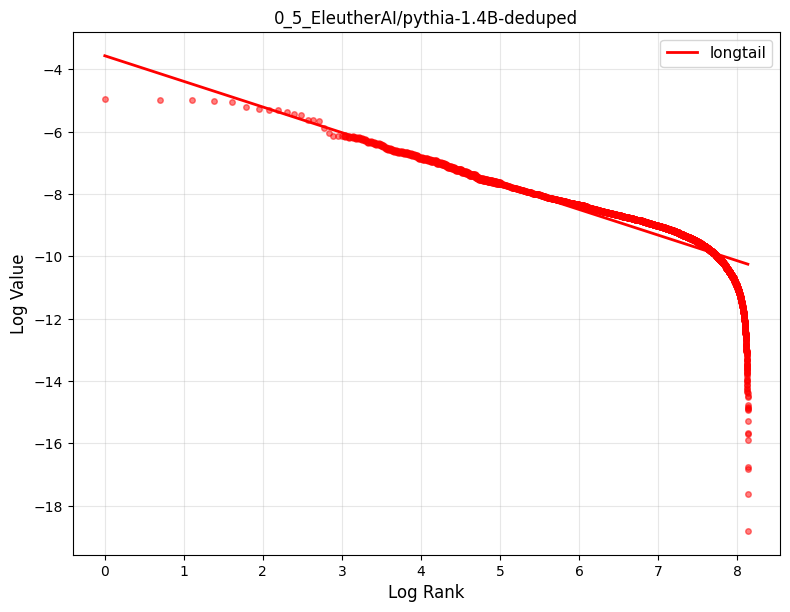

Have not got results of 5: EleutherAI/pythia-1.4B-deduped
Have not got results of 5: EleutherAI/pythia-2.8B-deduped
1734


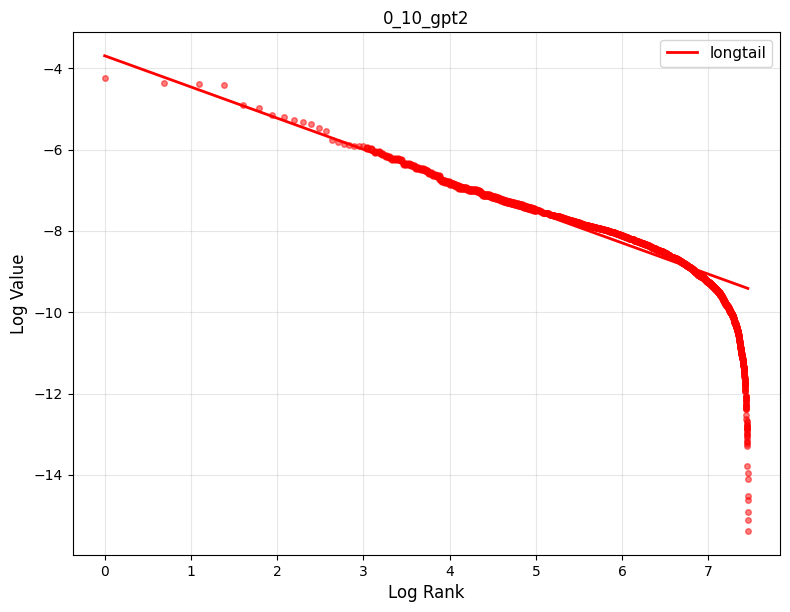

1556


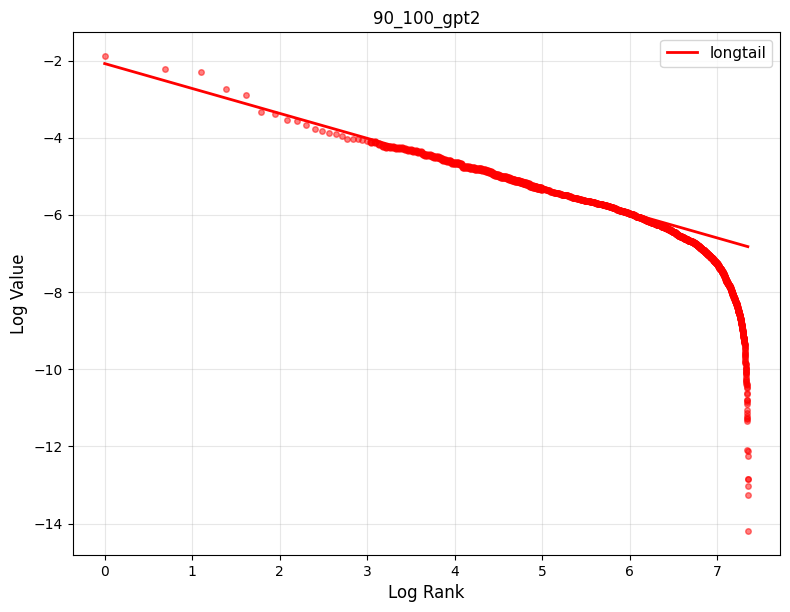

2135


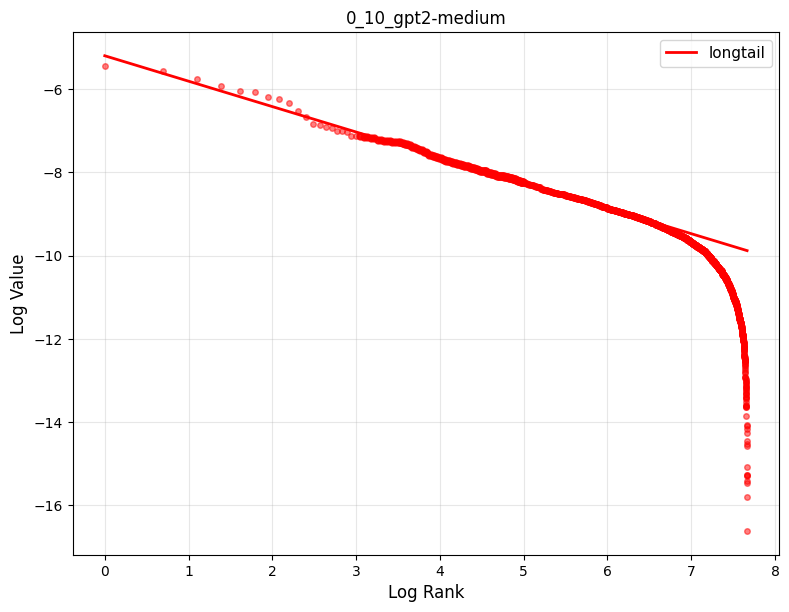

2003


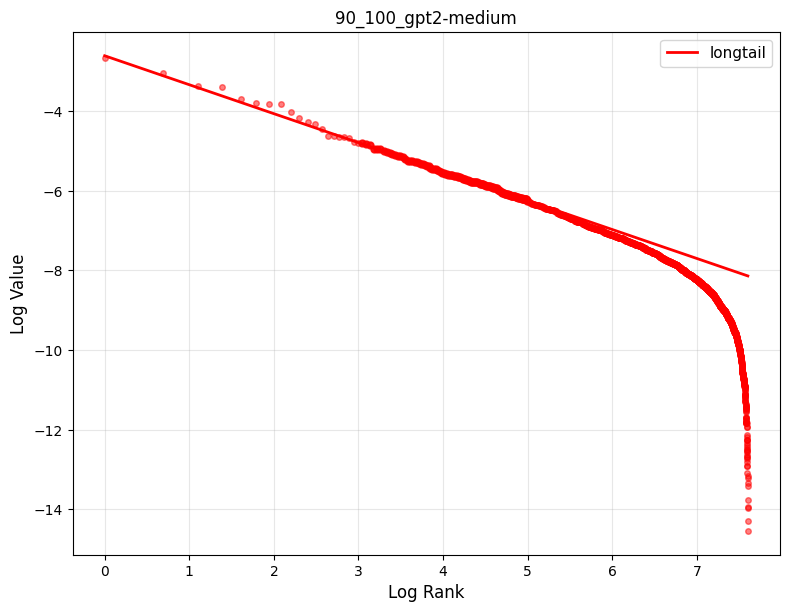

2642


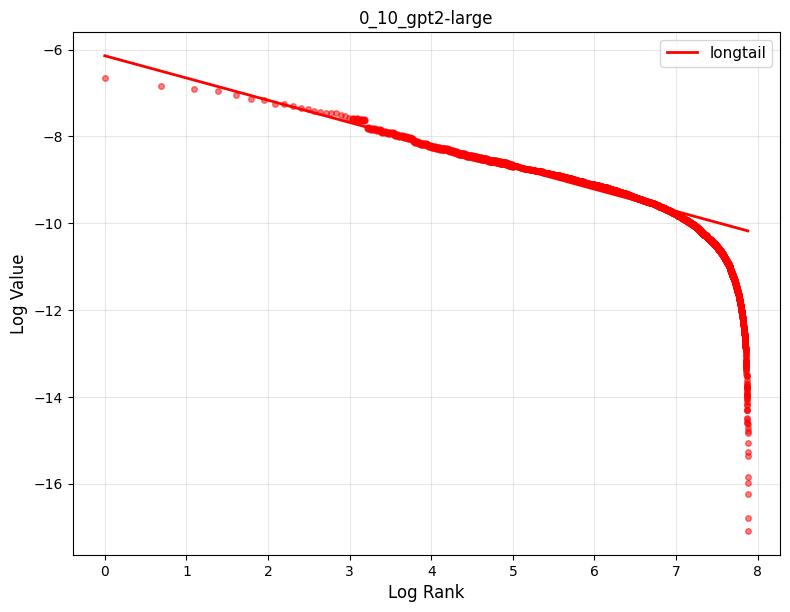

2650


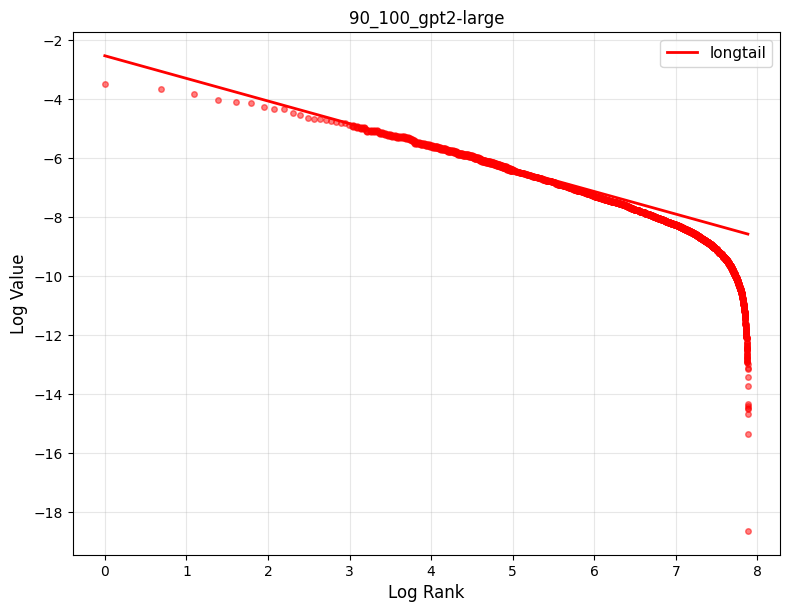

3241


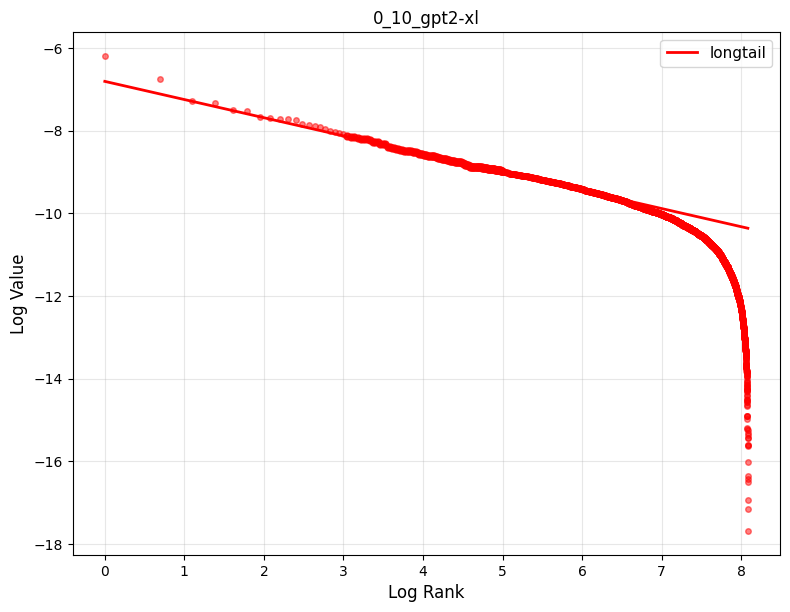

3227


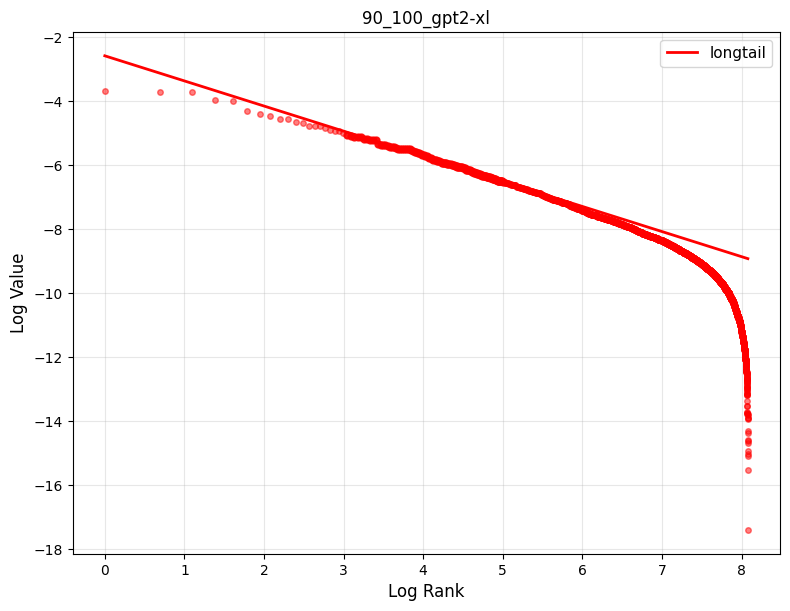

Have not got results of 10: EleutherAI/pythia-70m-deduped
Have not got results of 10: EleutherAI/pythia-160m-deduped
Have not got results of 10: EleutherAI/pythia-410m-deduped
1899


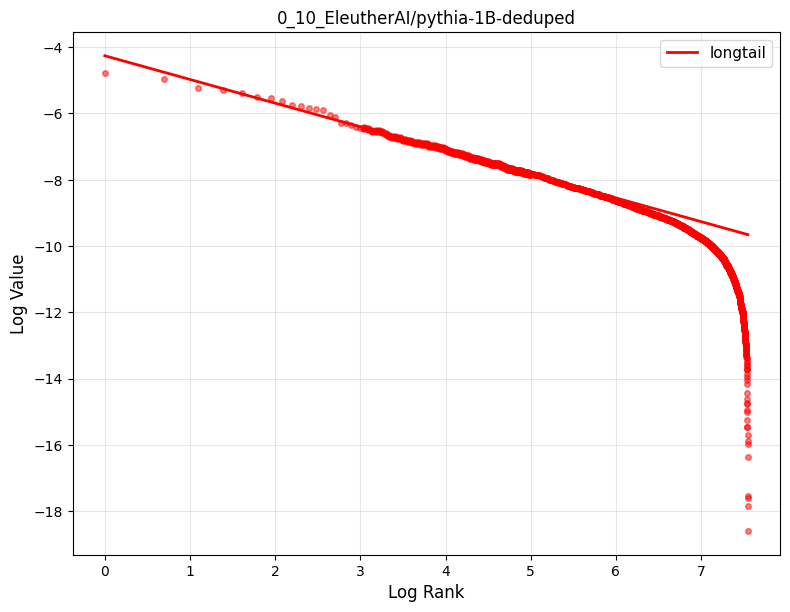

4550


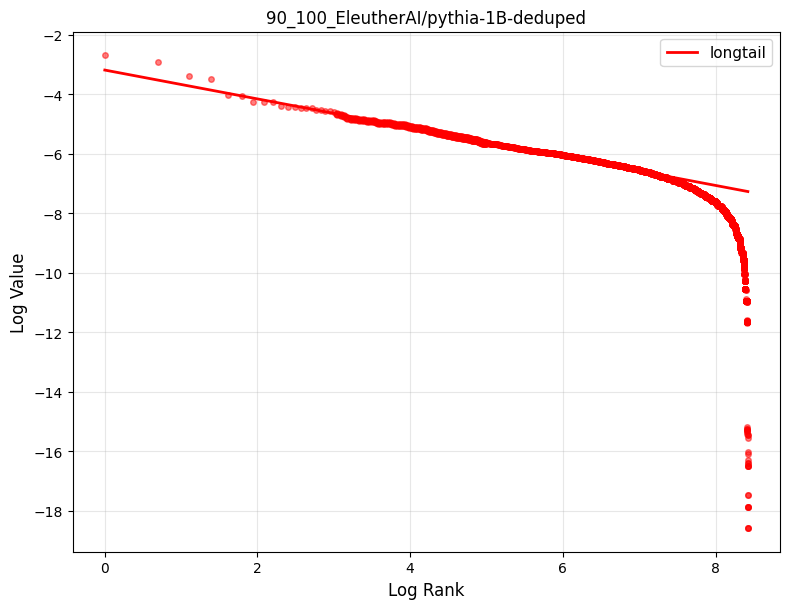

4341


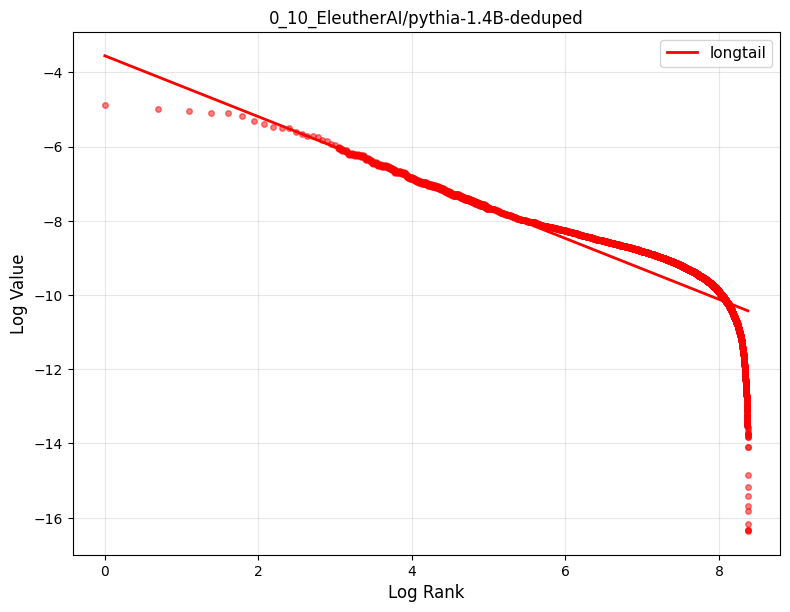

2506


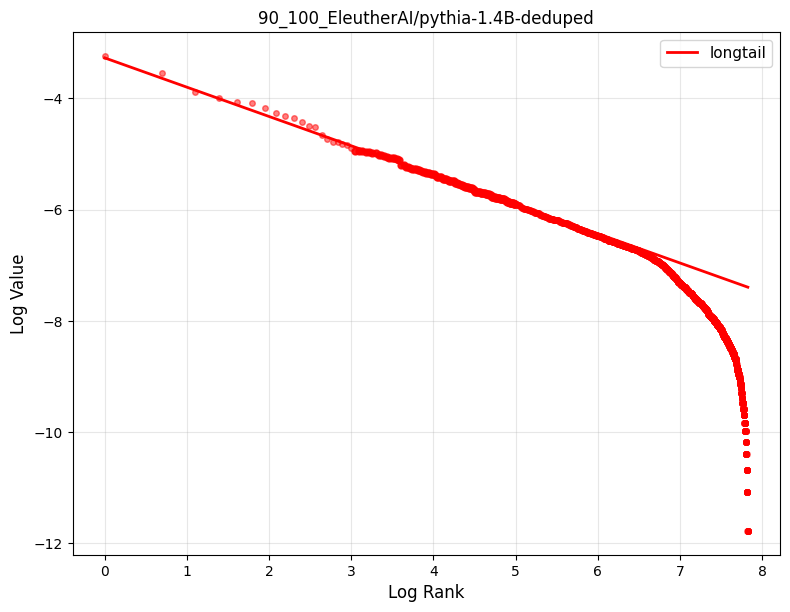

4001


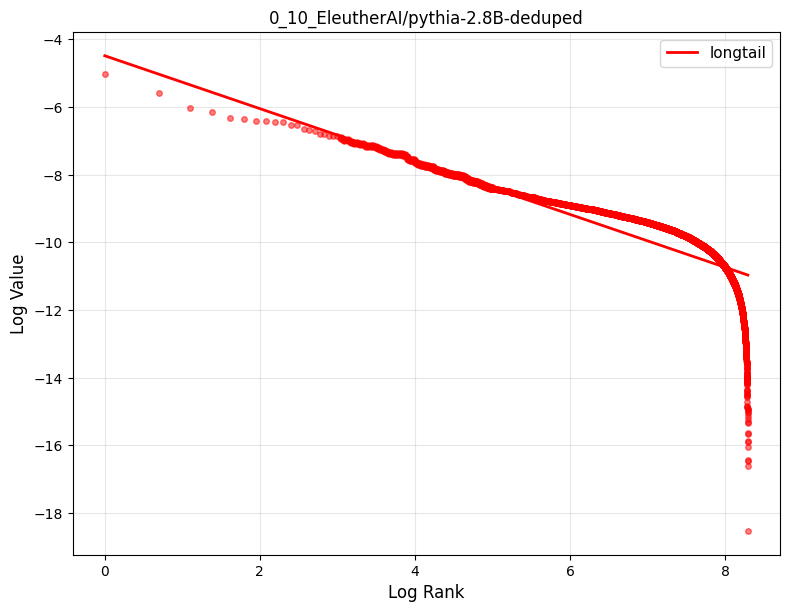

6935


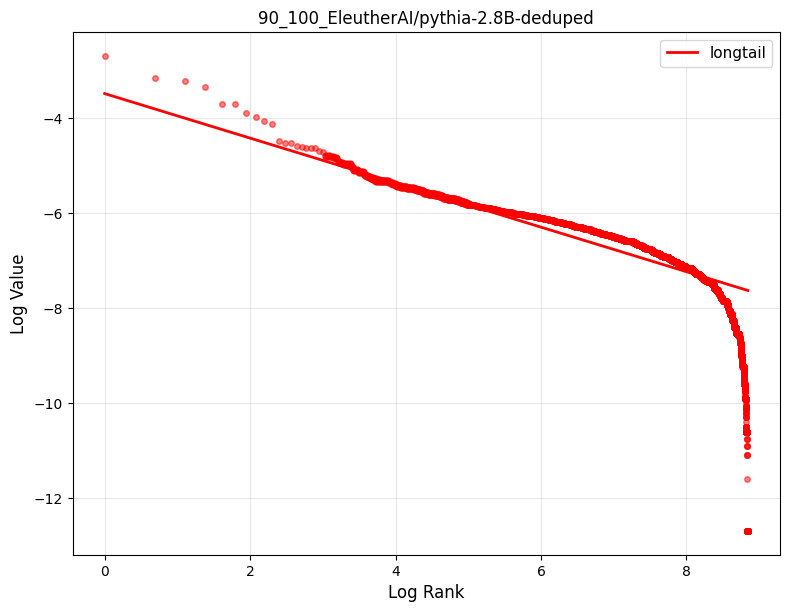

1733


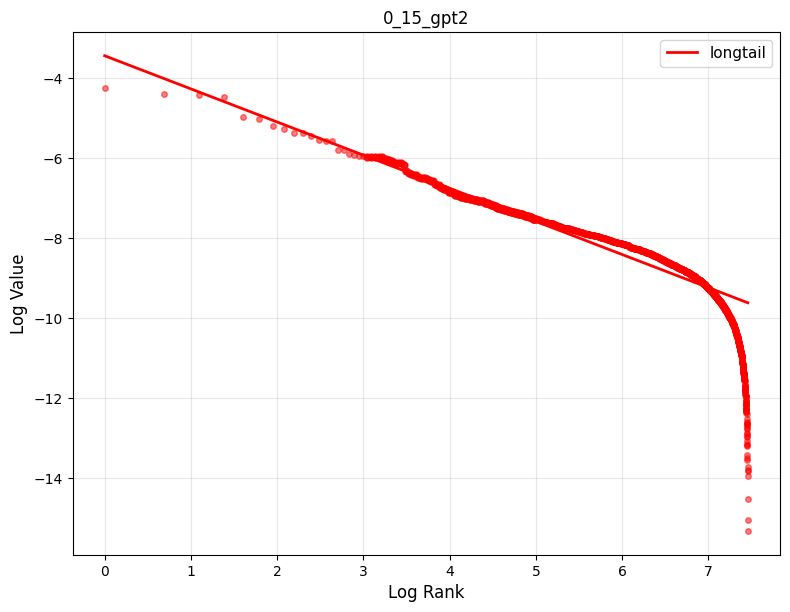

1545


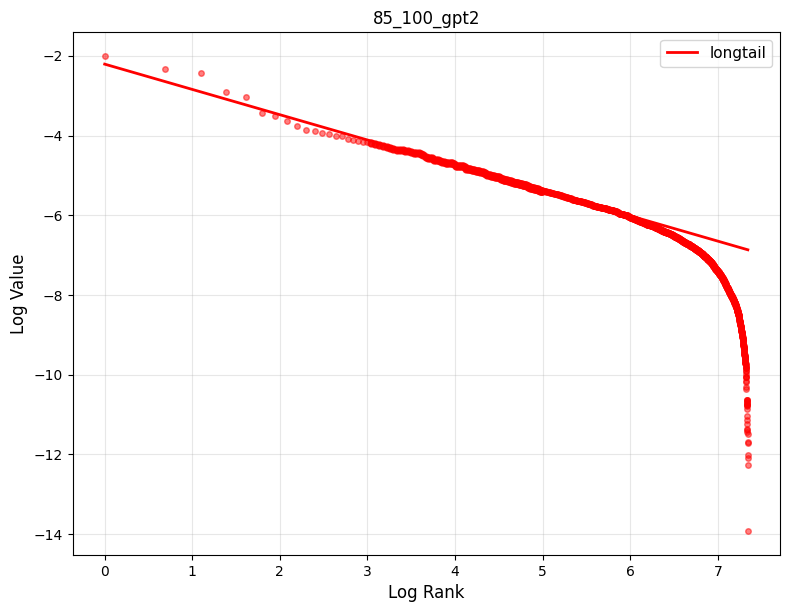

2106


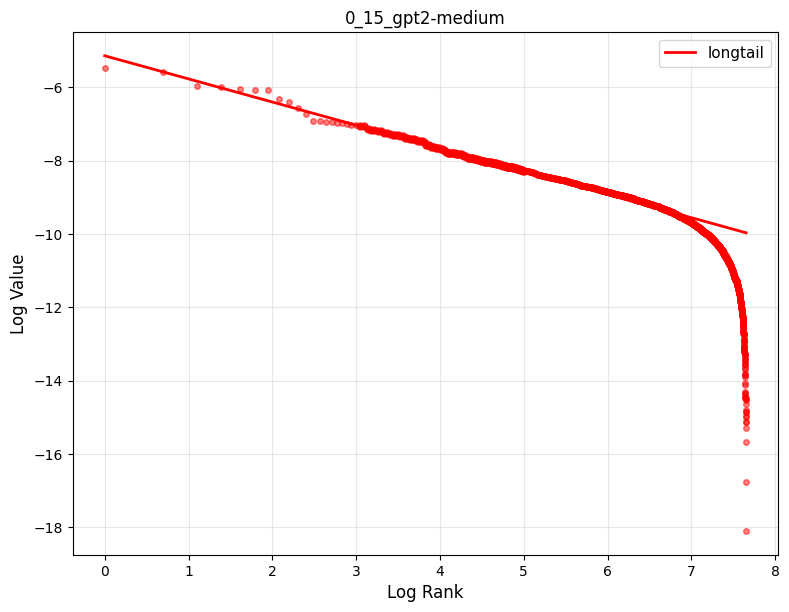

2029


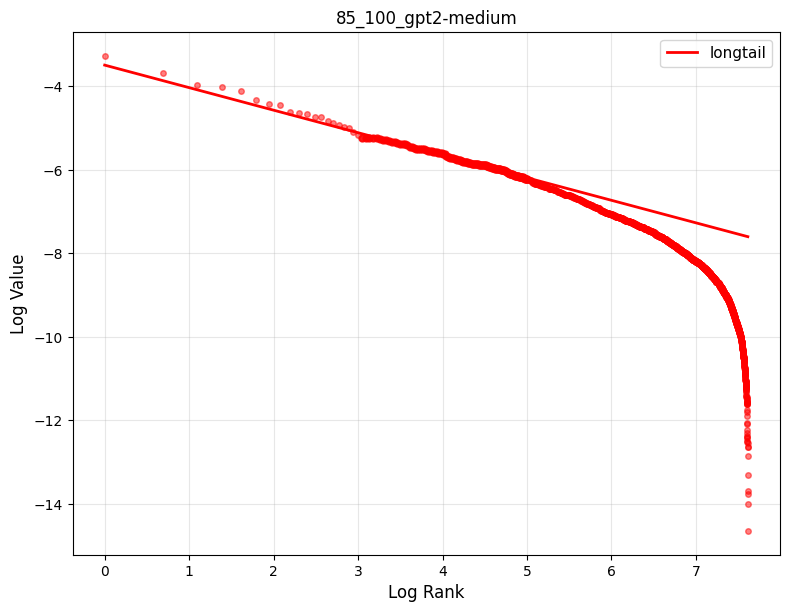

2587


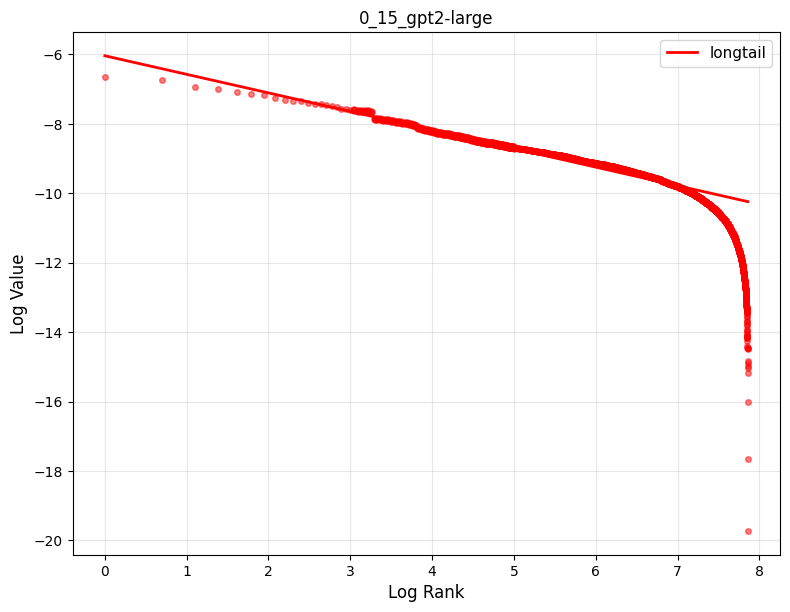

2610


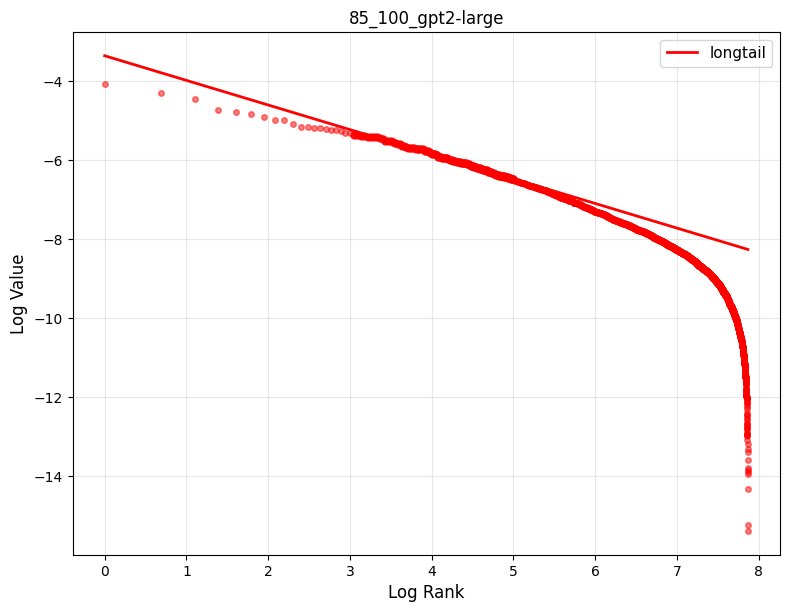

3247


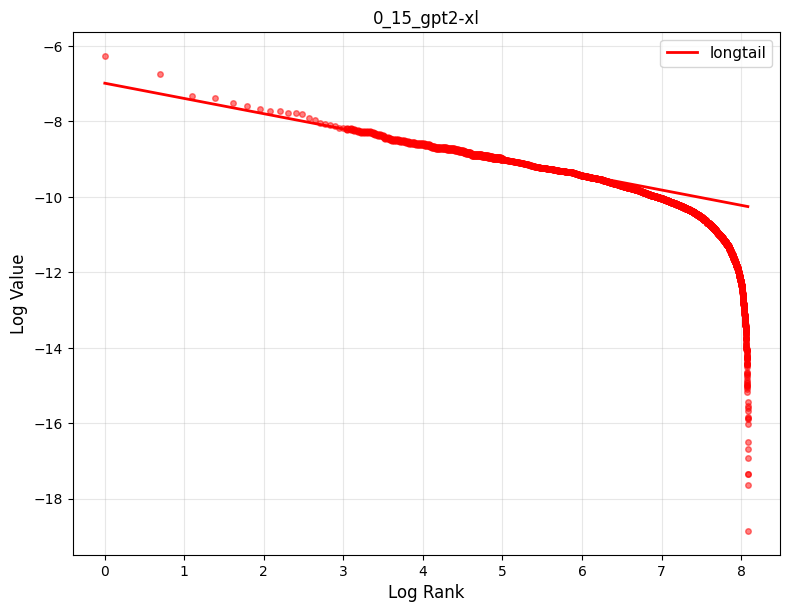

3209


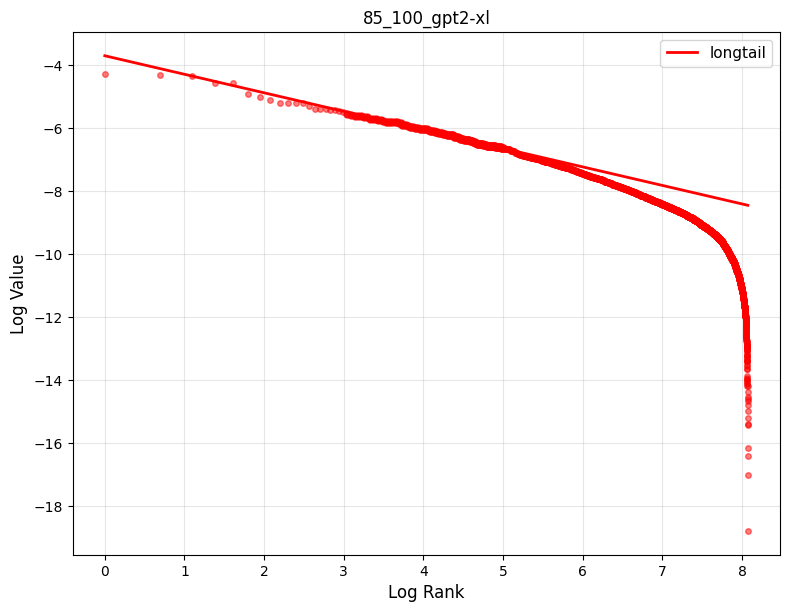

Have not got results of 15: EleutherAI/pythia-70m-deduped
Have not got results of 15: EleutherAI/pythia-160m-deduped
Have not got results of 15: EleutherAI/pythia-410m-deduped
1751


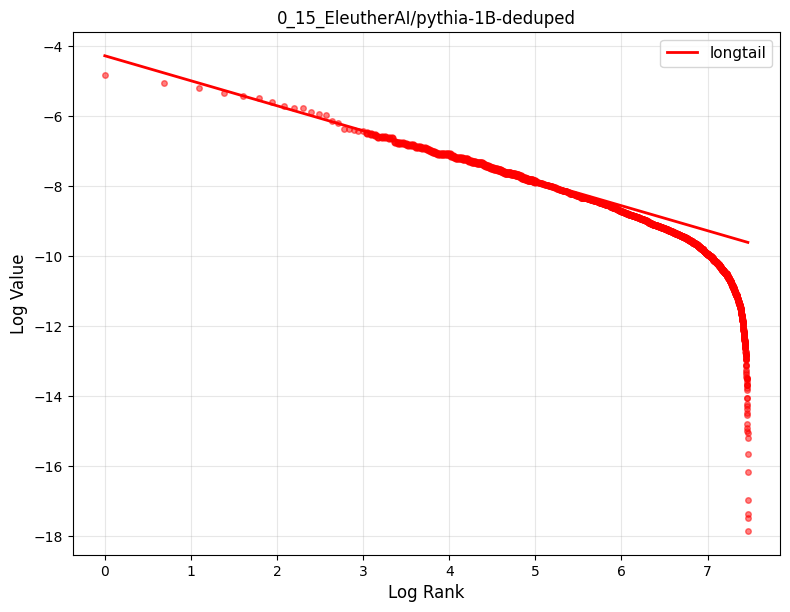

3203


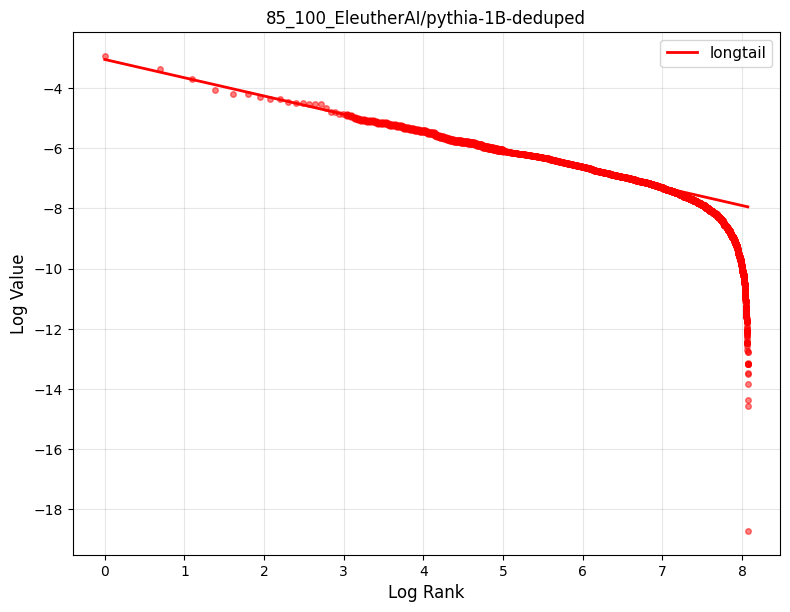

4391


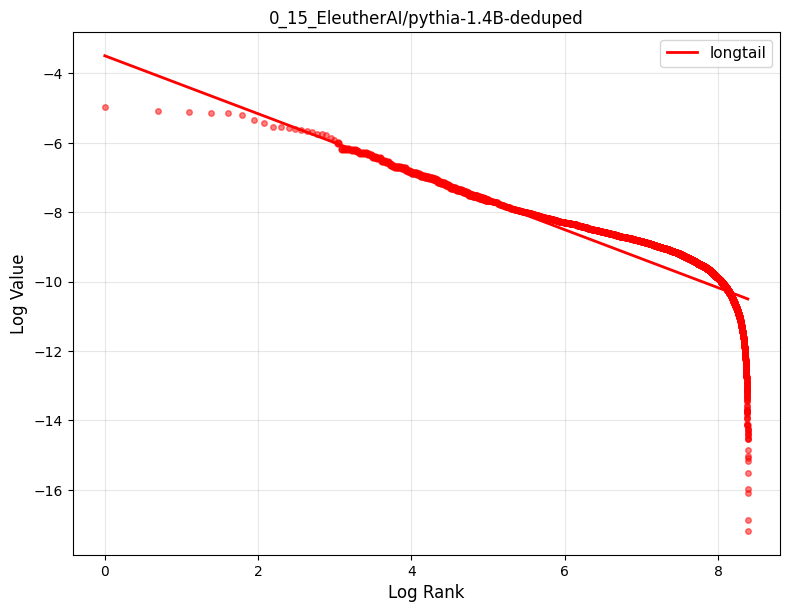

5399


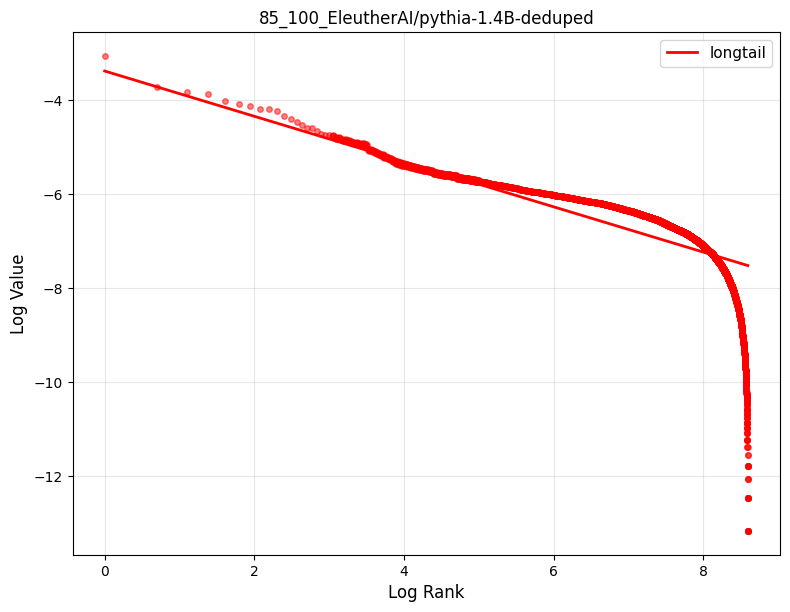

Have not got results of 15: EleutherAI/pythia-2.8B-deduped
1726


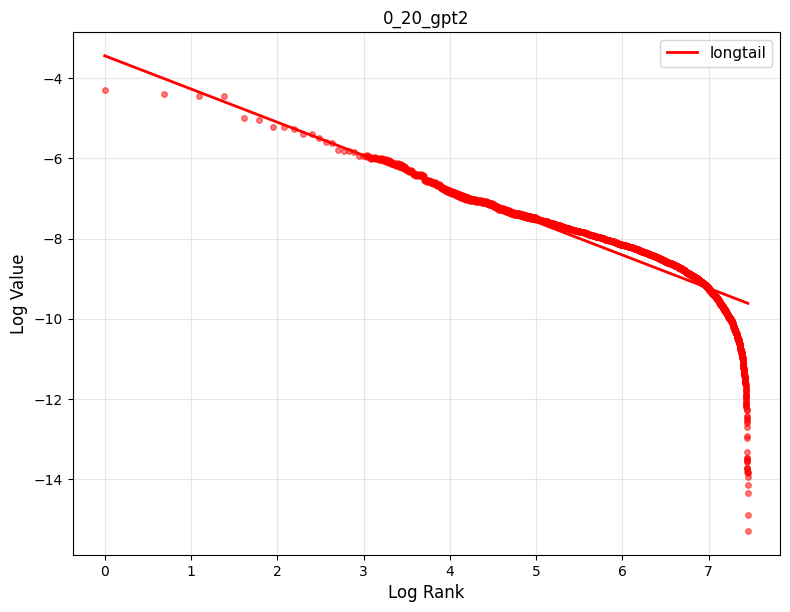

1575


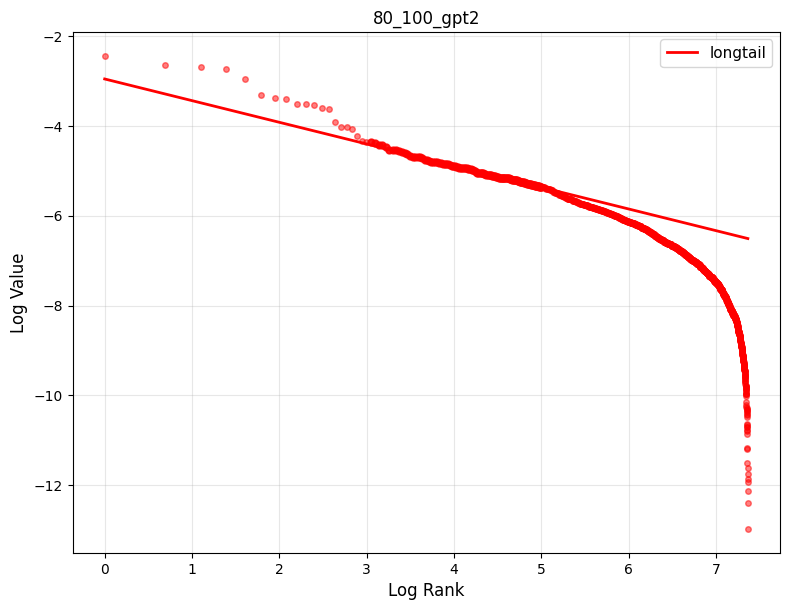

2112


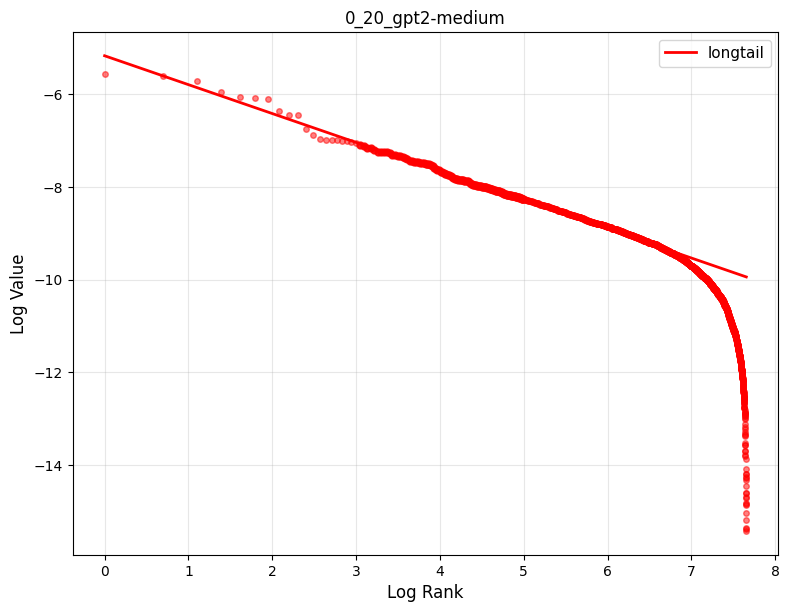

2035


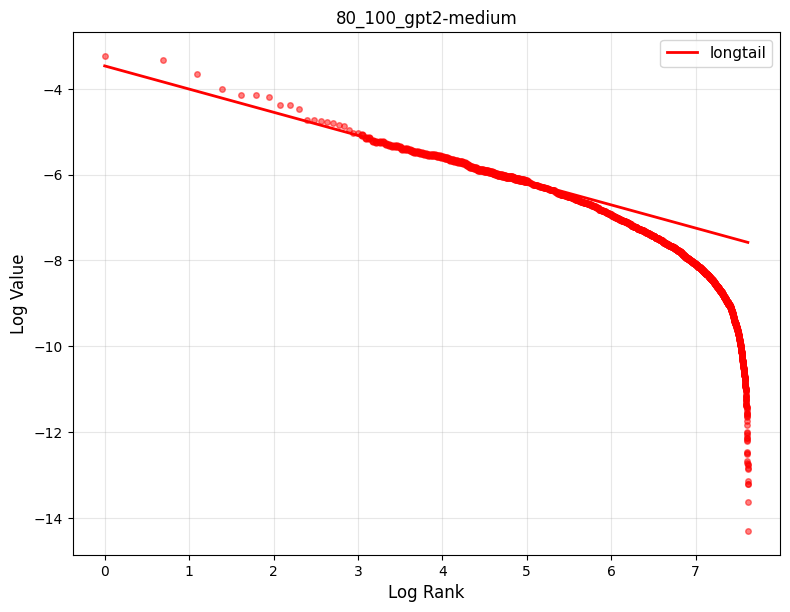

2624


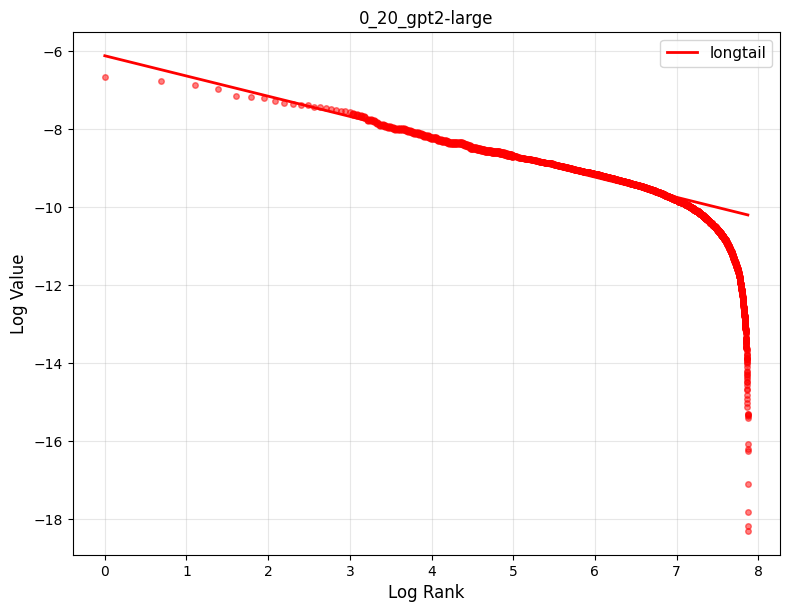

2666


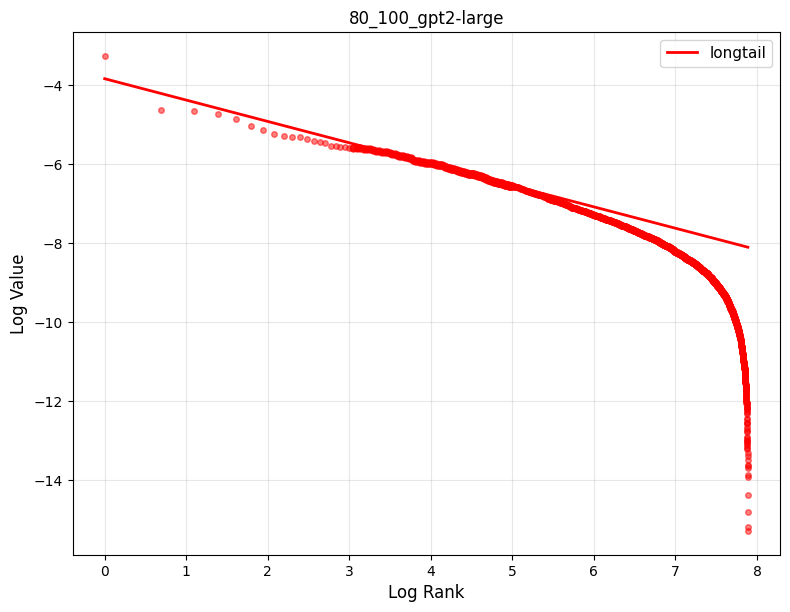

3257


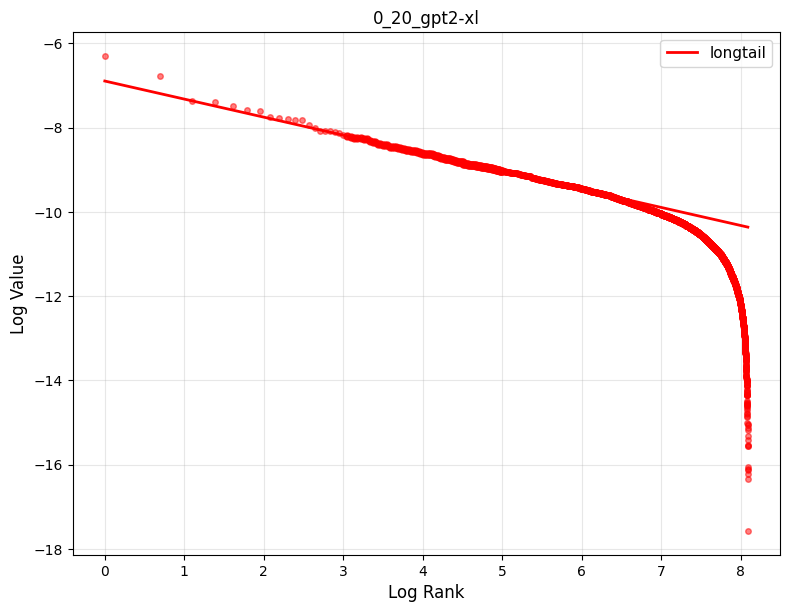

3260


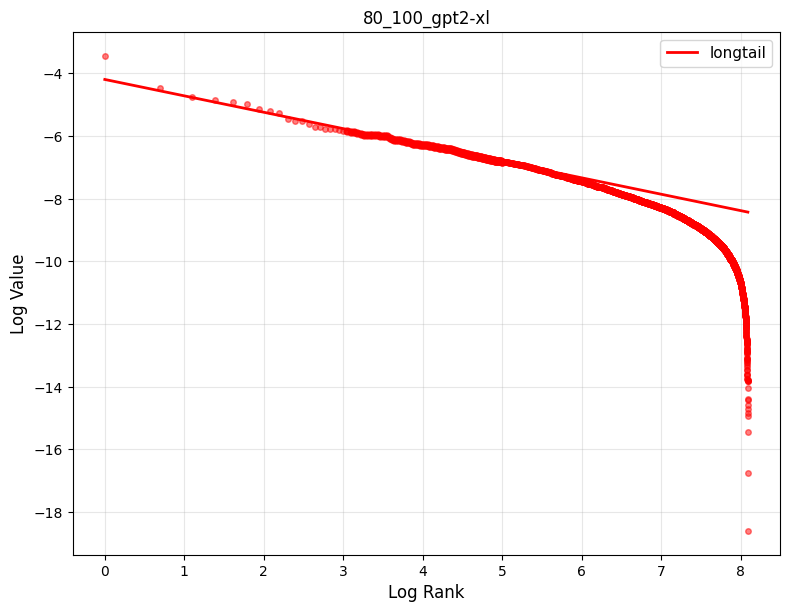

Have not got results of 20: EleutherAI/pythia-70m-deduped
Have not got results of 20: EleutherAI/pythia-160m-deduped
Have not got results of 20: EleutherAI/pythia-410m-deduped
1863


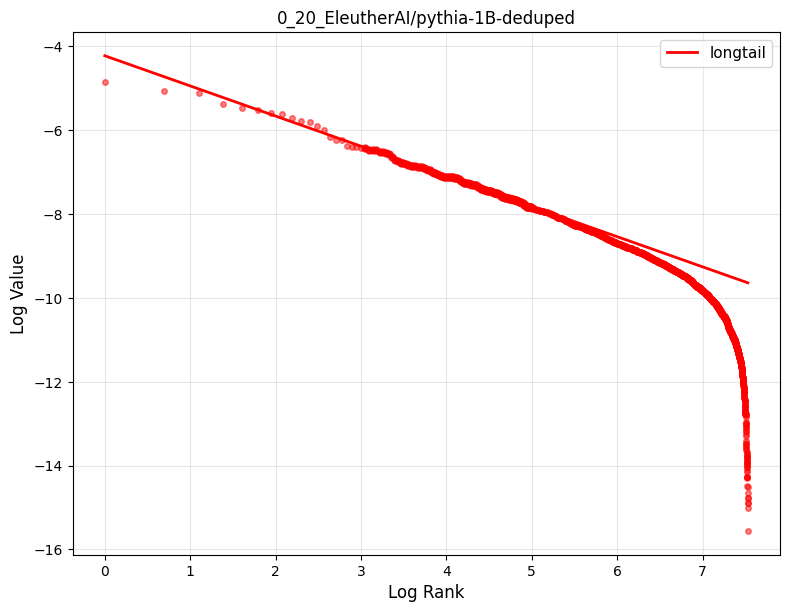

3312


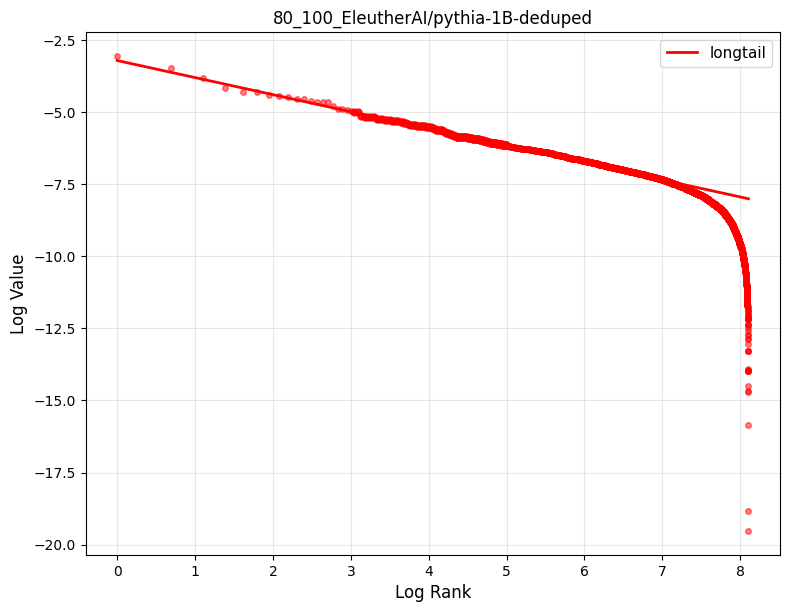

4221


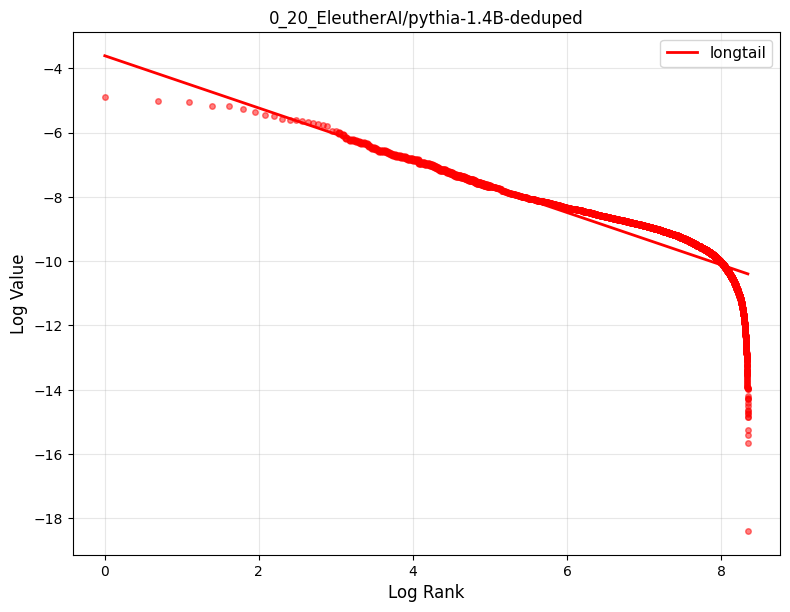

5401


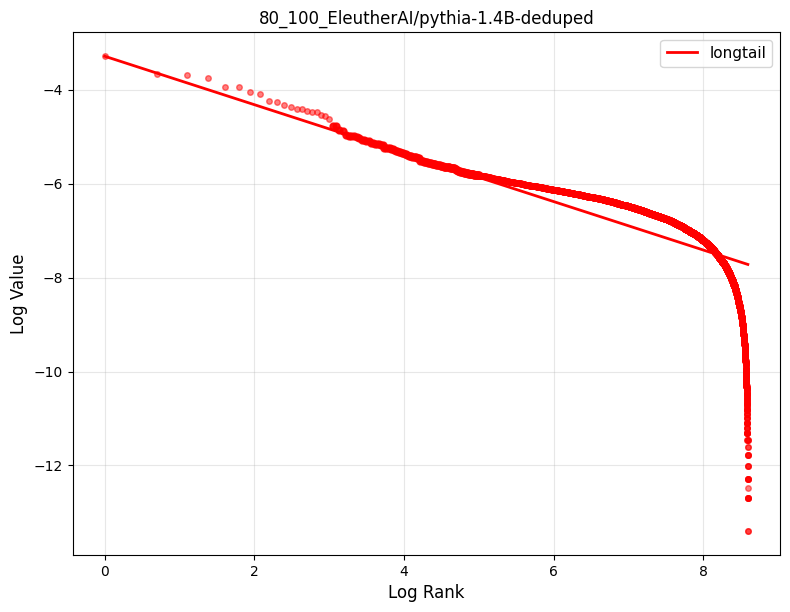

Have not got results of 20: EleutherAI/pythia-2.8B-deduped
1740


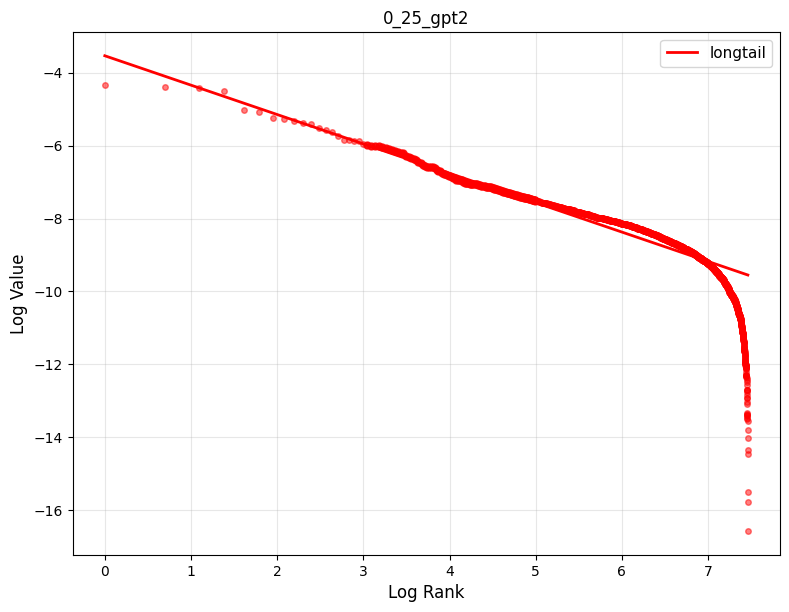

1555


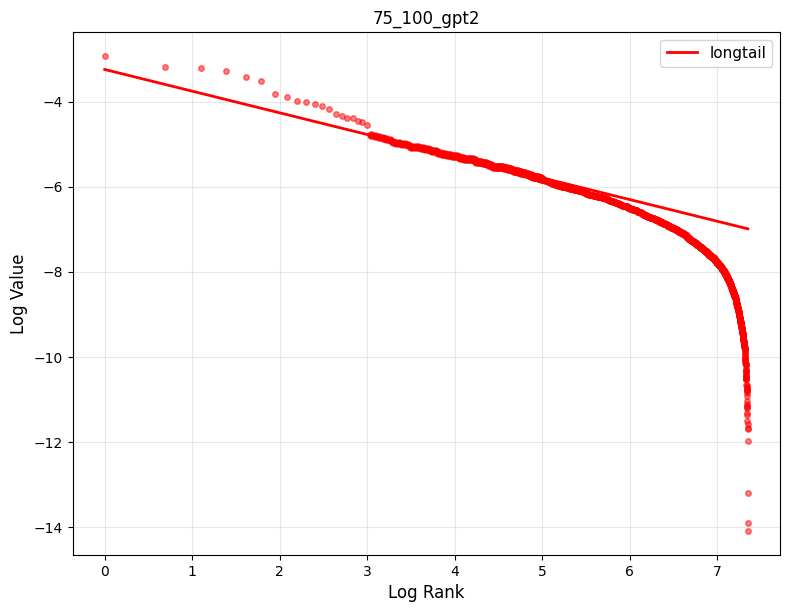

2107


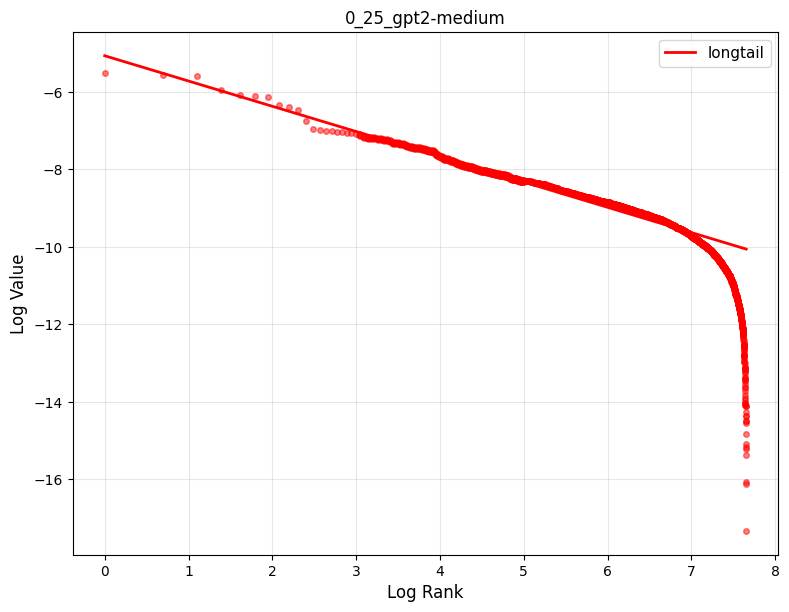

2058


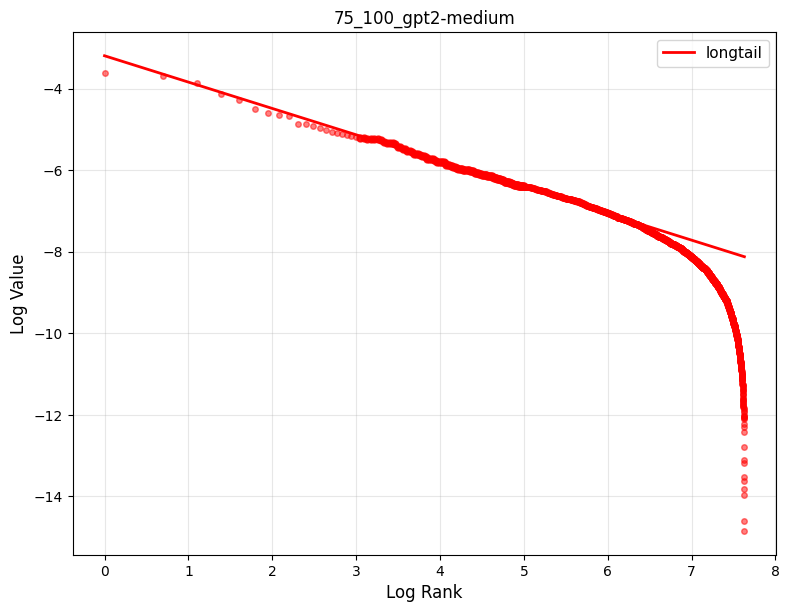

2623


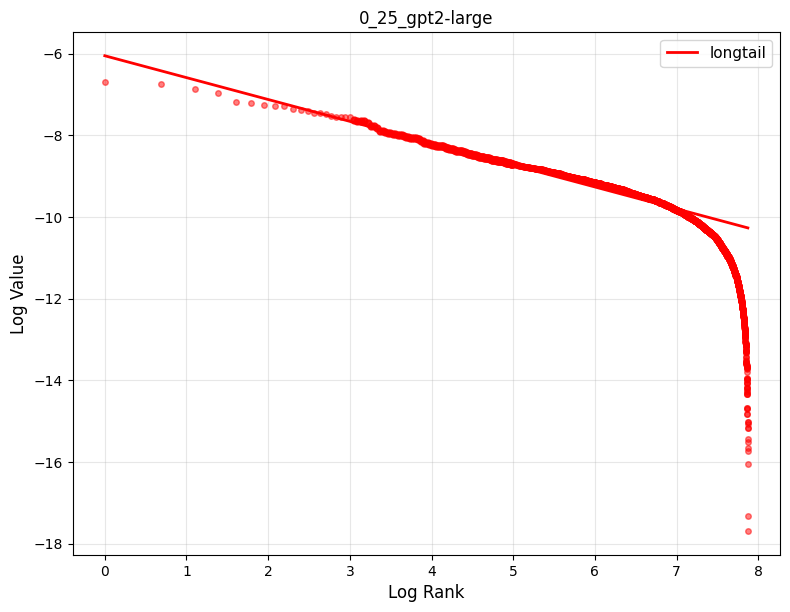

2652


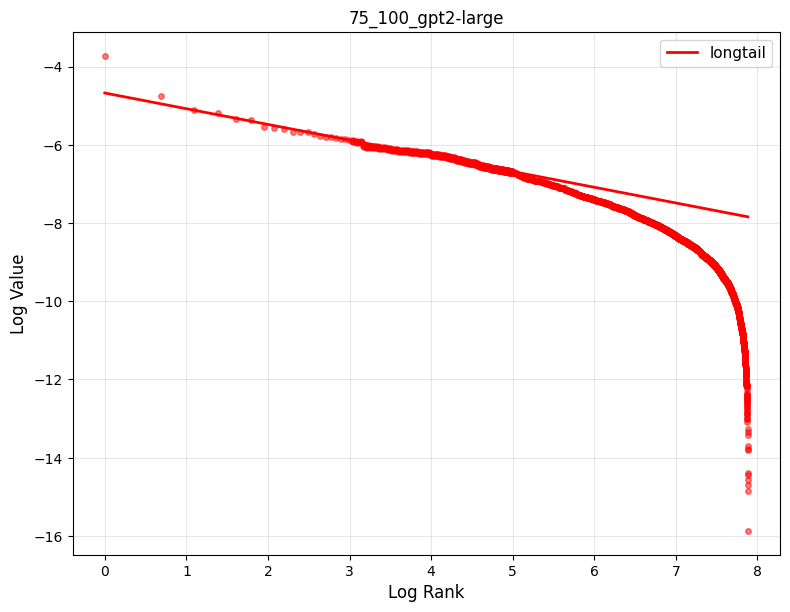

3285


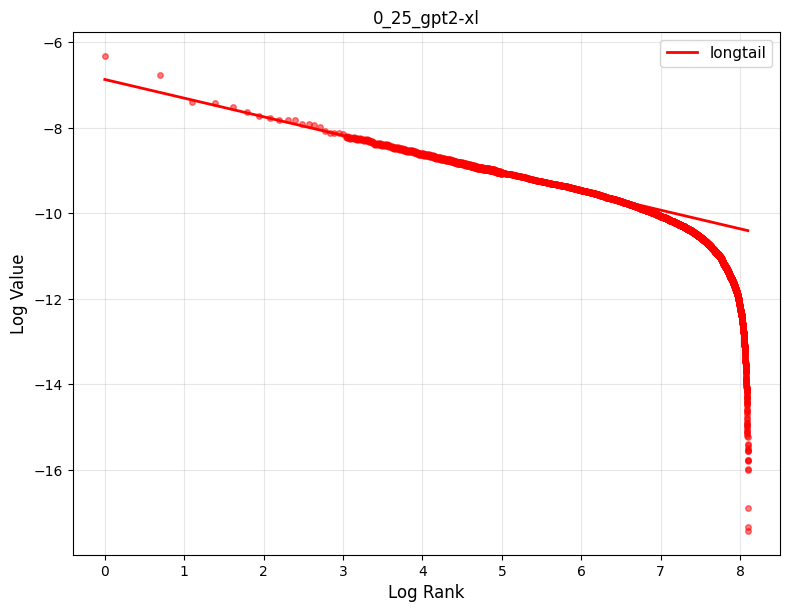

3250


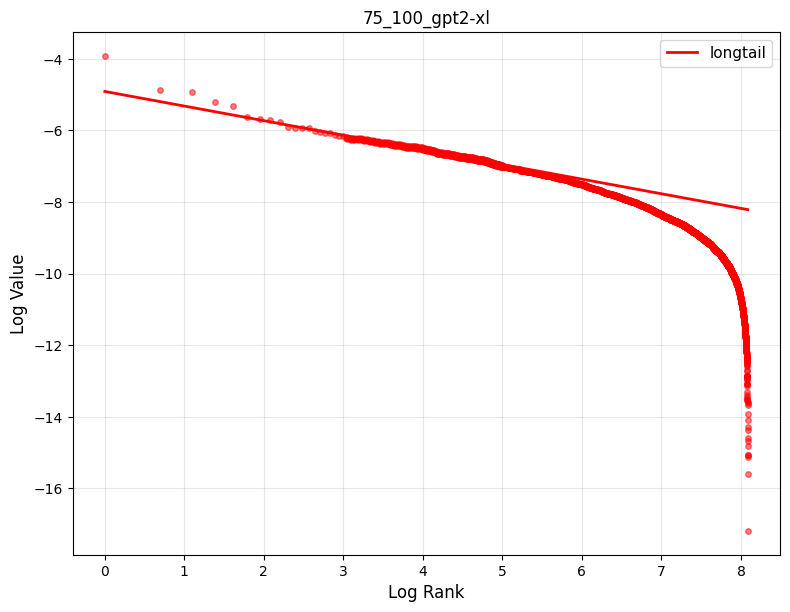

Have not got results of 25: EleutherAI/pythia-70m-deduped
Have not got results of 25: EleutherAI/pythia-160m-deduped
Have not got results of 25: EleutherAI/pythia-410m-deduped
1712


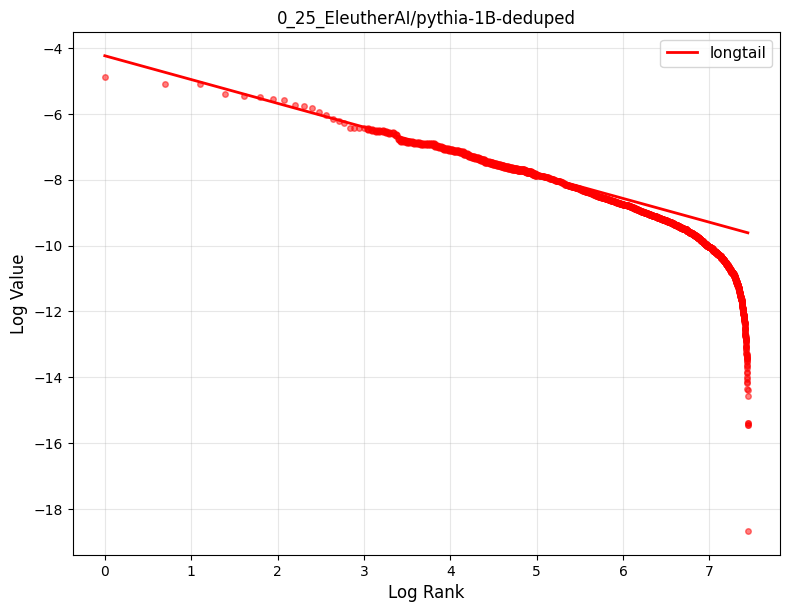

3438


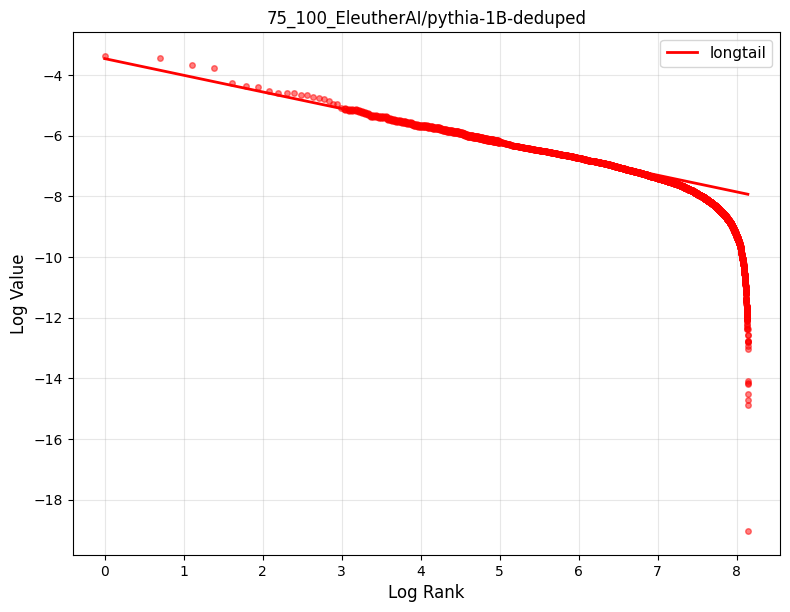

Have not got results of 25: EleutherAI/pythia-1.4B-deduped
Have not got results of 25: EleutherAI/pythia-2.8B-deduped
1736


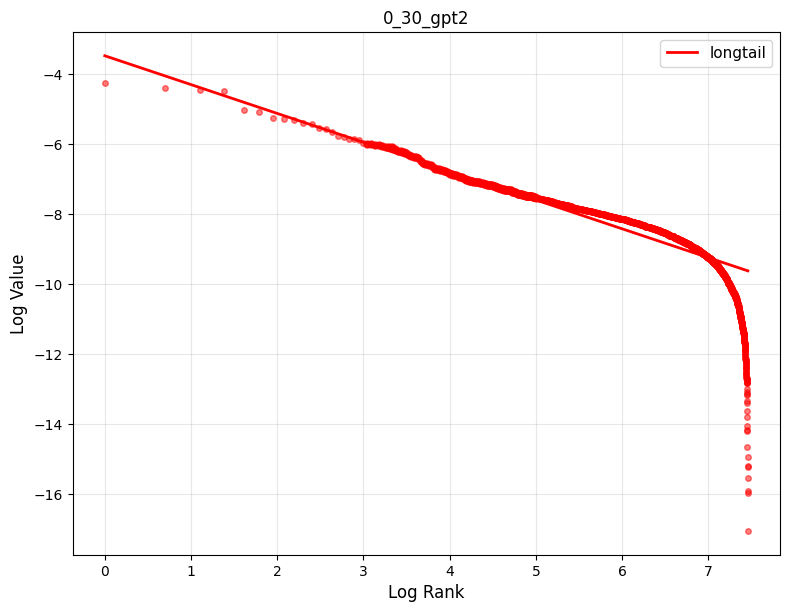

1578


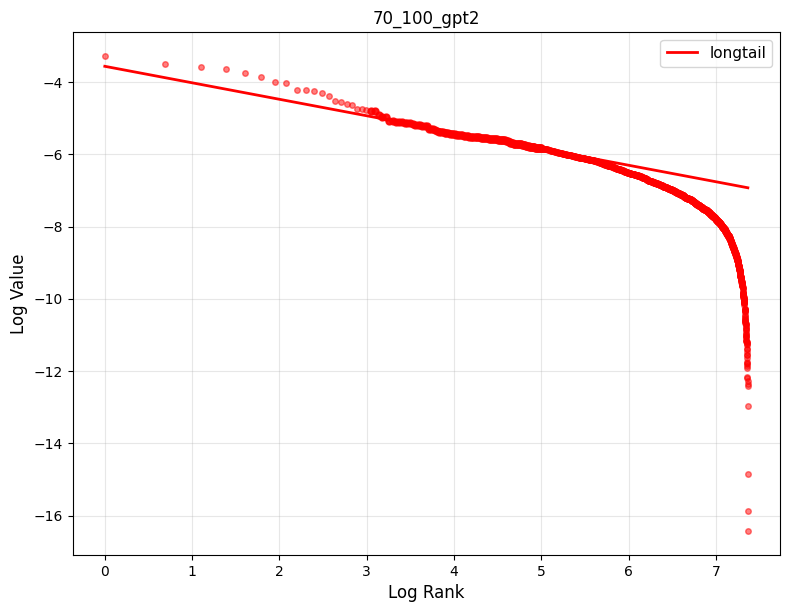

2115


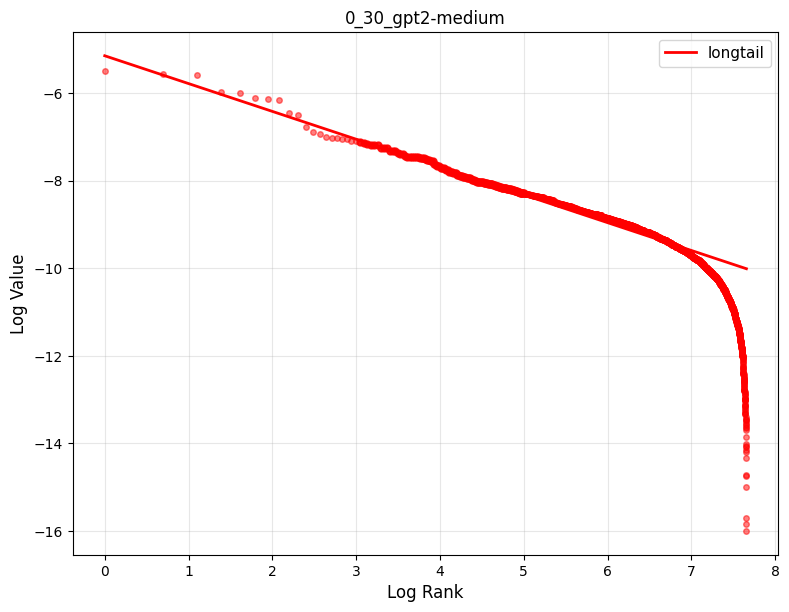

2088


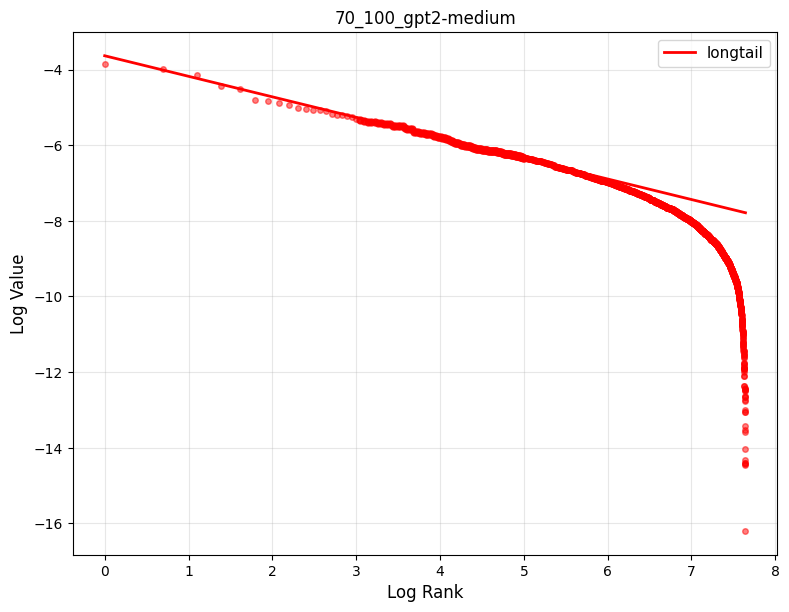

2640


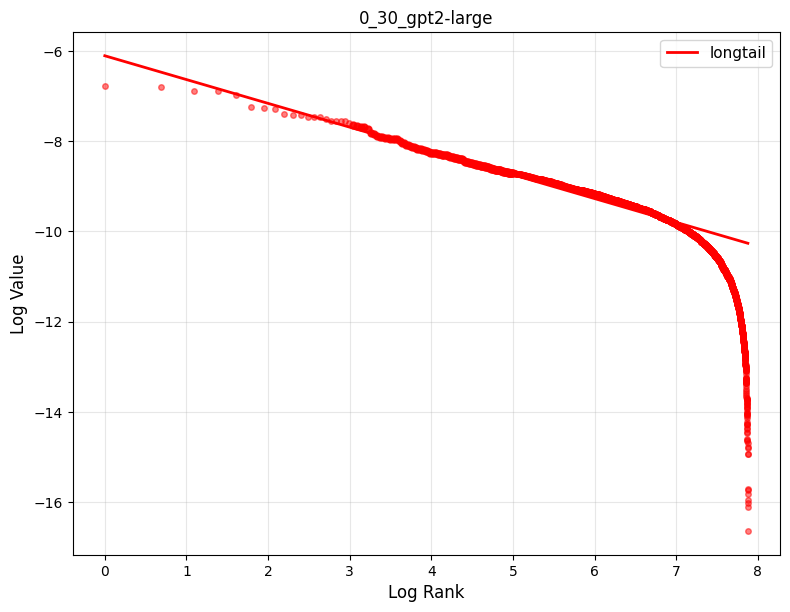

2612


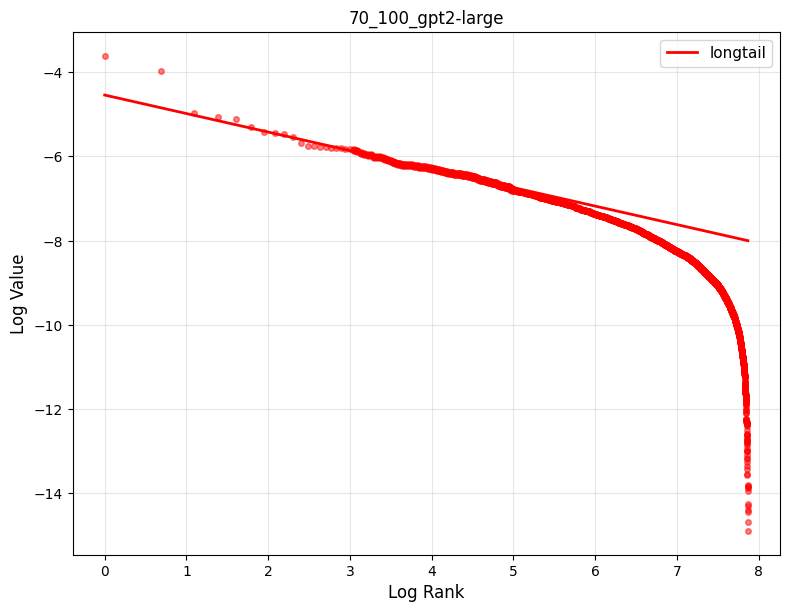

3295


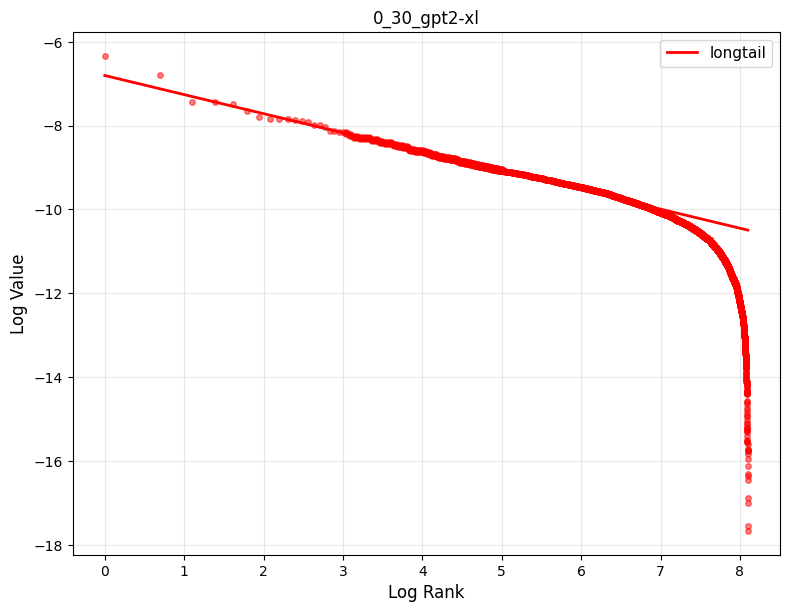

3265


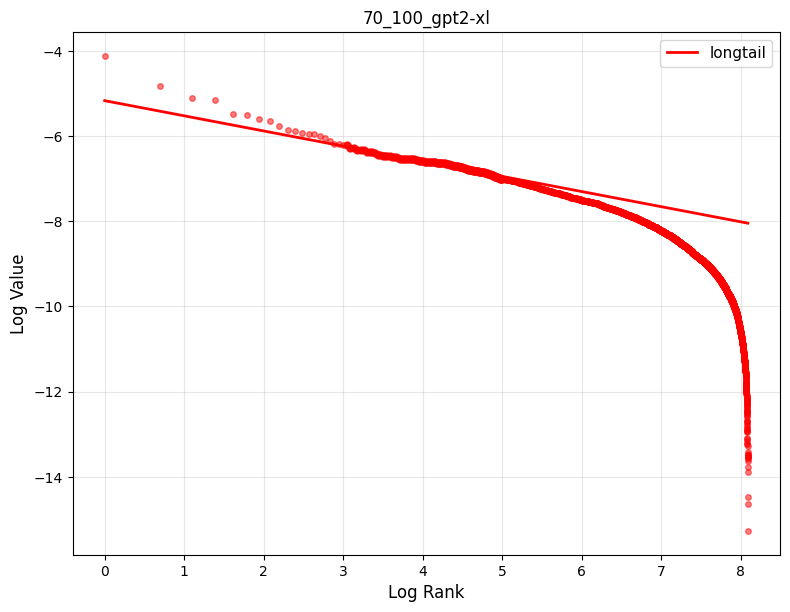

Have not got results of 30: EleutherAI/pythia-70m-deduped
Have not got results of 30: EleutherAI/pythia-160m-deduped
Have not got results of 30: EleutherAI/pythia-410m-deduped
1680


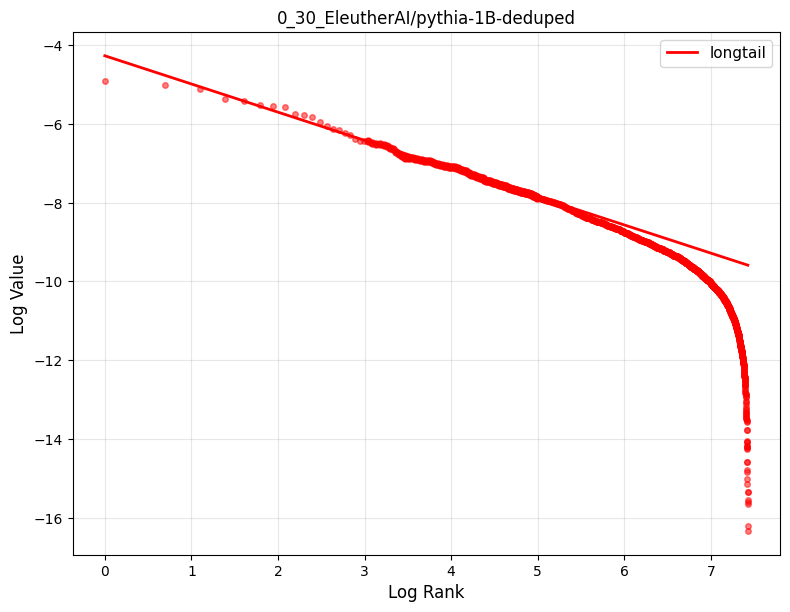

4384


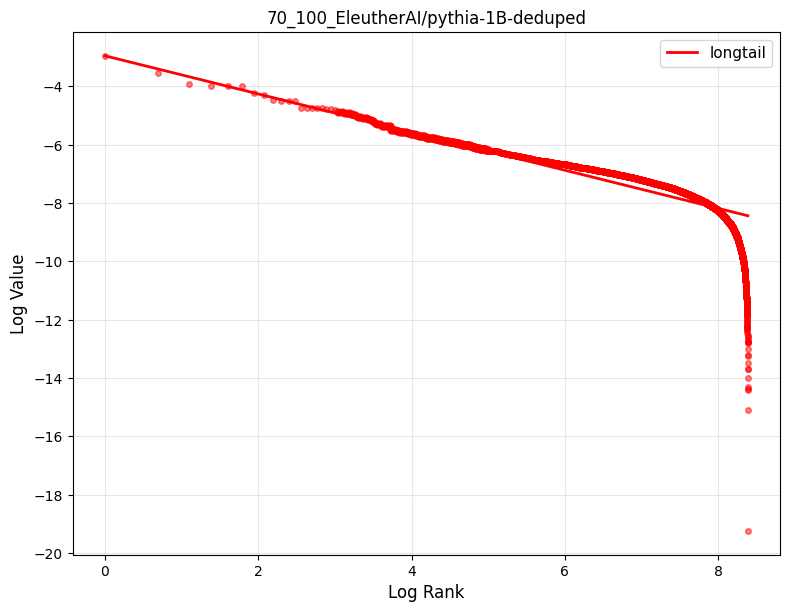

Have not got results of 30: EleutherAI/pythia-1.4B-deduped
3691


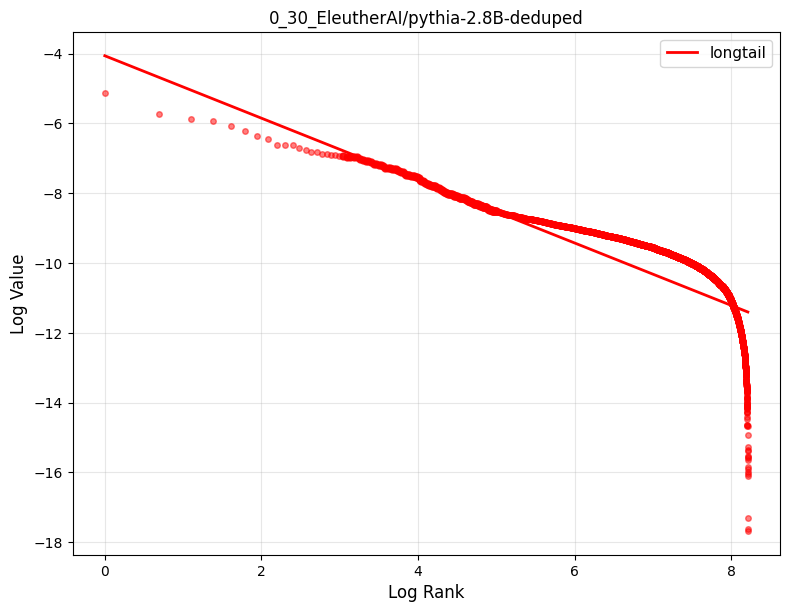

4903


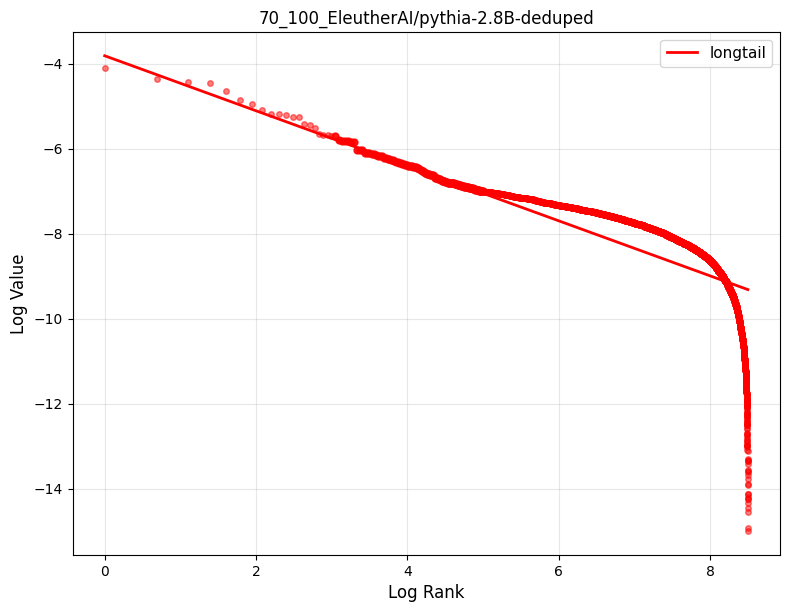

1730


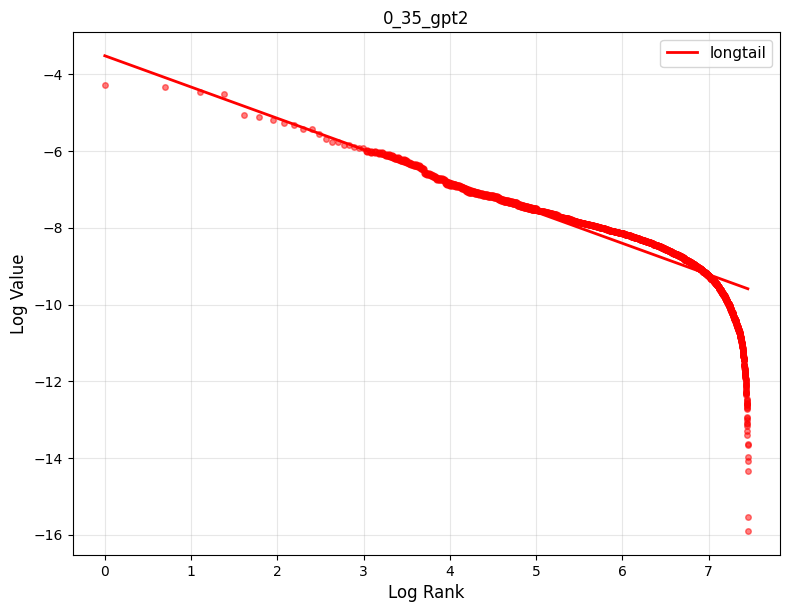

1550


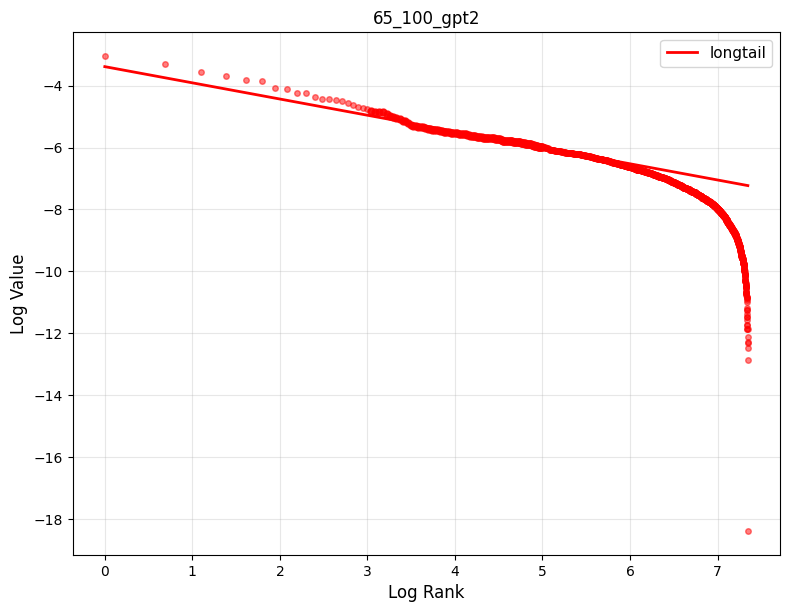

2129


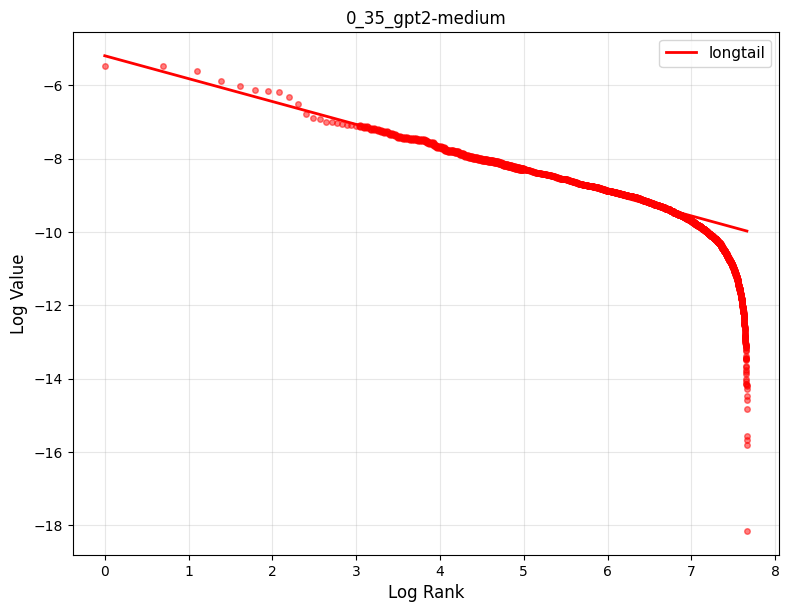

2103


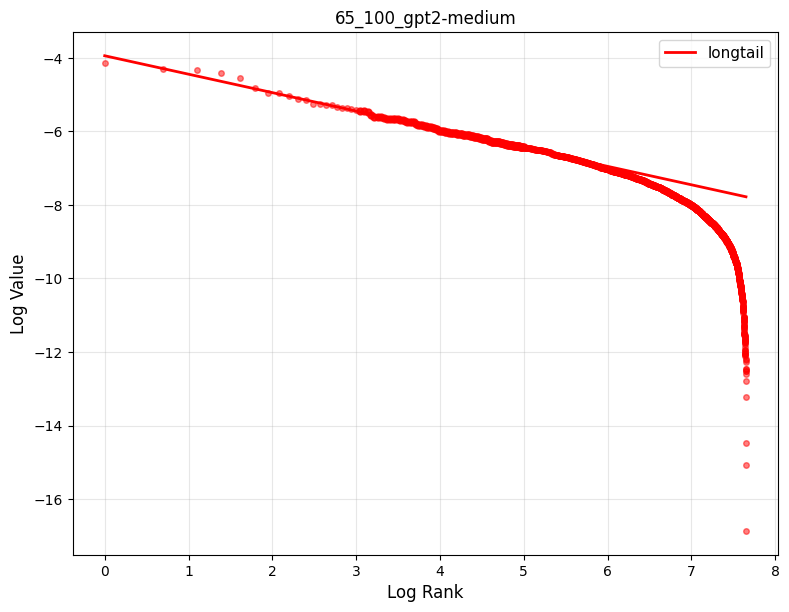

2635


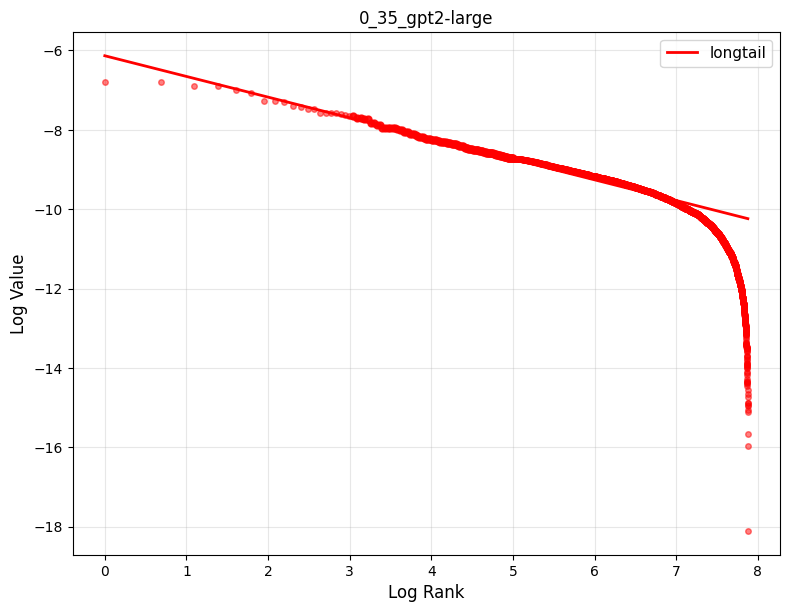

2586


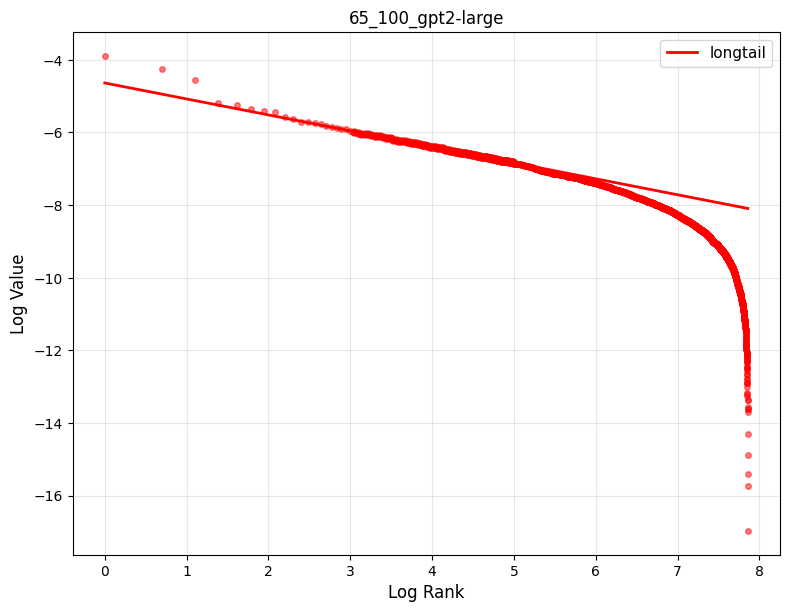

3304


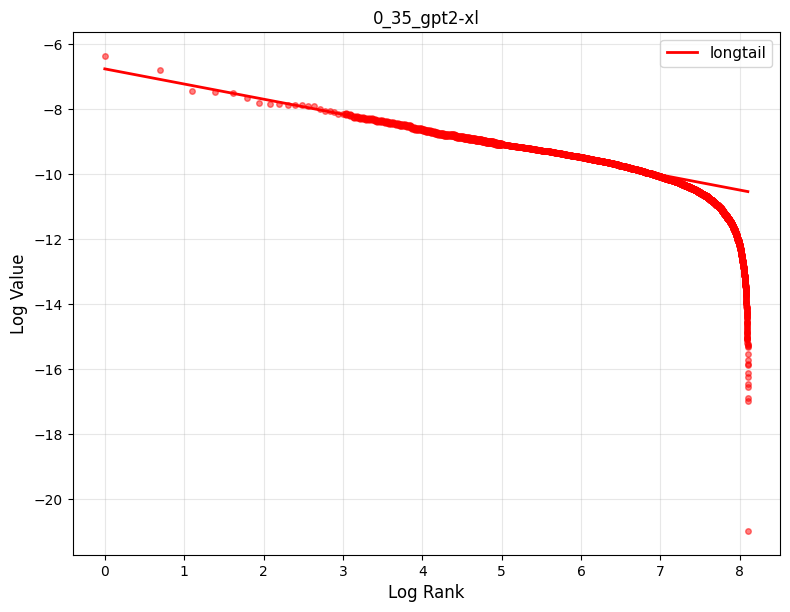

3210


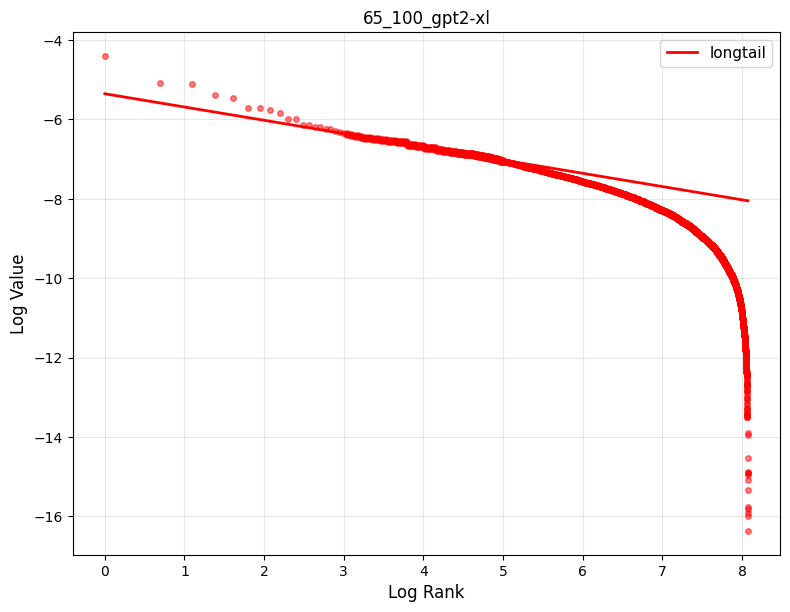

Have not got results of 35: EleutherAI/pythia-70m-deduped
Have not got results of 35: EleutherAI/pythia-160m-deduped
Have not got results of 35: EleutherAI/pythia-410m-deduped
1853


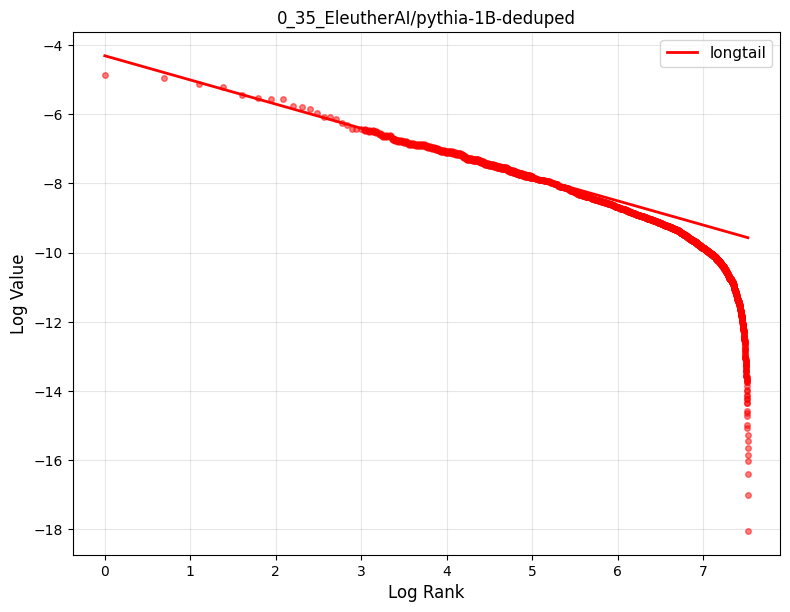

4303


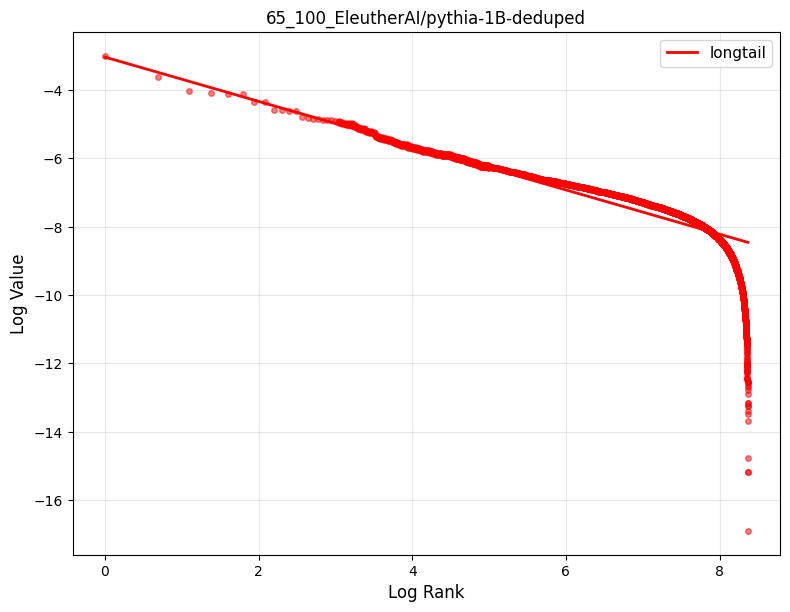

Have not got results of 35: EleutherAI/pythia-1.4B-deduped
Have not got results of 35: EleutherAI/pythia-2.8B-deduped
1730


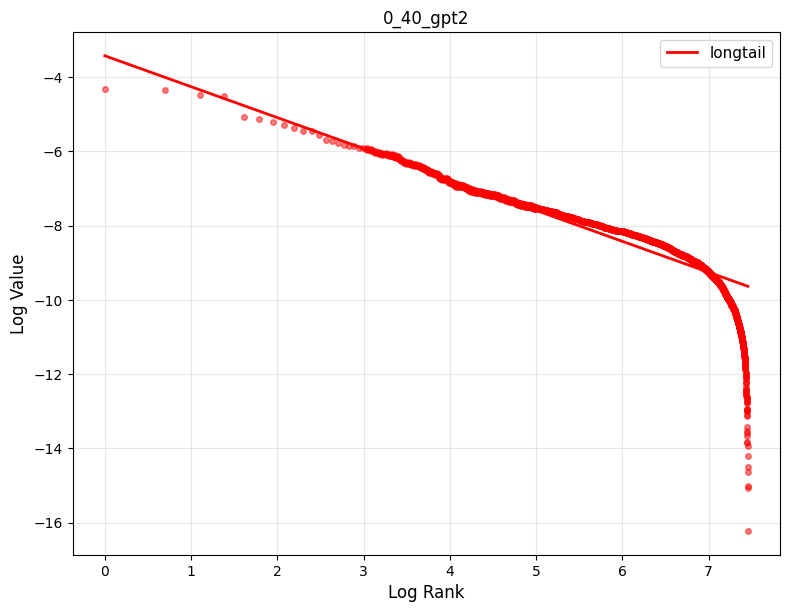

1505


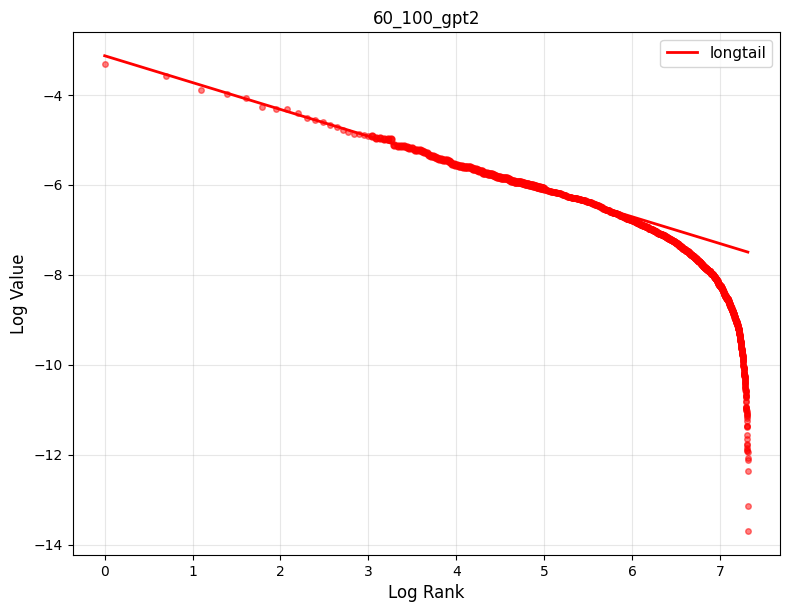

2128


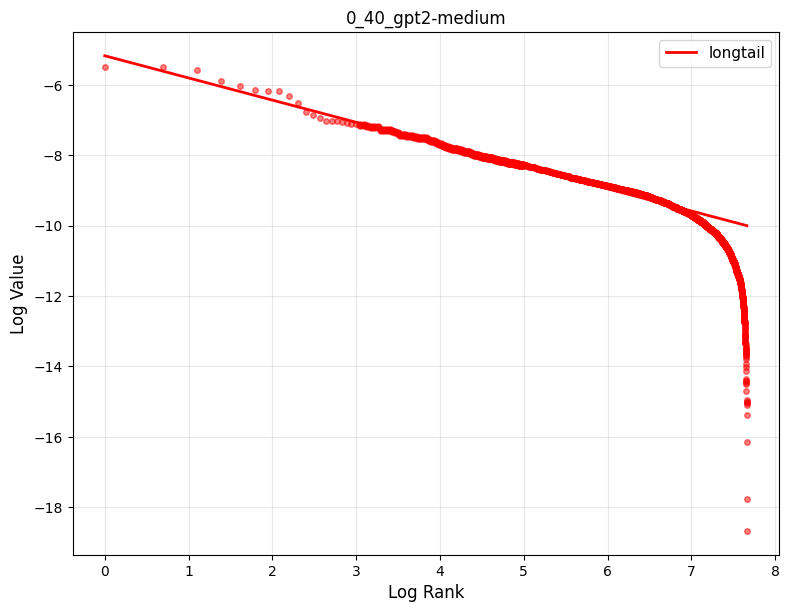

2107


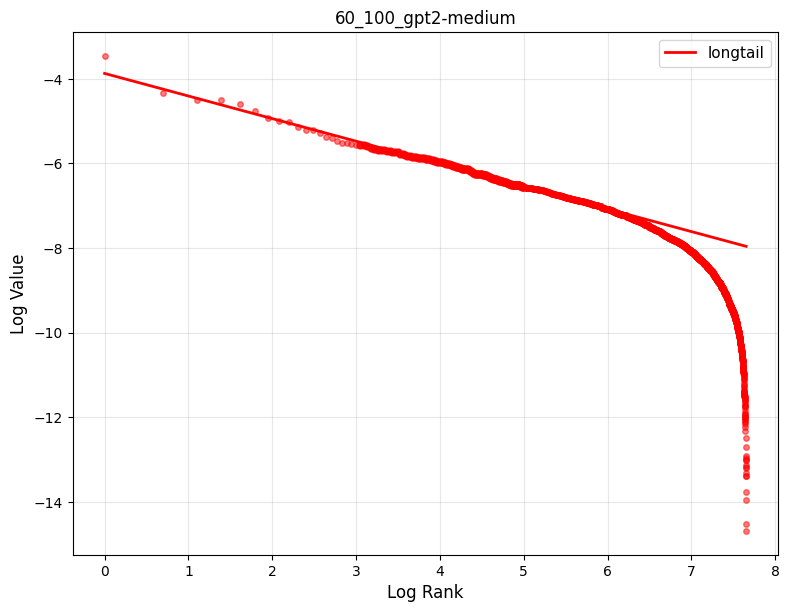

2637


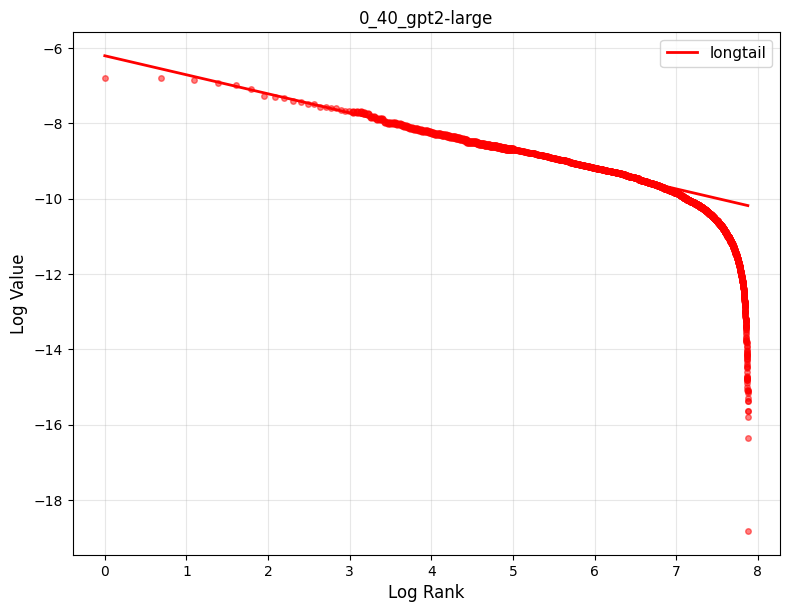

2557


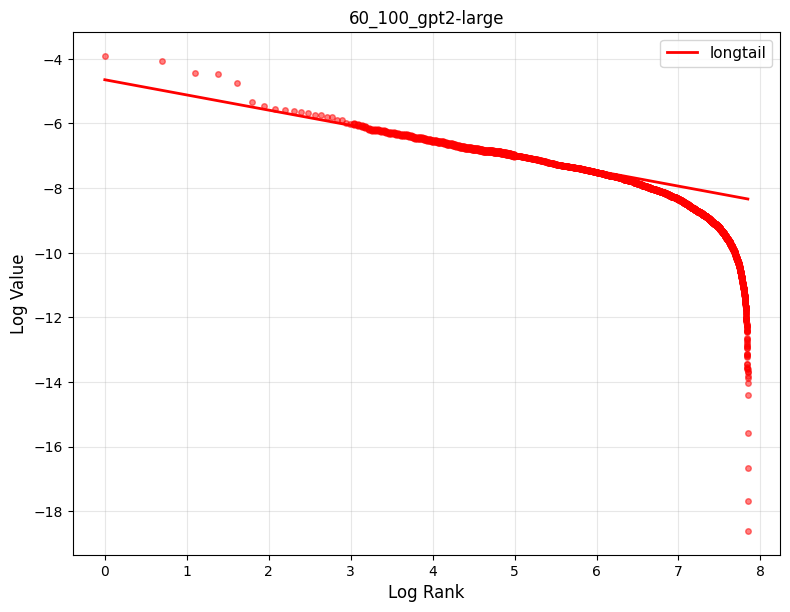

3292


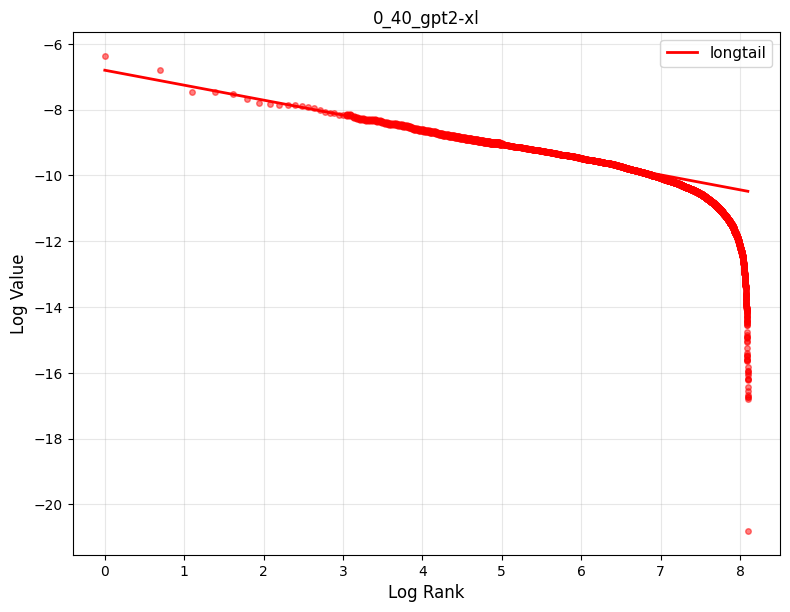

3159


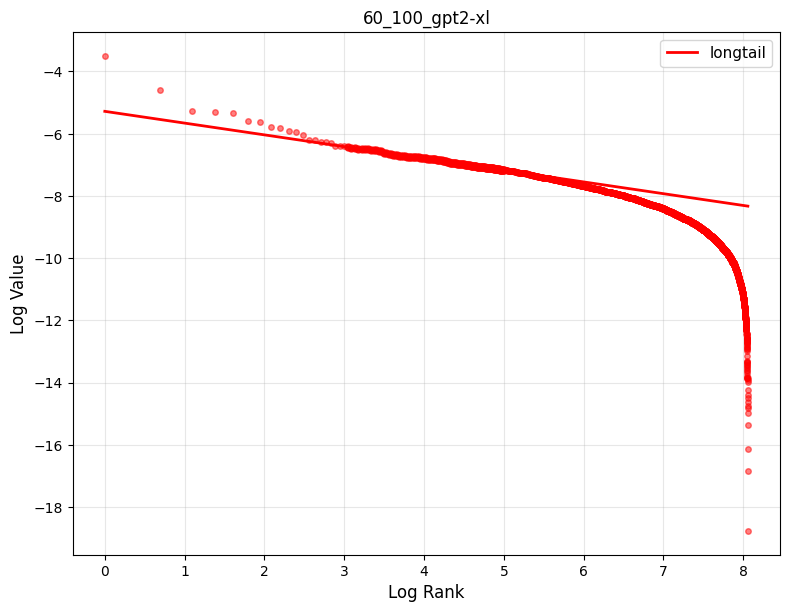

Have not got results of 40: EleutherAI/pythia-70m-deduped
Have not got results of 40: EleutherAI/pythia-160m-deduped
Have not got results of 40: EleutherAI/pythia-410m-deduped
1875


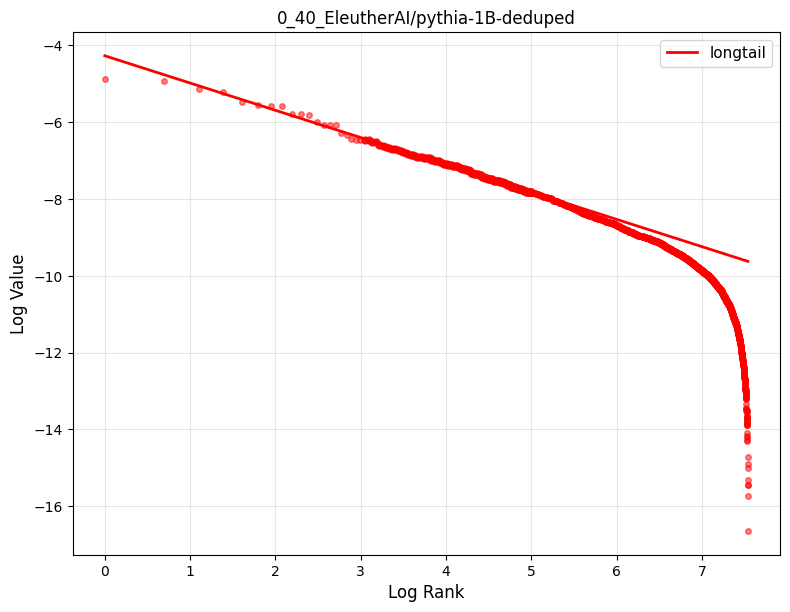

3677


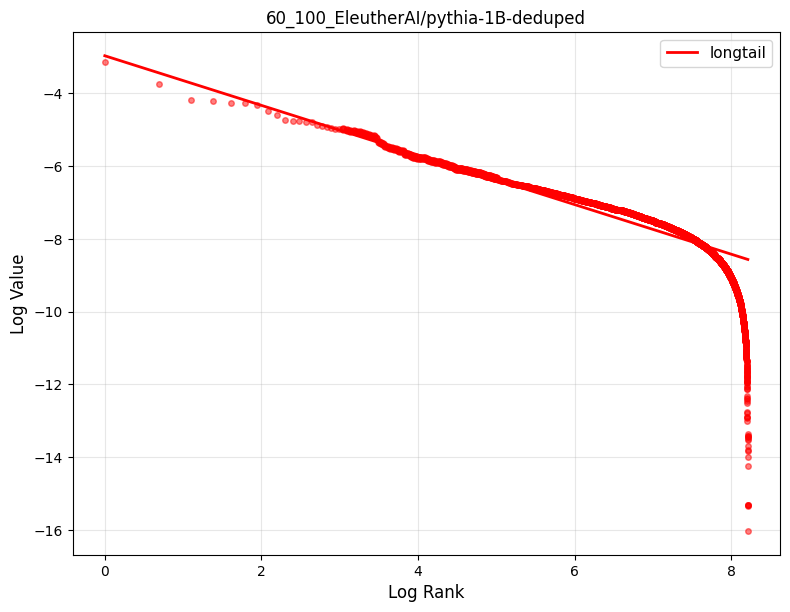

Have not got results of 40: EleutherAI/pythia-1.4B-deduped
Have not got results of 40: EleutherAI/pythia-2.8B-deduped
1735


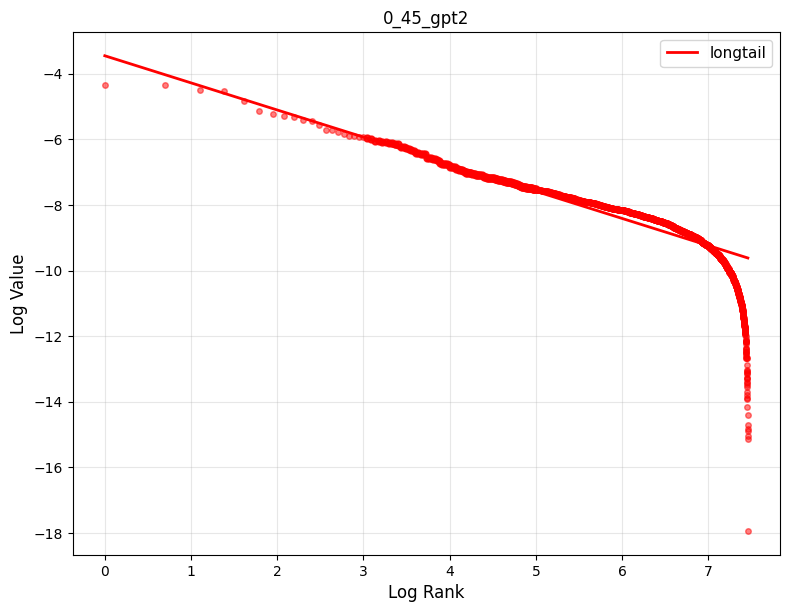

1519


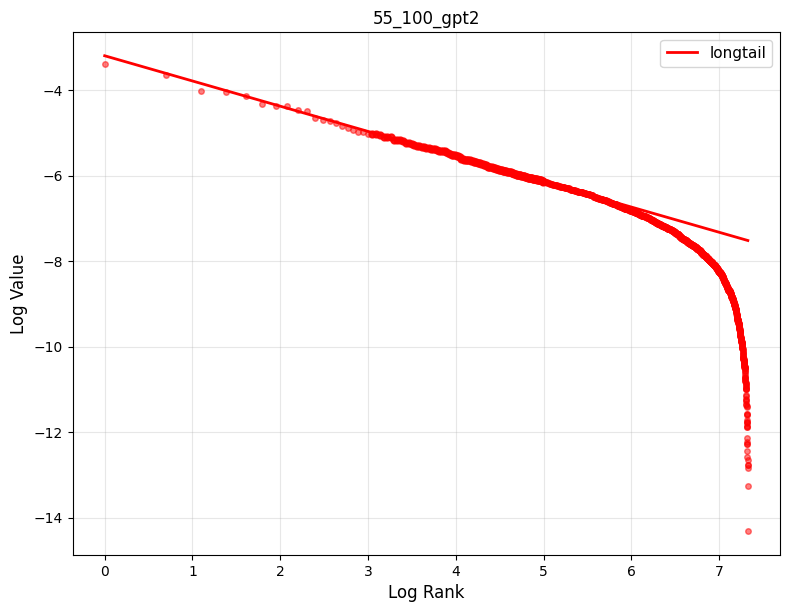

2127


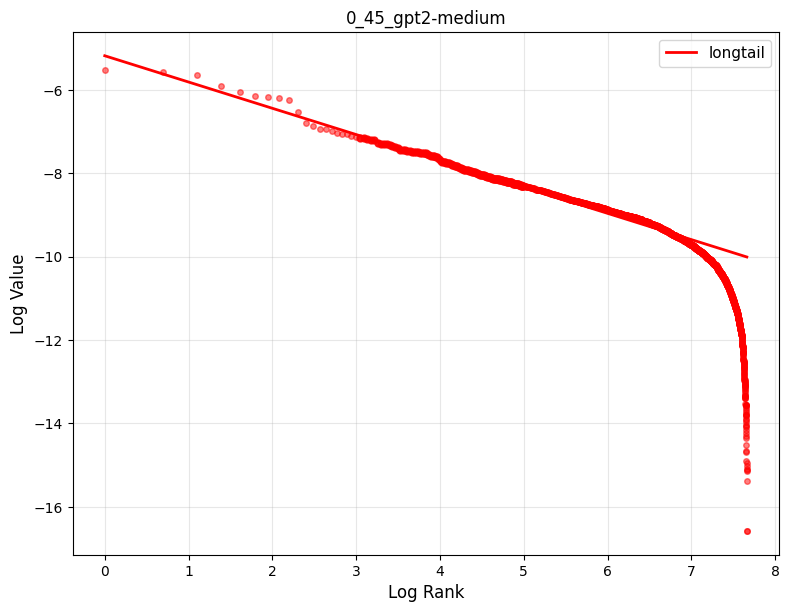

2115


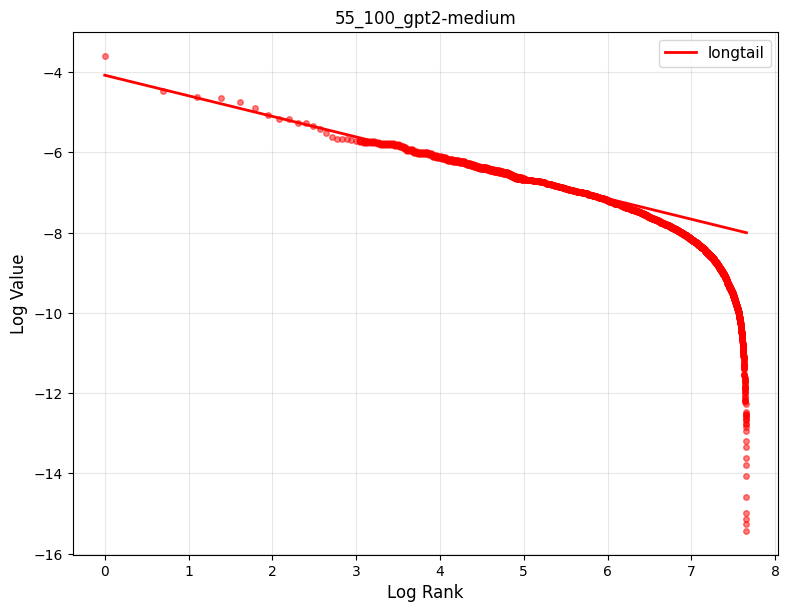

2614


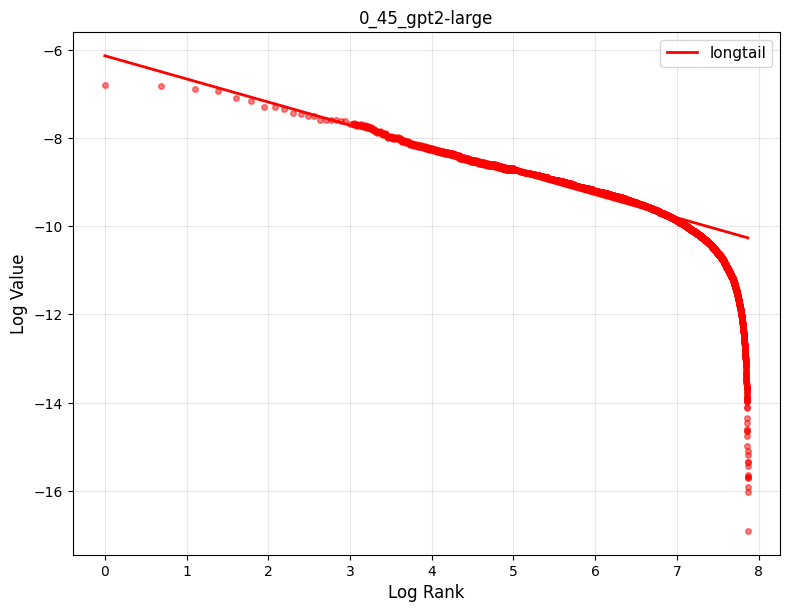

2585


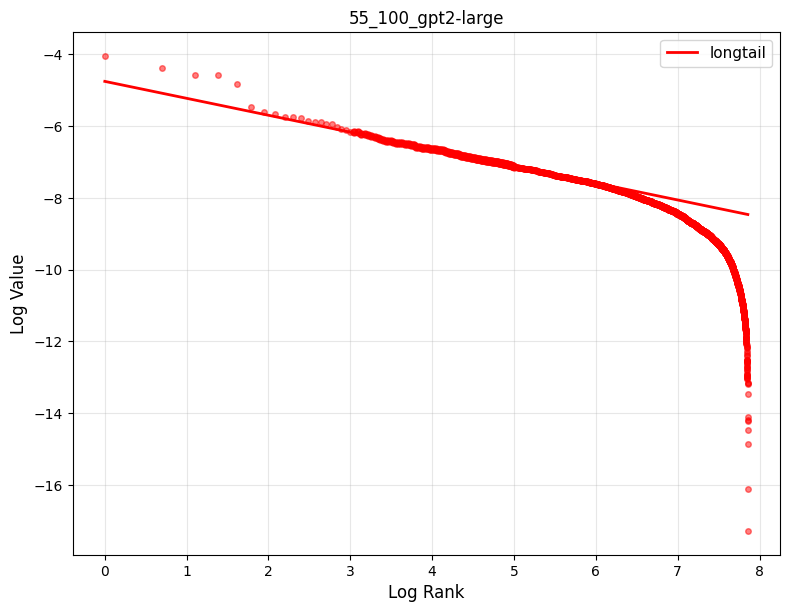

3267


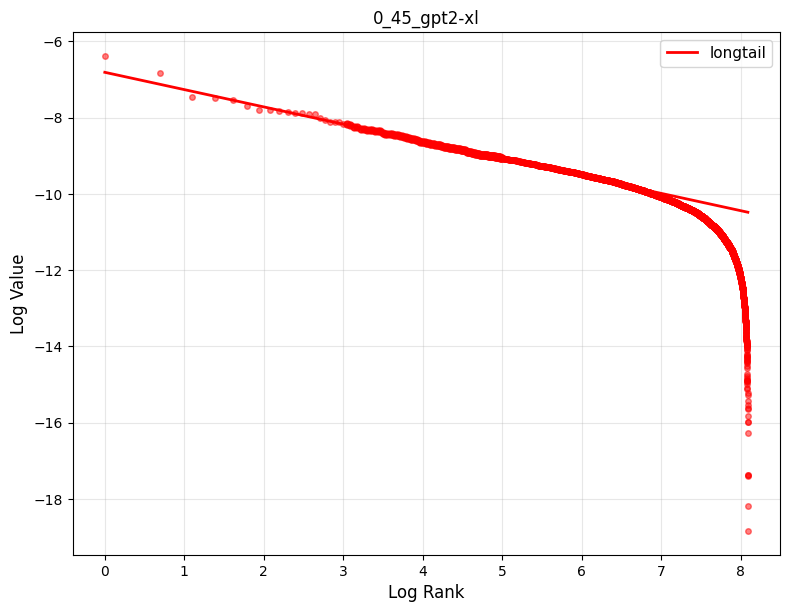

3169


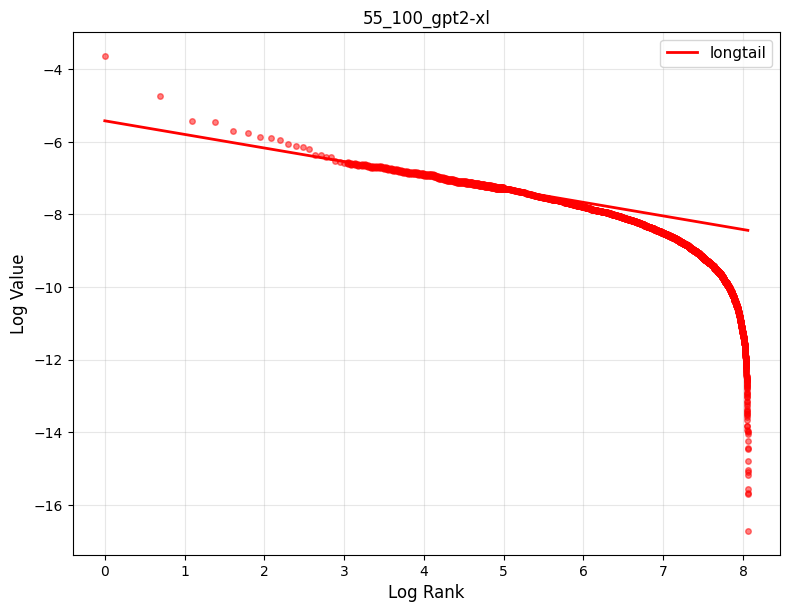

Have not got results of 45: EleutherAI/pythia-70m-deduped
Have not got results of 45: EleutherAI/pythia-160m-deduped
Have not got results of 45: EleutherAI/pythia-410m-deduped
1854


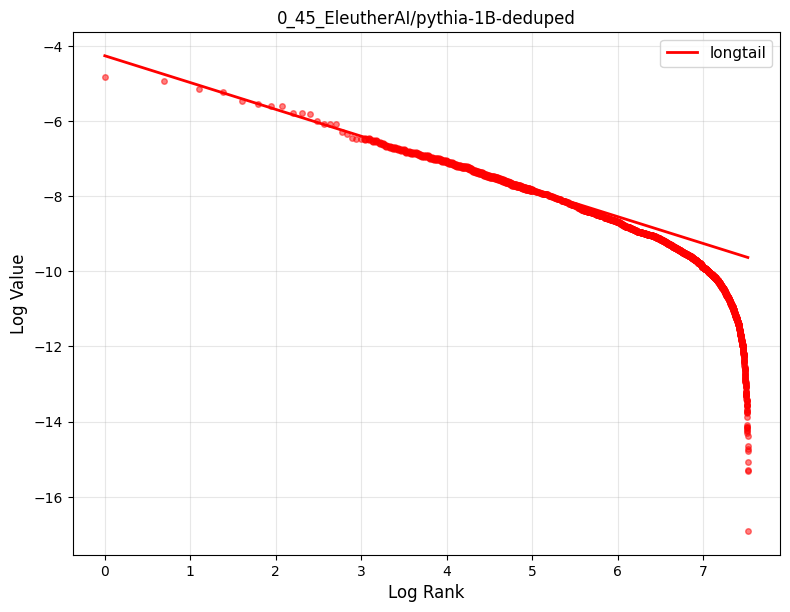

3531


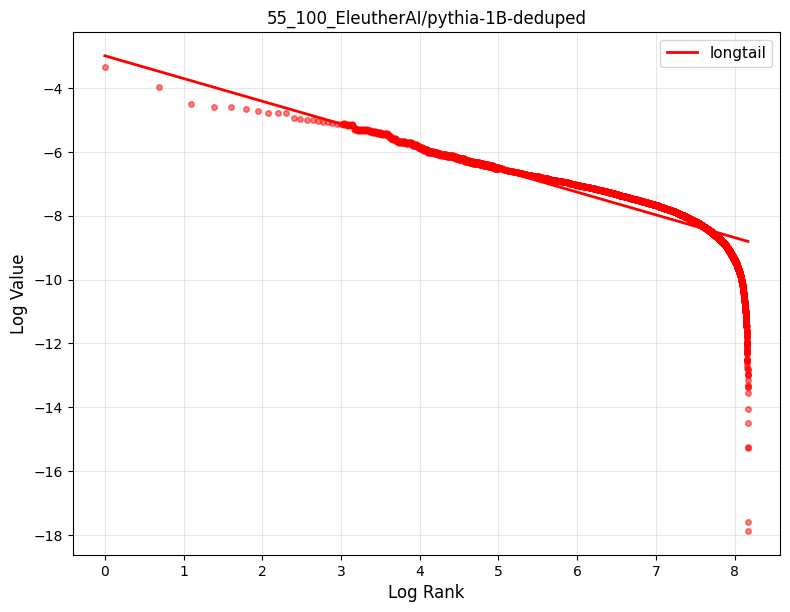

Have not got results of 45: EleutherAI/pythia-1.4B-deduped
Have not got results of 45: EleutherAI/pythia-2.8B-deduped
1735


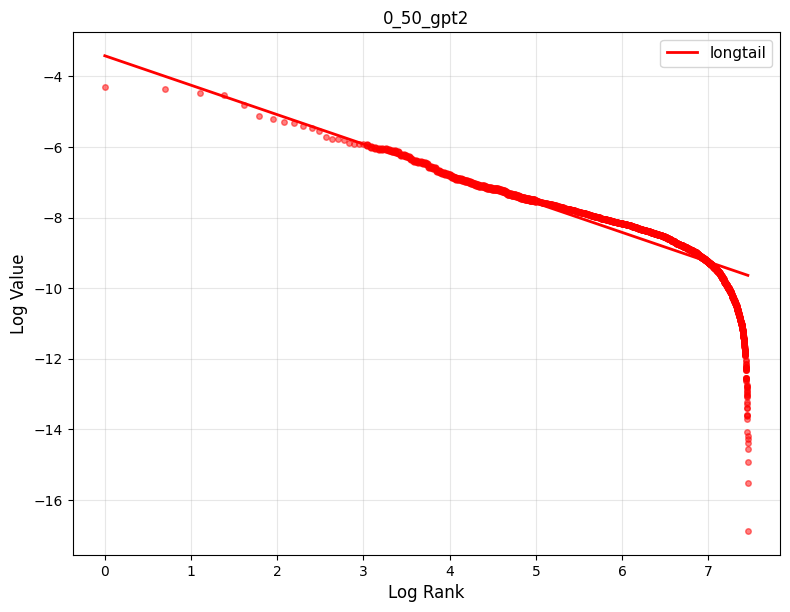

1510


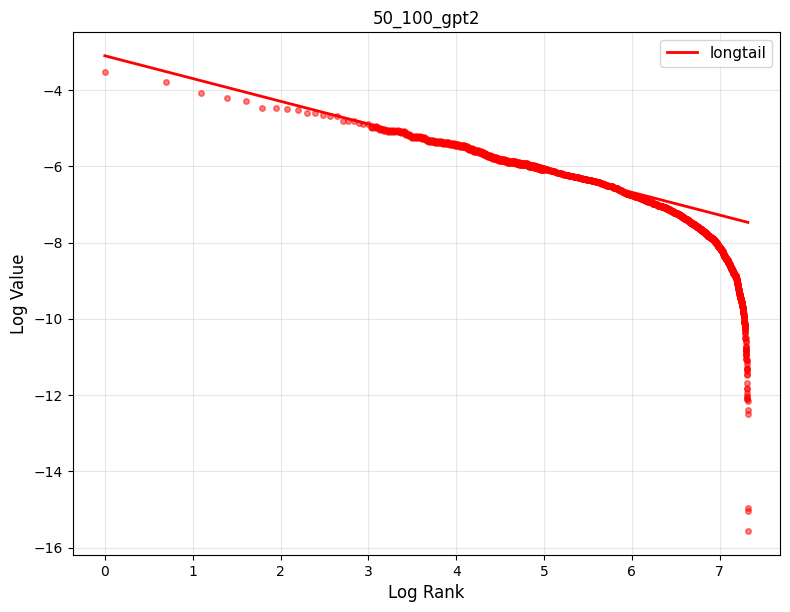

2117


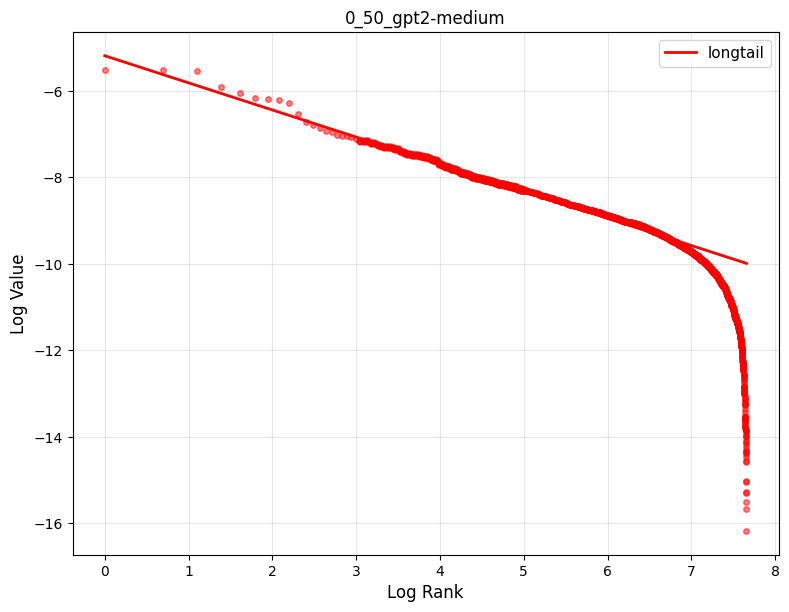

2117


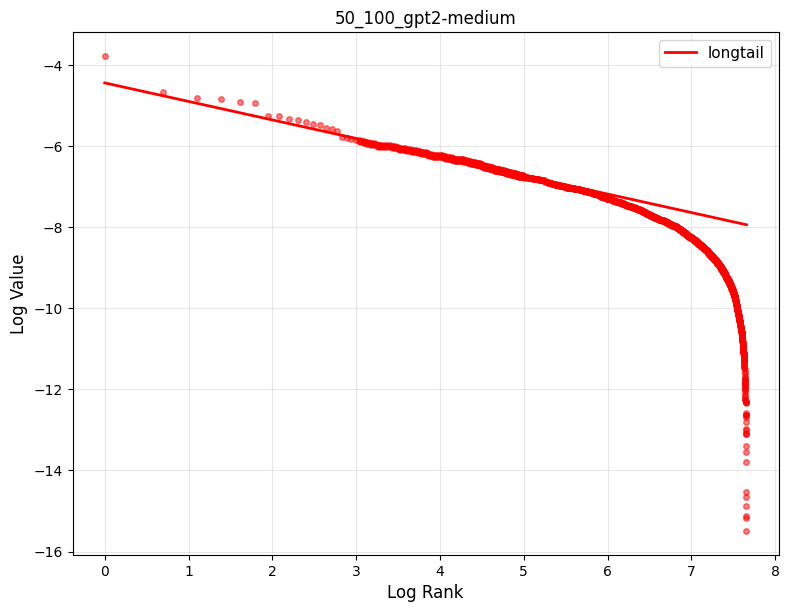

2613


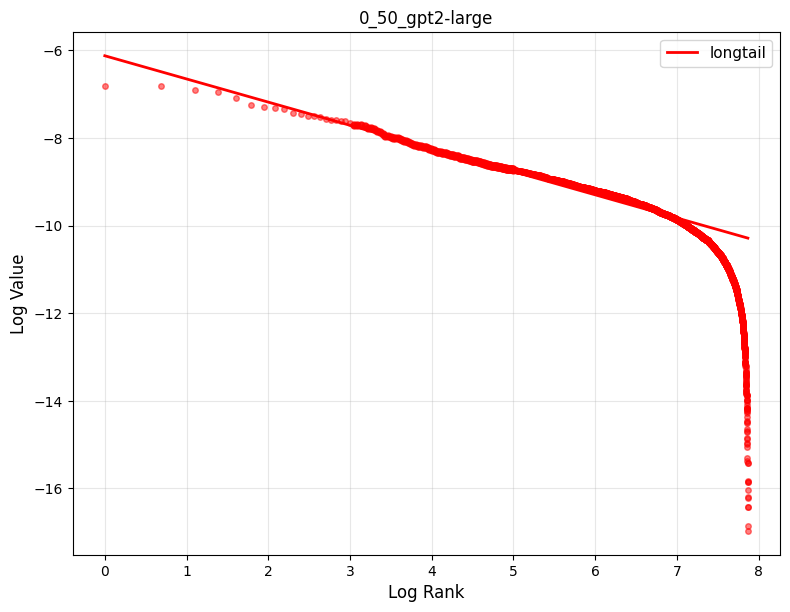

2618


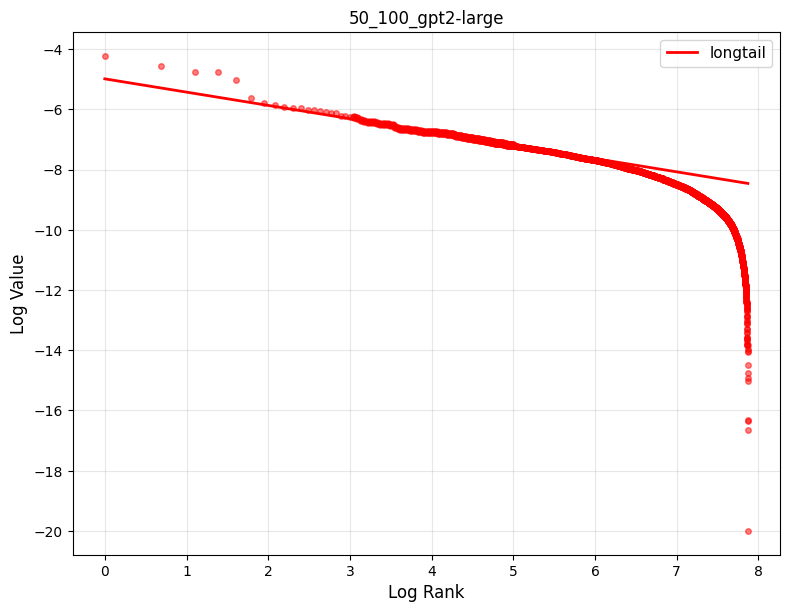

3262


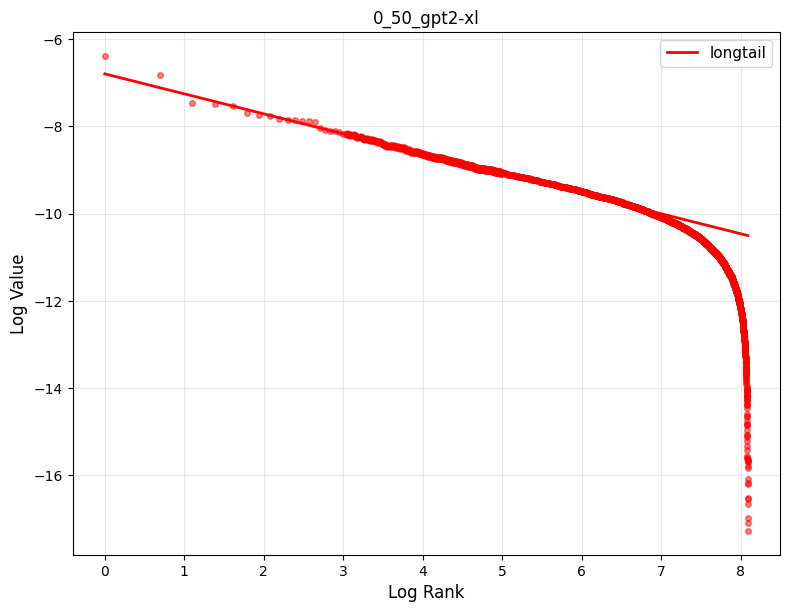

3221


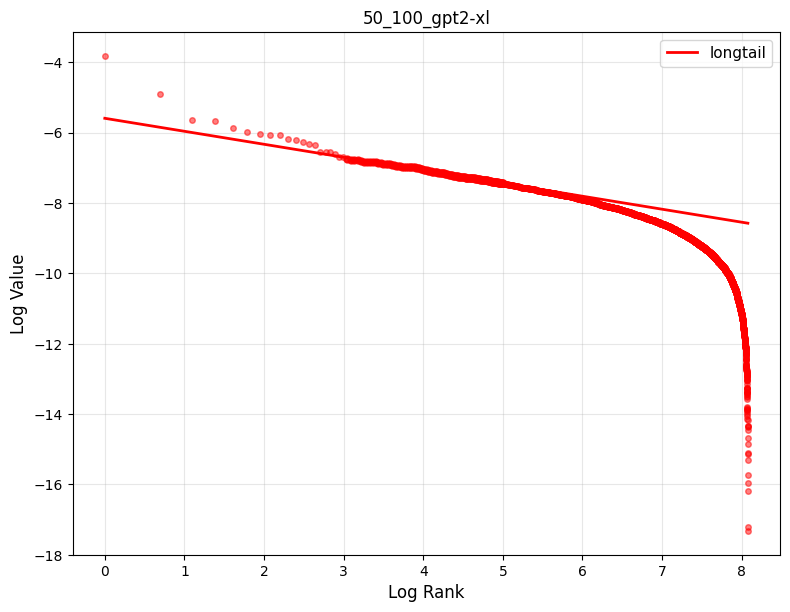

Have not got results of 50: EleutherAI/pythia-70m-deduped
Have not got results of 50: EleutherAI/pythia-160m-deduped
Have not got results of 50: EleutherAI/pythia-410m-deduped
1919


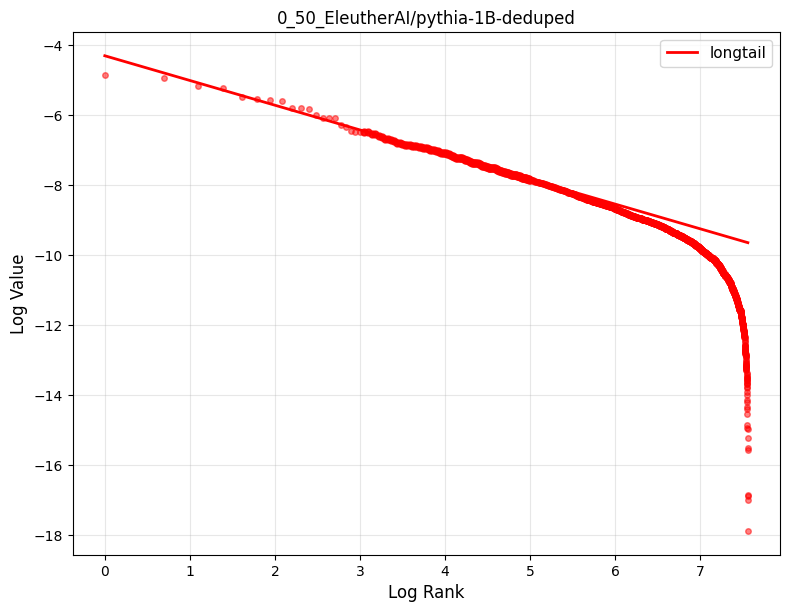

3830


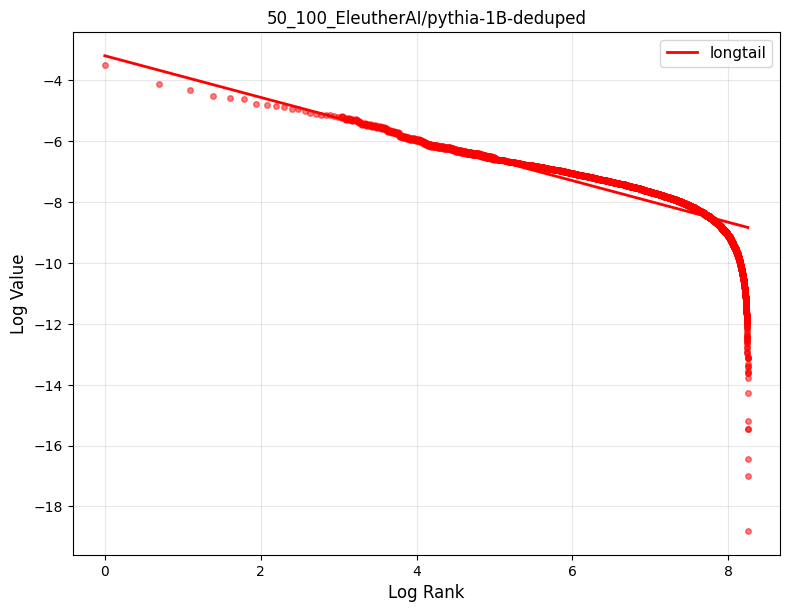

Have not got results of 50: EleutherAI/pythia-1.4B-deduped
Have not got results of 50: EleutherAI/pythia-2.8B-deduped


In [31]:
interval_lst = [5,10,15,20,25,30,35,40,45,50]

model_lst = [
    "gpt2",
    "gpt2-medium",
    "gpt2-large",
    "gpt2-xl",
    "EleutherAI/pythia-70m-deduped",
    "EleutherAI/pythia-160m-deduped",
    "EleutherAI/pythia-410m-deduped",
    "EleutherAI/pythia-1B-deduped",
    "EleutherAI/pythia-1.4B-deduped",
    "EleutherAI/pythia-2.8B-deduped",
]

for interval in interval_lst:
    for model in model_lst:
        try:
            plot_all(interval,model,y_col = "delta_loss_post",linear_region=(3, 5))
        except:
            print(f"Have not got results of {interval}: {model}")



1727


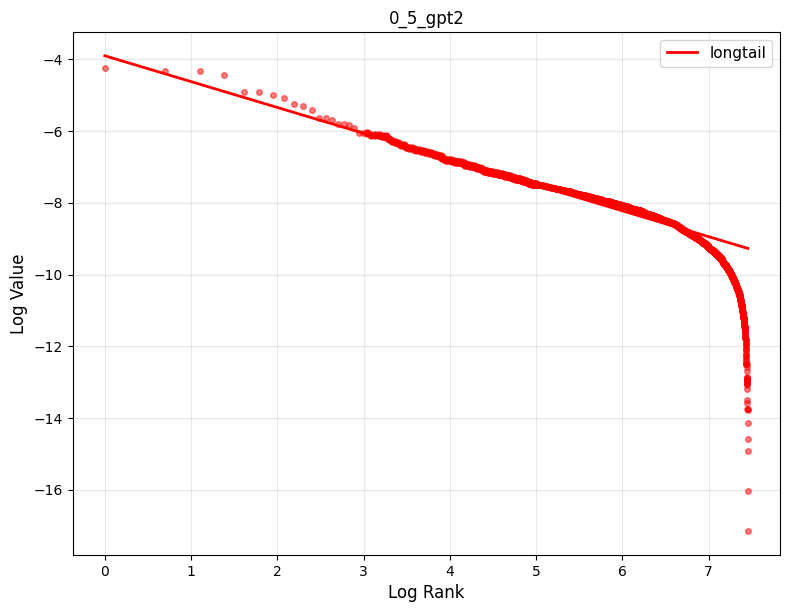

1579


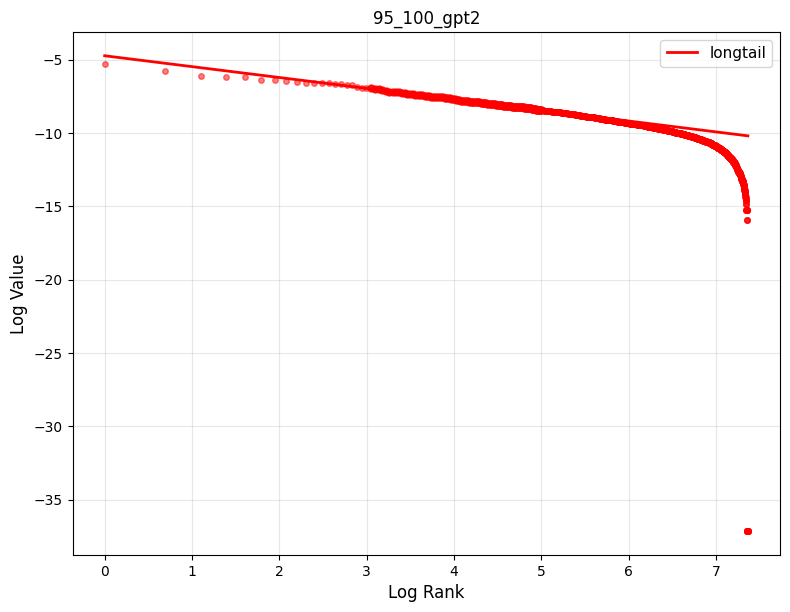

2105


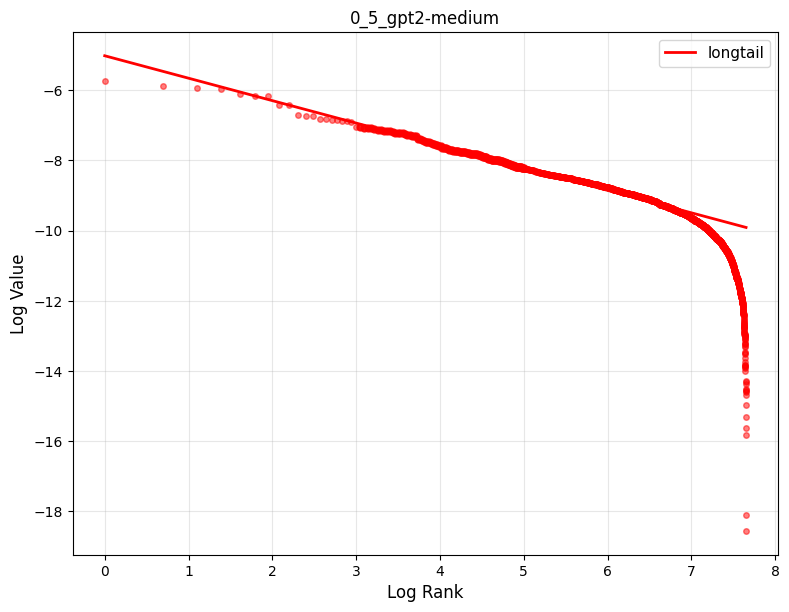

2062


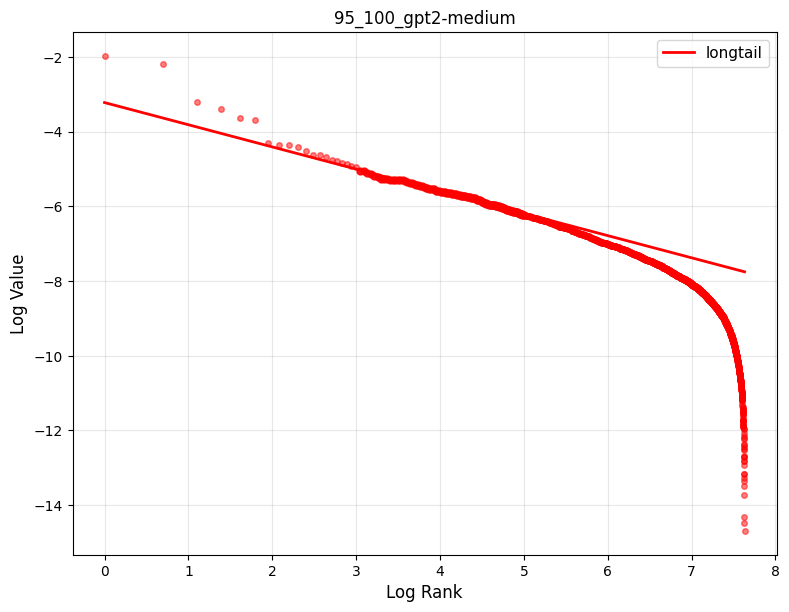

2652


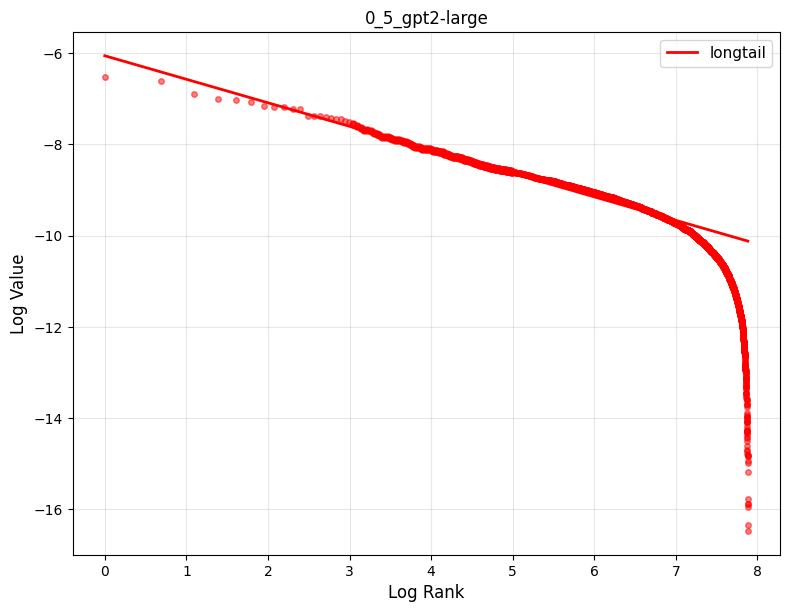

2763


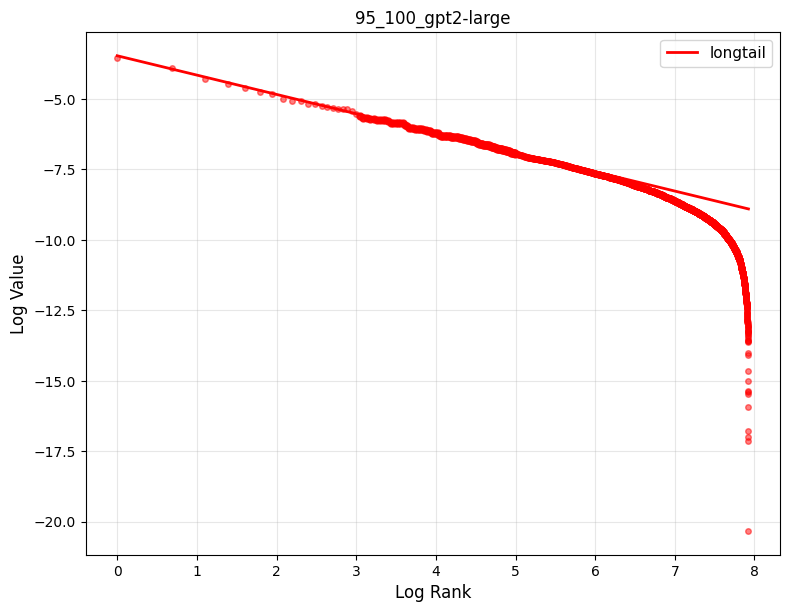

3233


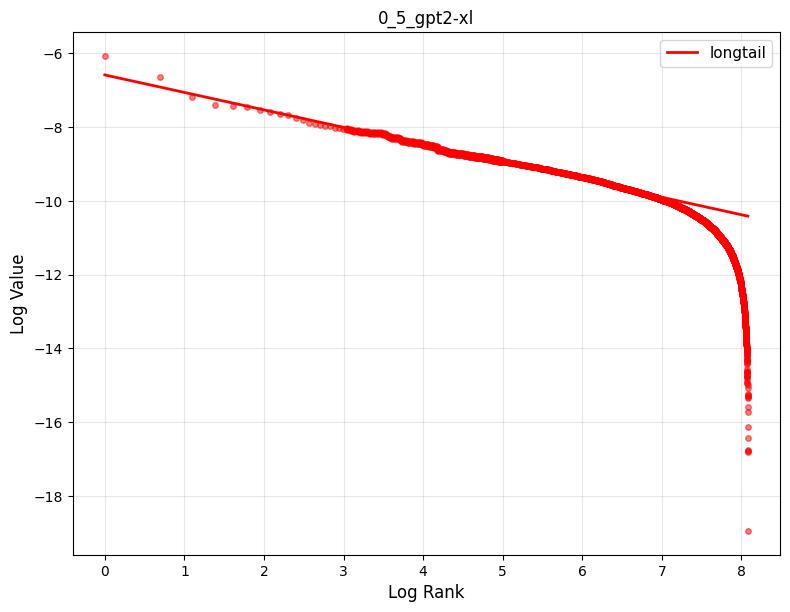

3441


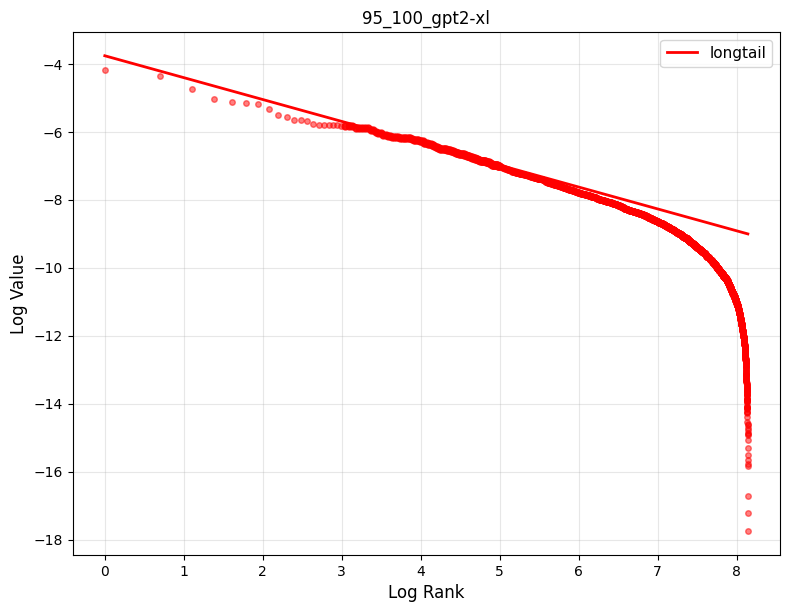

Have not got results of 5: EleutherAI/pythia-70m-deduped
Have not got results of 5: EleutherAI/pythia-160m-deduped
Have not got results of 5: EleutherAI/pythia-410m-deduped
2041


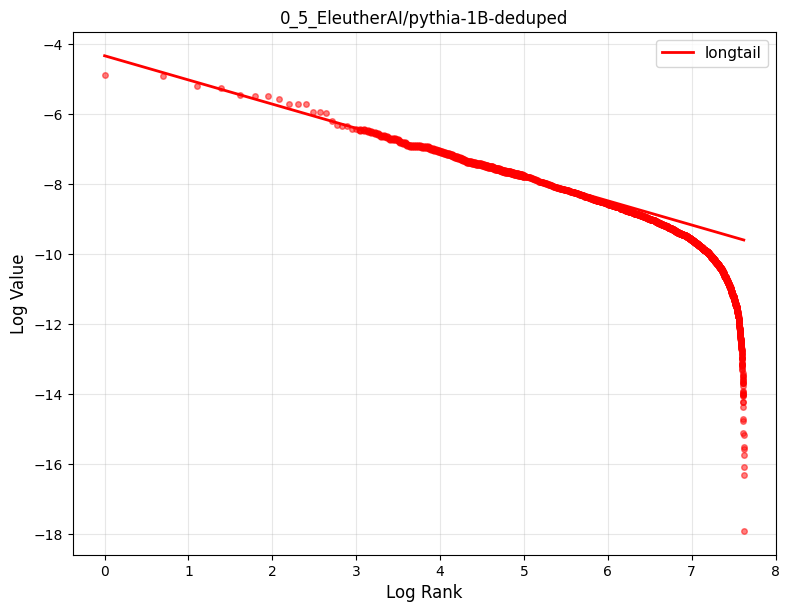

457


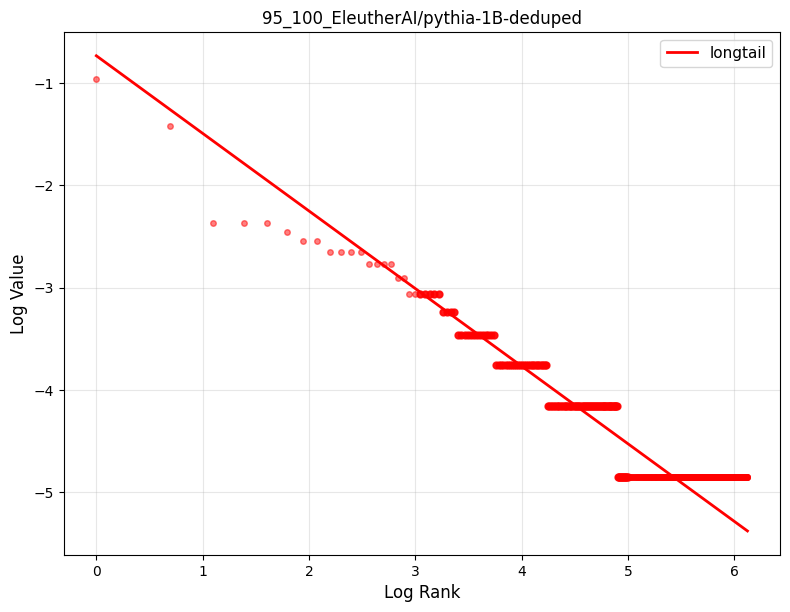

3417


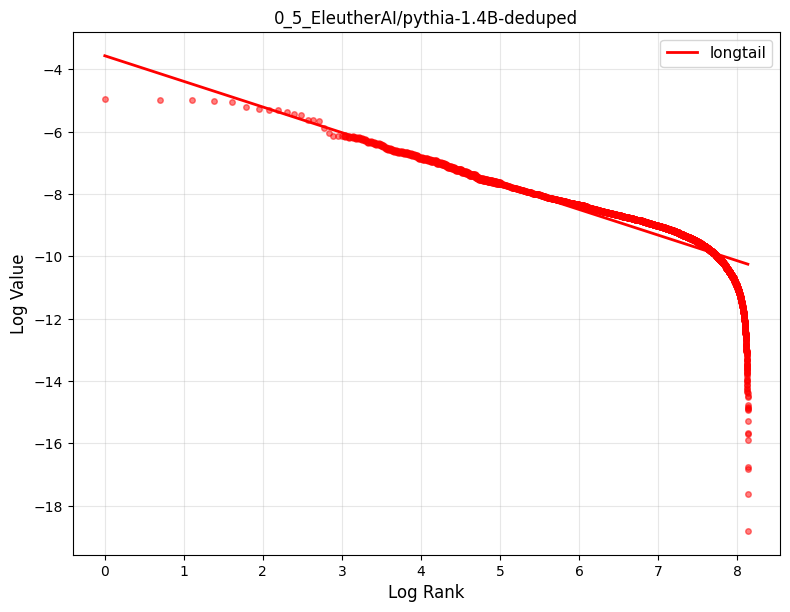

Have not got results of 5: EleutherAI/pythia-1.4B-deduped
Have not got results of 5: EleutherAI/pythia-2.8B-deduped
1734


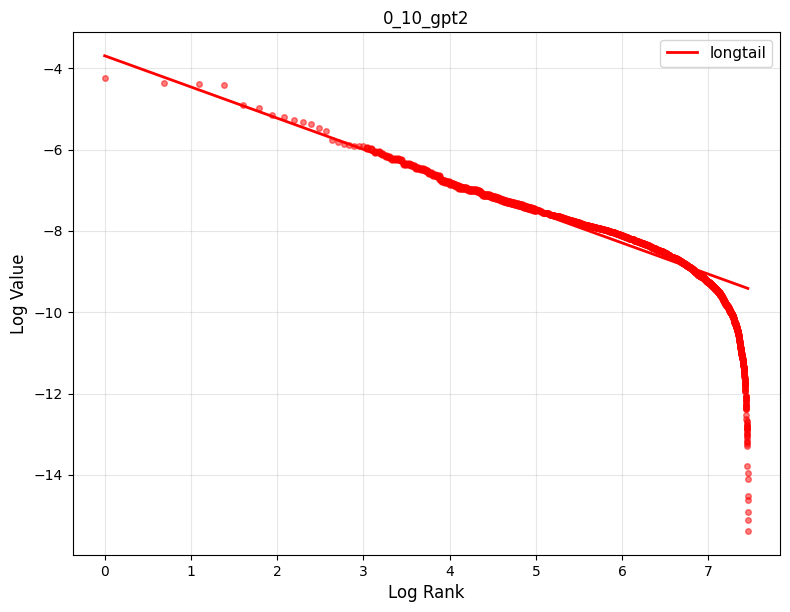

1556


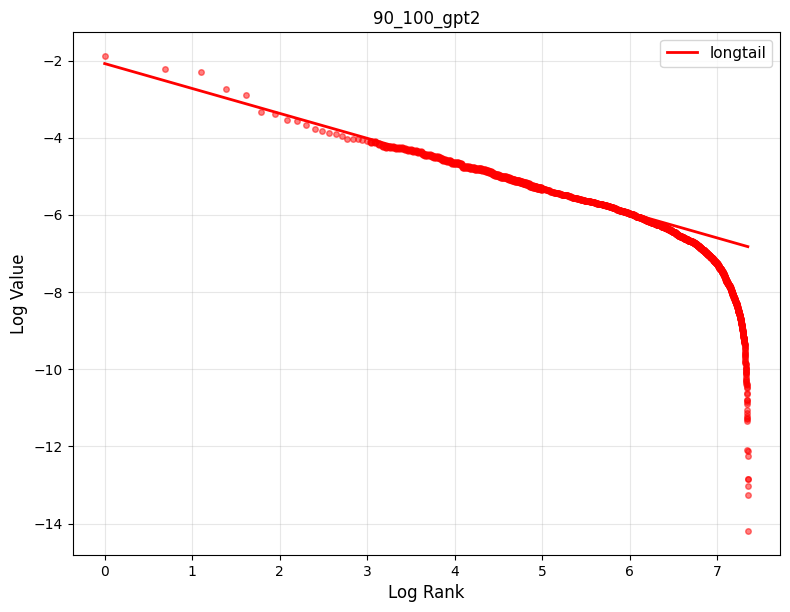

2135


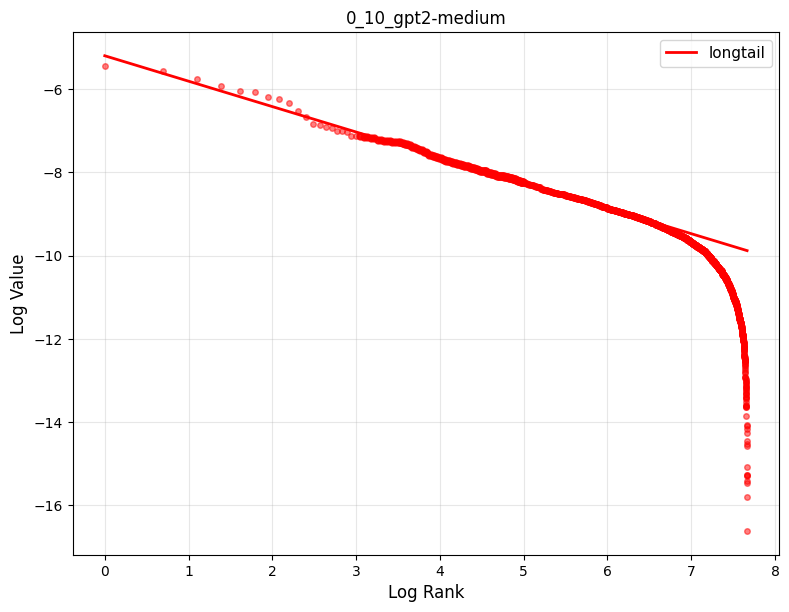

2003


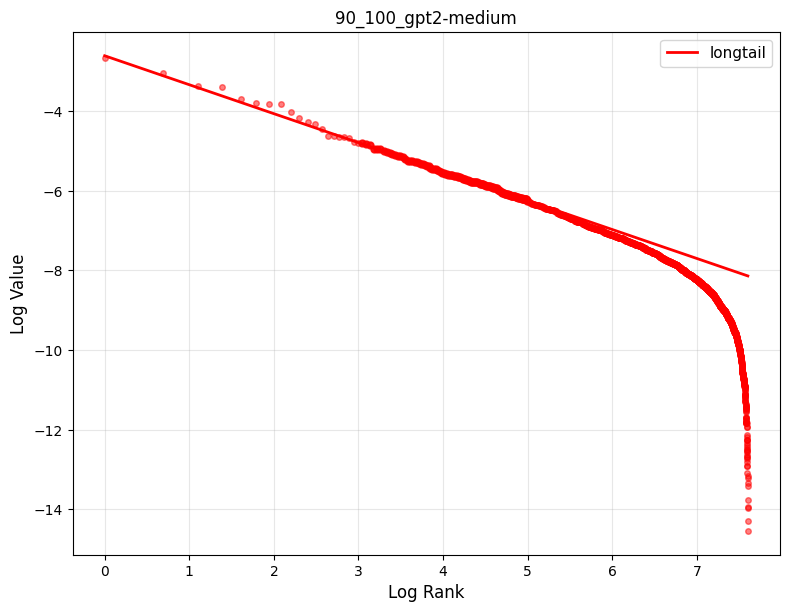

2642


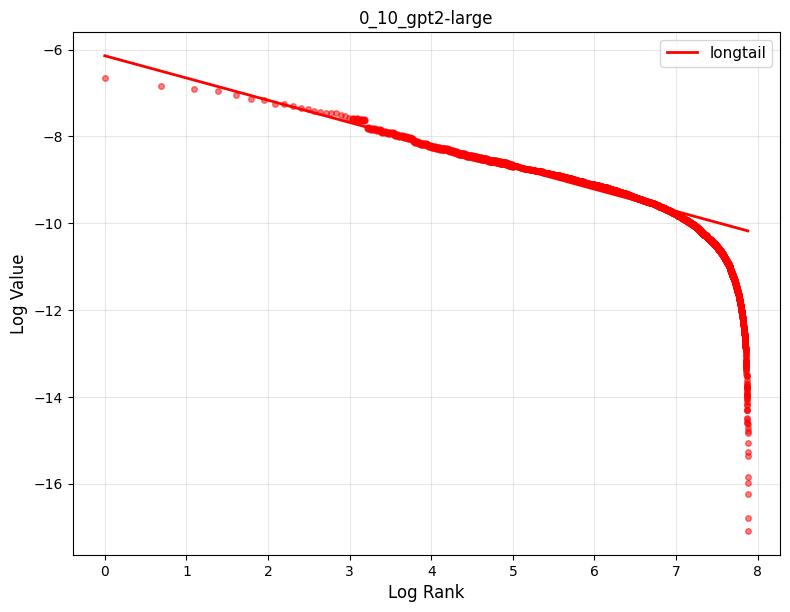

2650


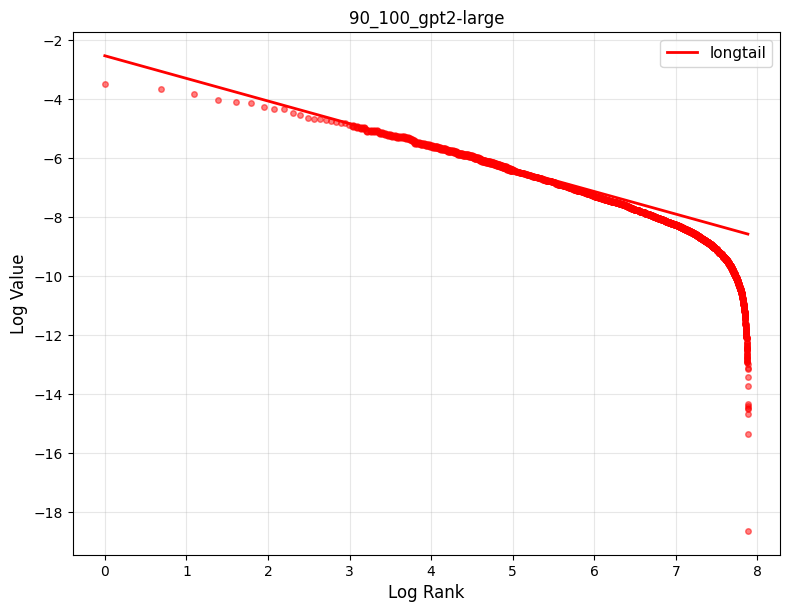

3241


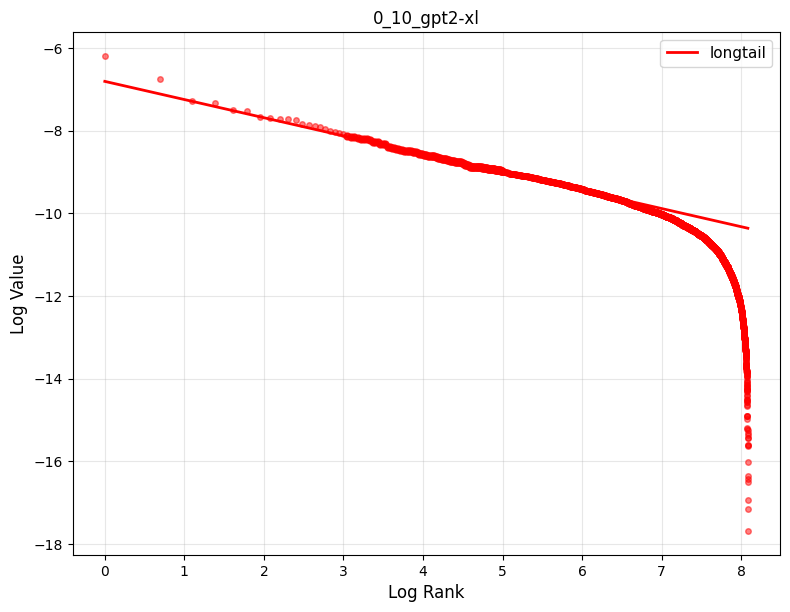

3227


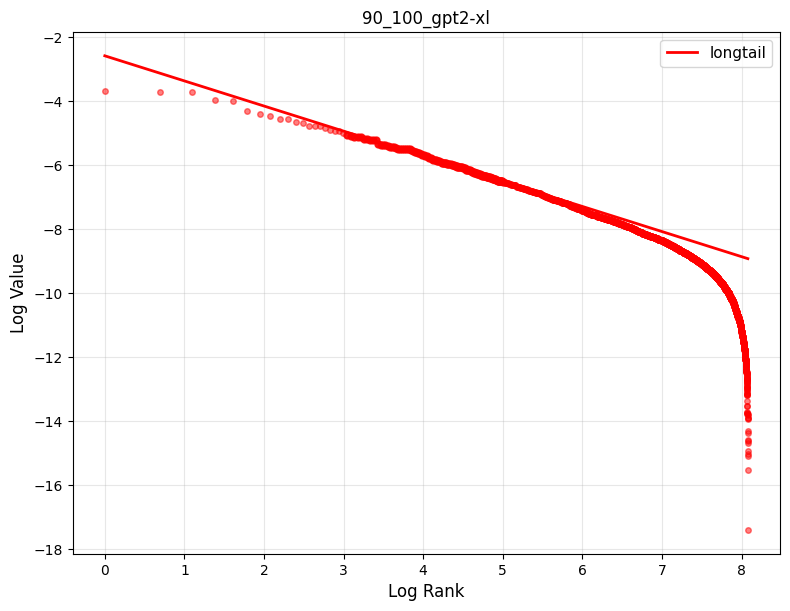

Have not got results of 10: EleutherAI/pythia-70m-deduped
Have not got results of 10: EleutherAI/pythia-160m-deduped
Have not got results of 10: EleutherAI/pythia-410m-deduped
1899


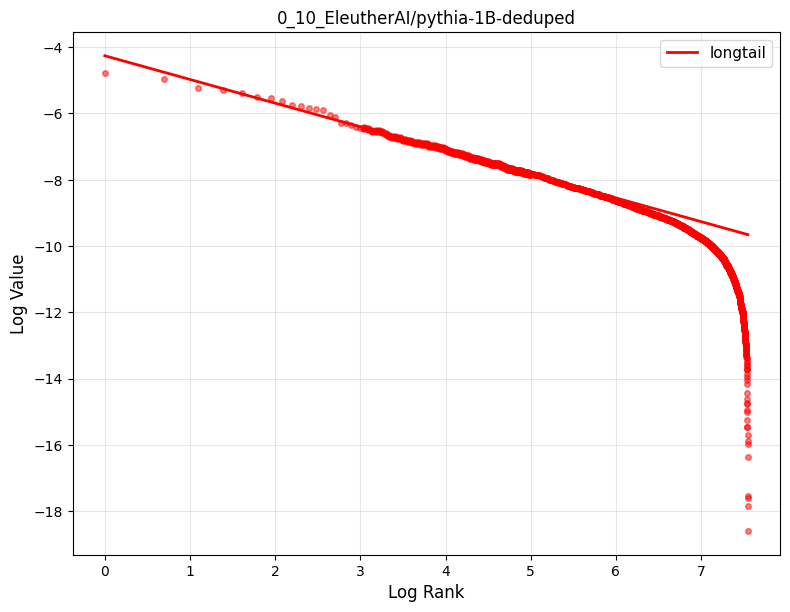

4550


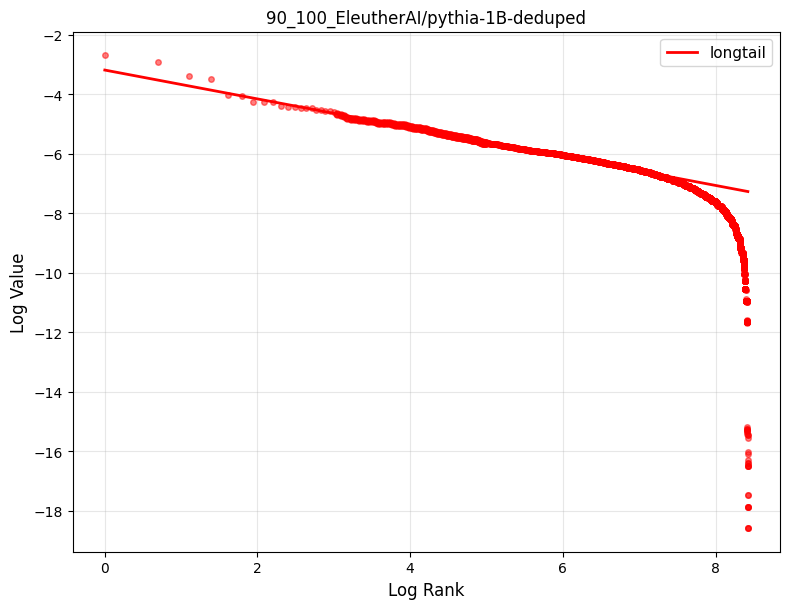

4341


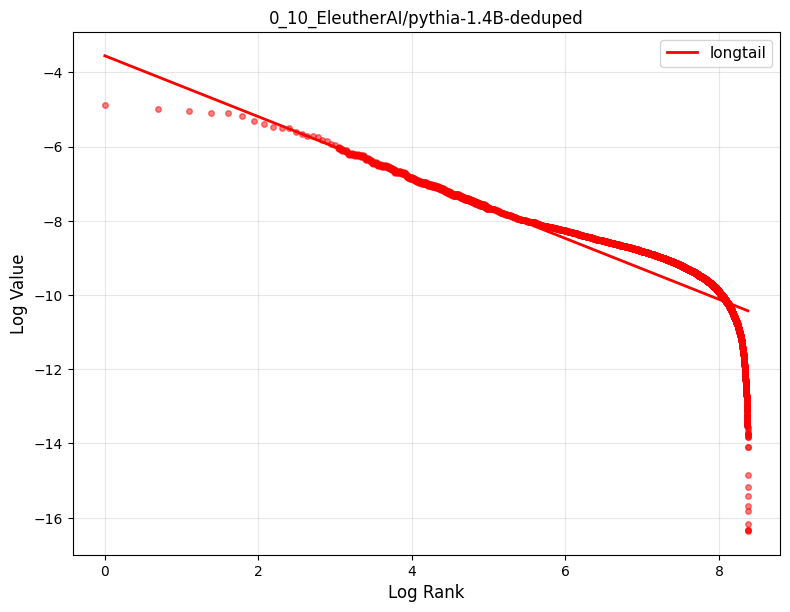

2506


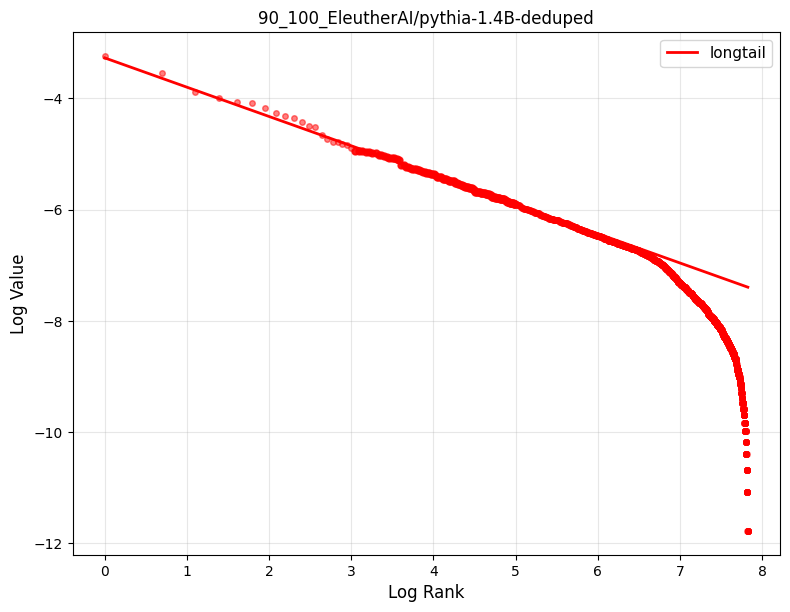

4001


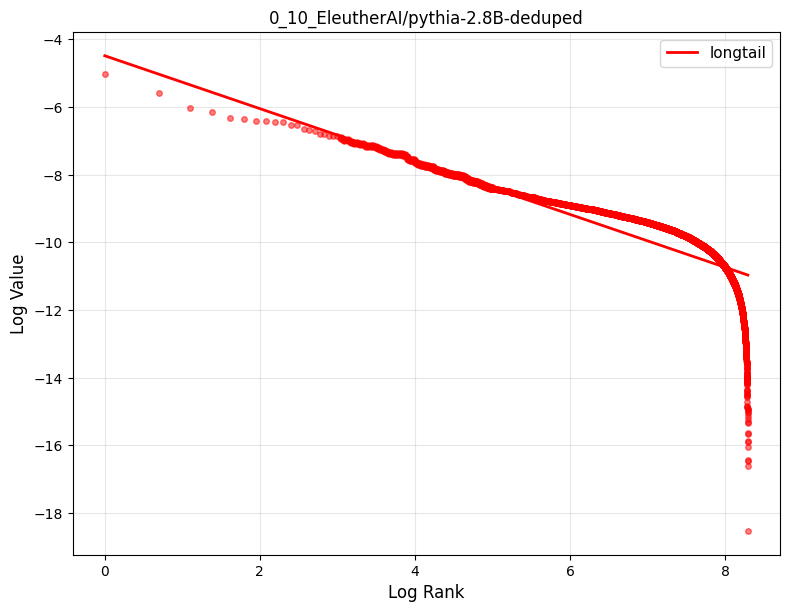

6935


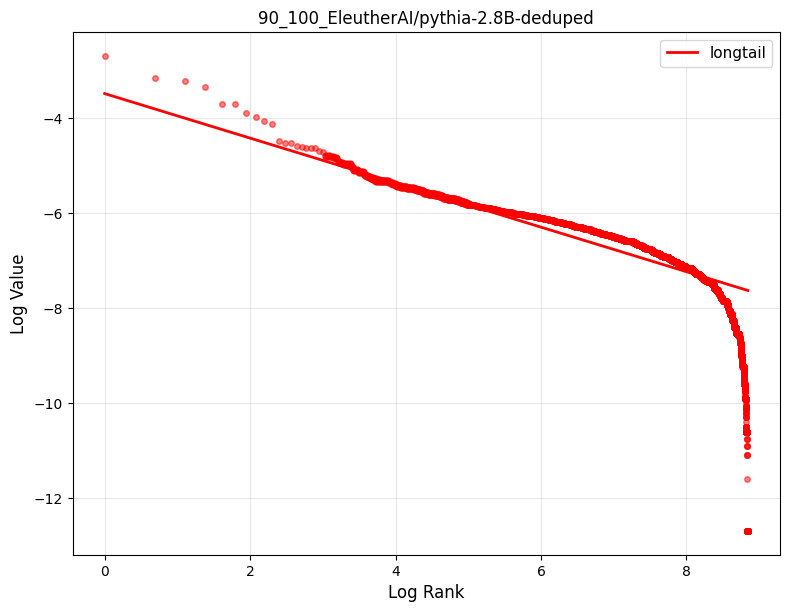

1733


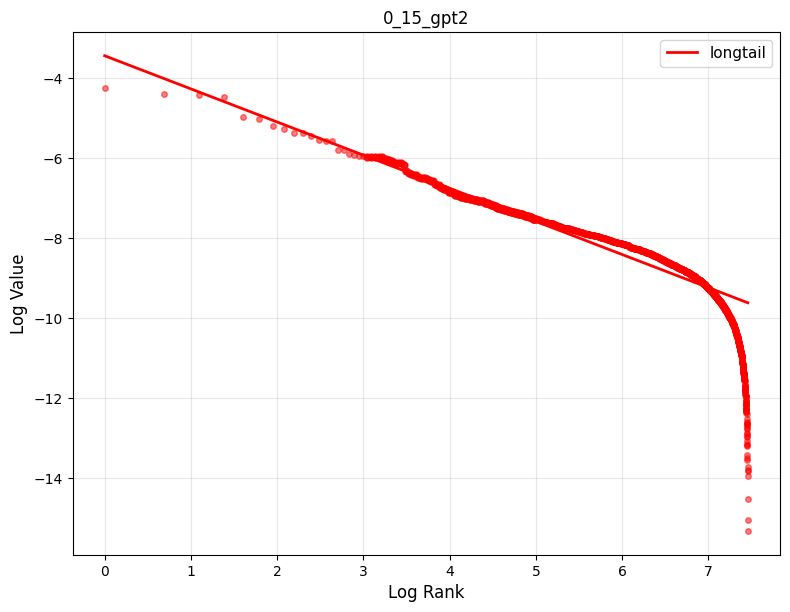

1545


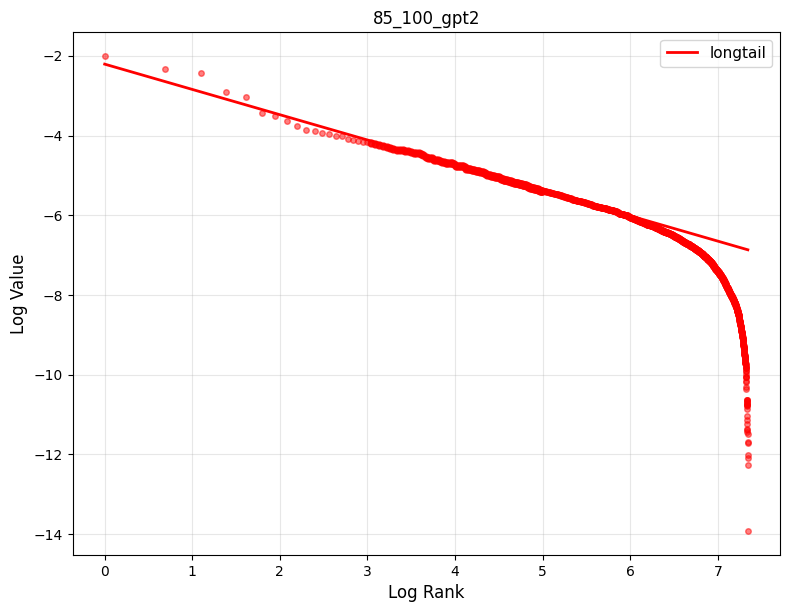

2106


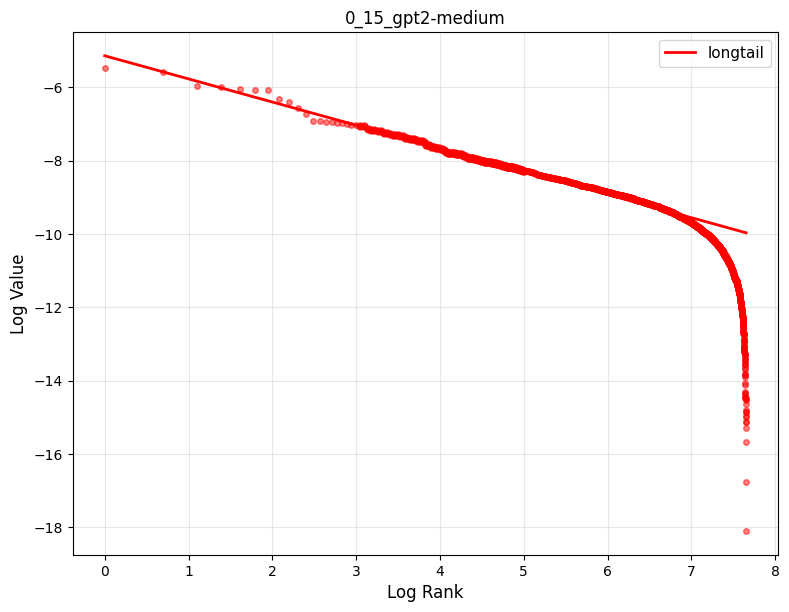

2029


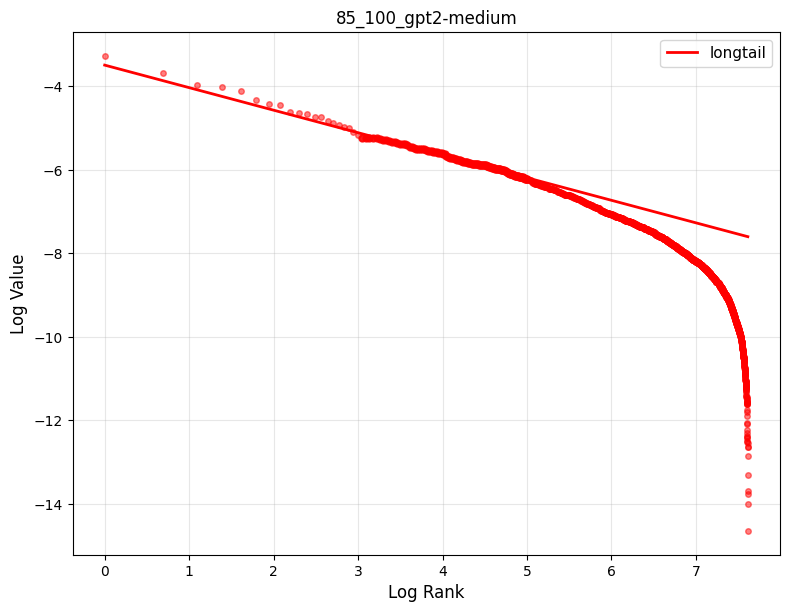

2587


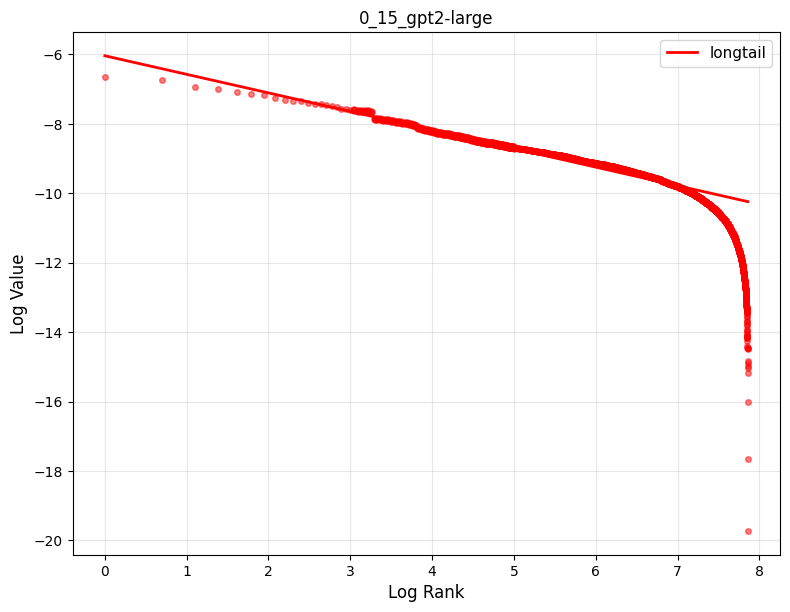

2610


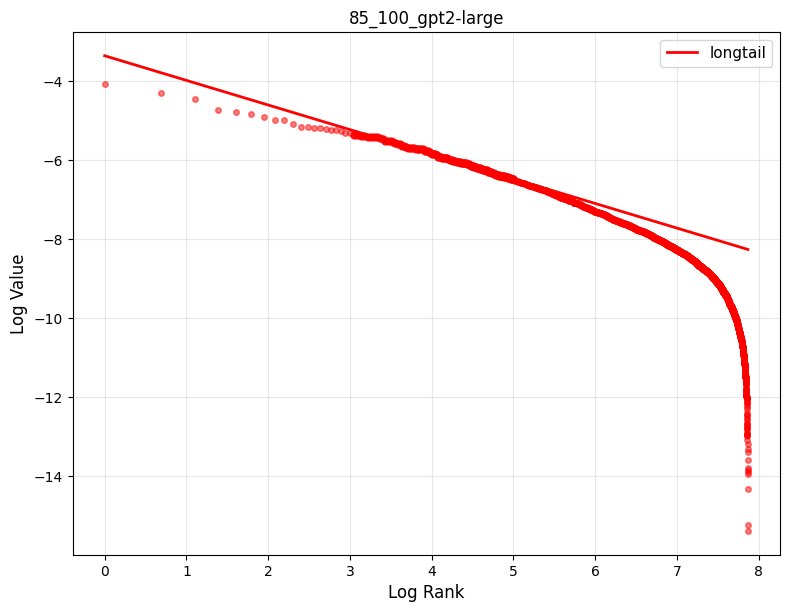

3247


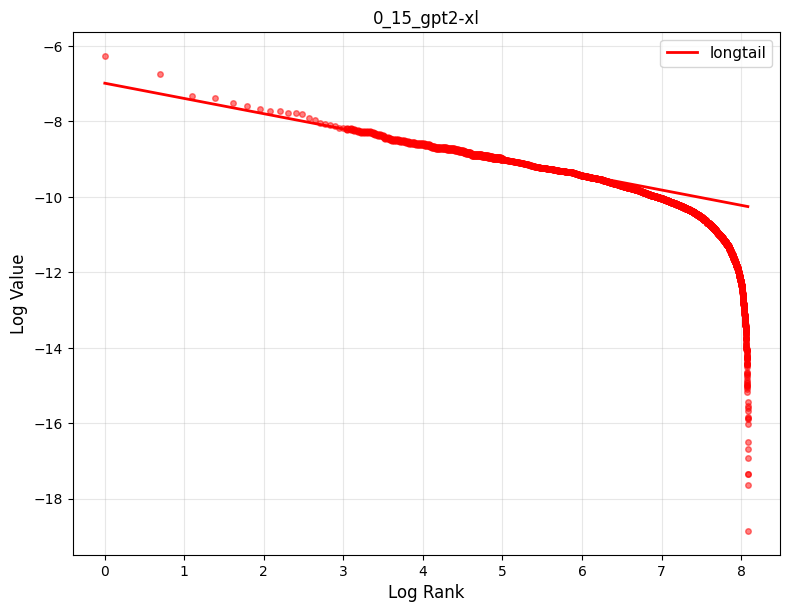

3209


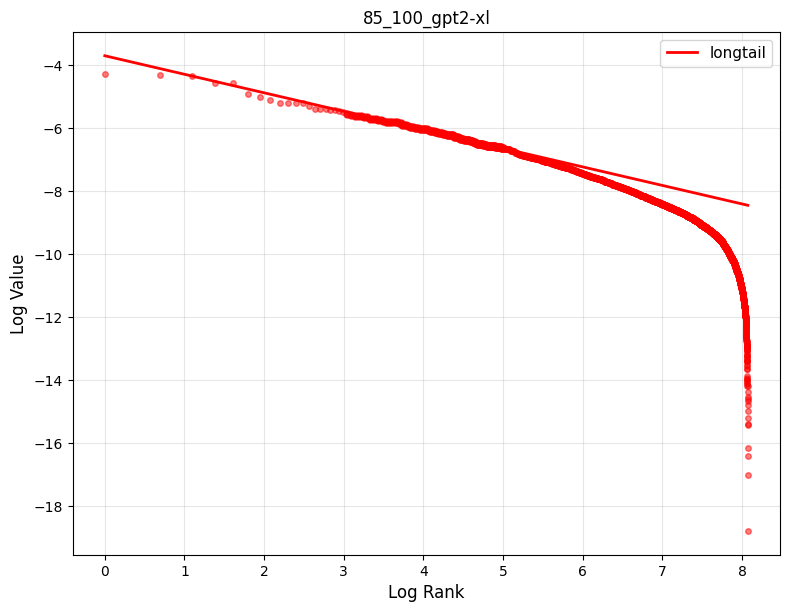

Have not got results of 15: EleutherAI/pythia-70m-deduped
Have not got results of 15: EleutherAI/pythia-160m-deduped
Have not got results of 15: EleutherAI/pythia-410m-deduped
1751


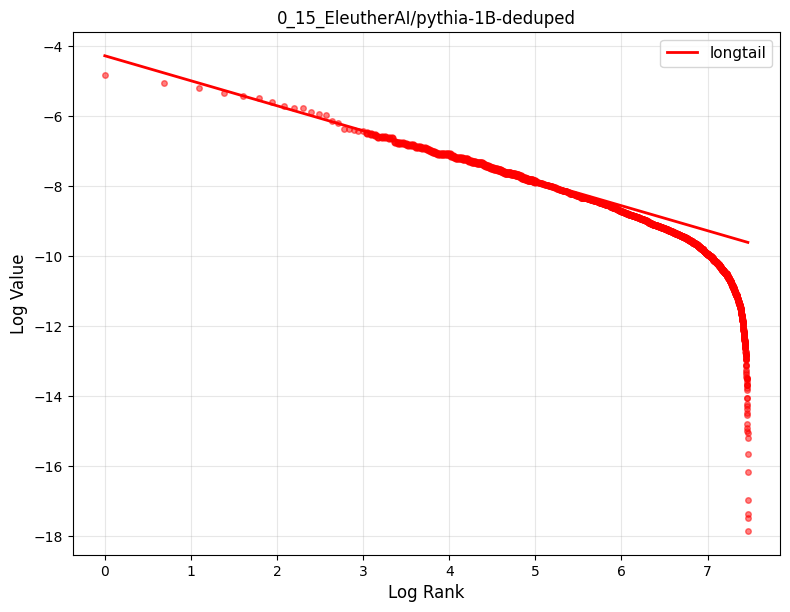

3203


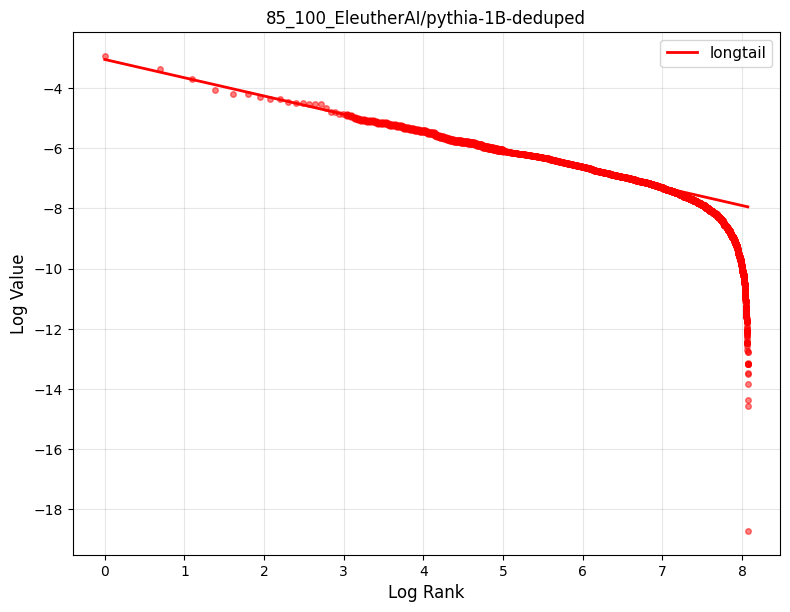

4391


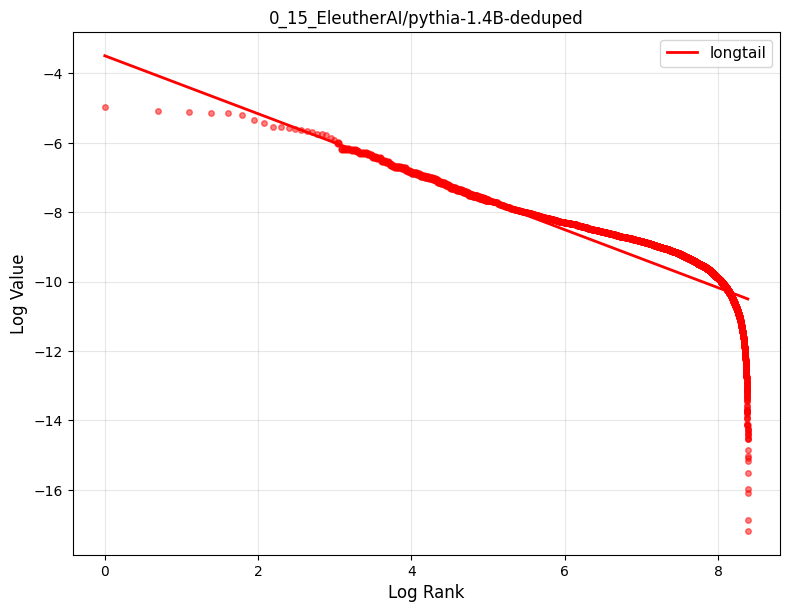

5399


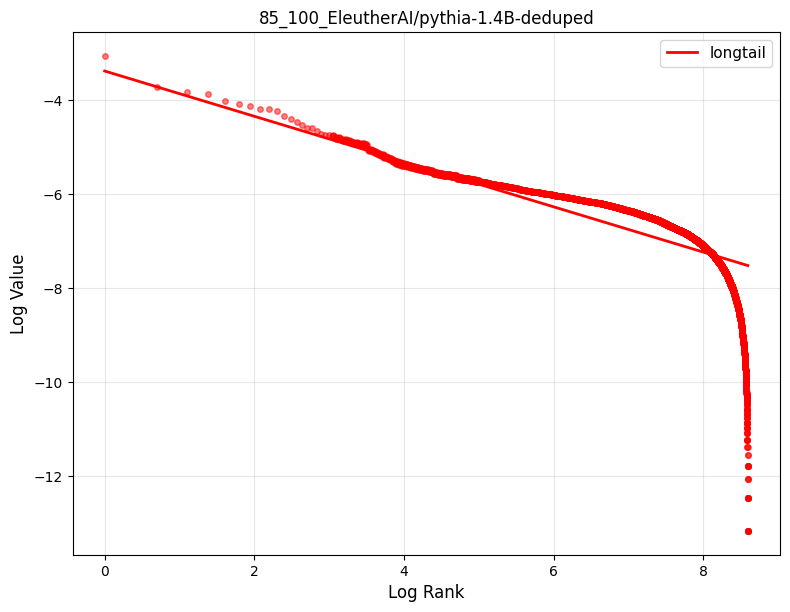

Have not got results of 15: EleutherAI/pythia-2.8B-deduped
1726


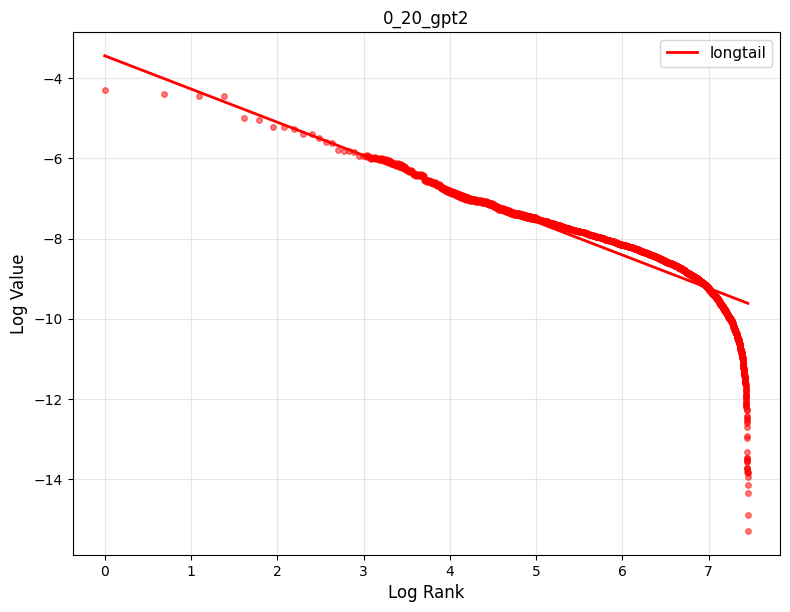

1575


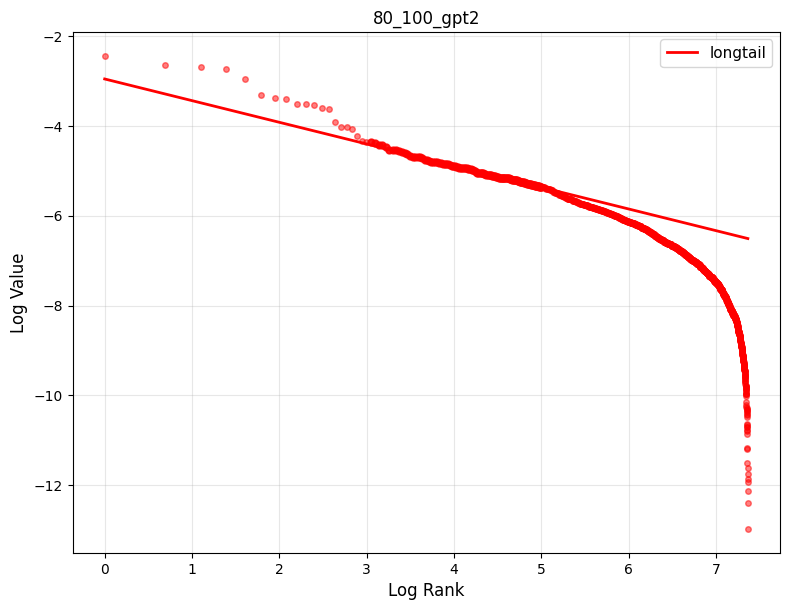

2112


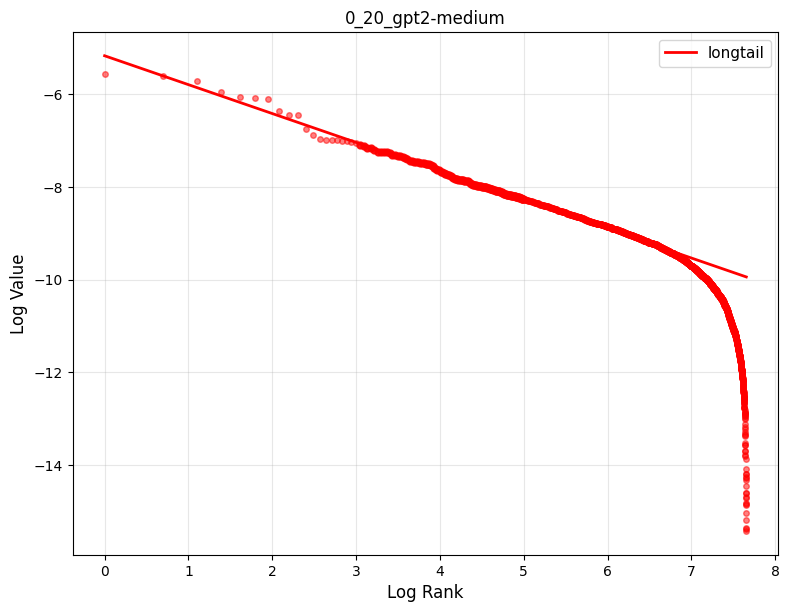

2035


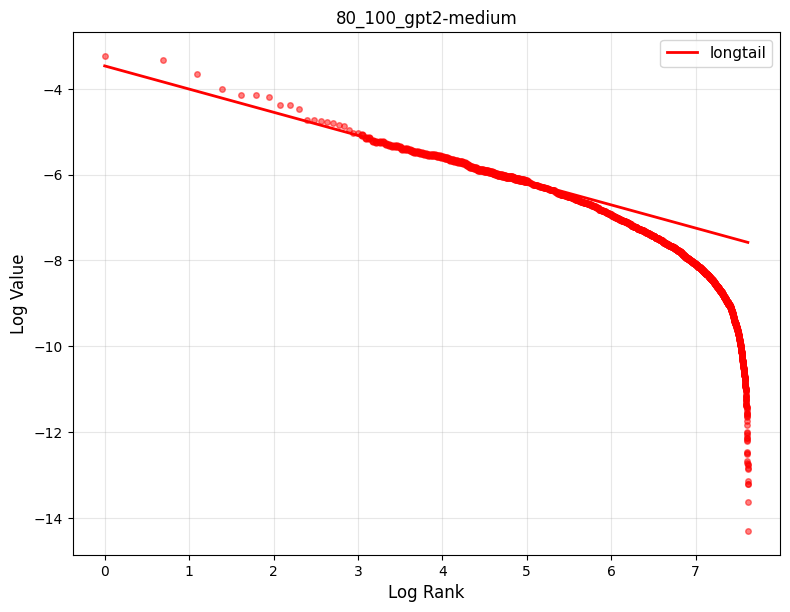

2624


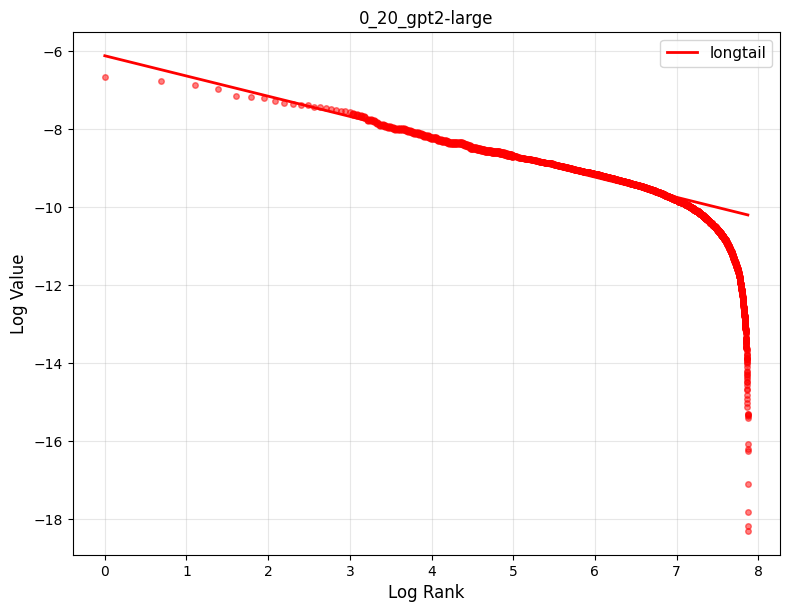

2666


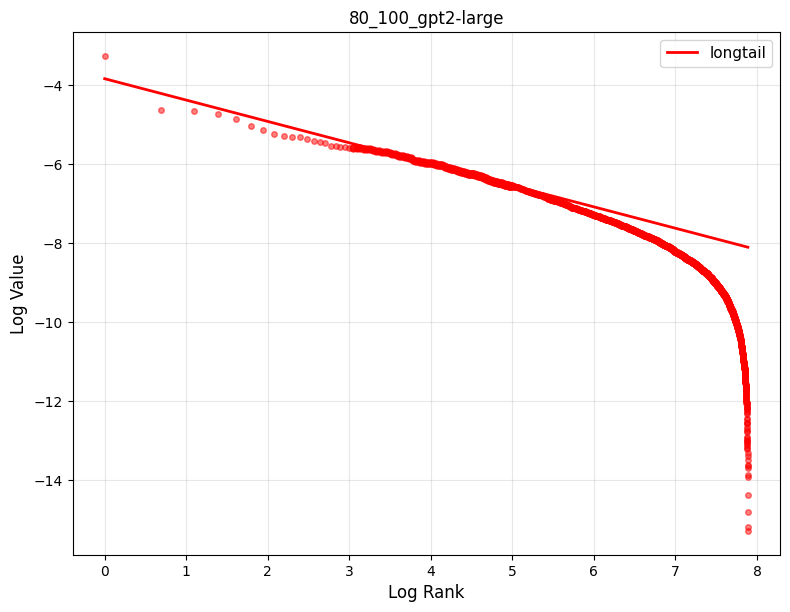

3257


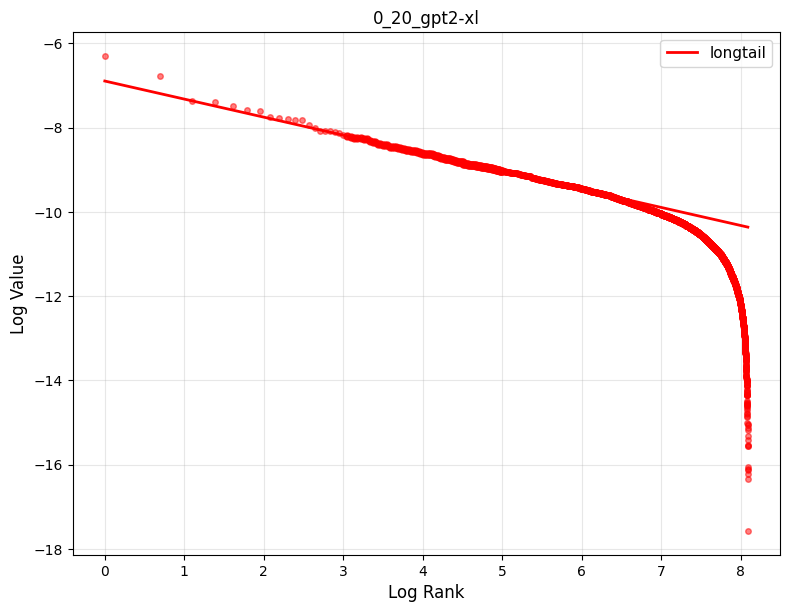

3260


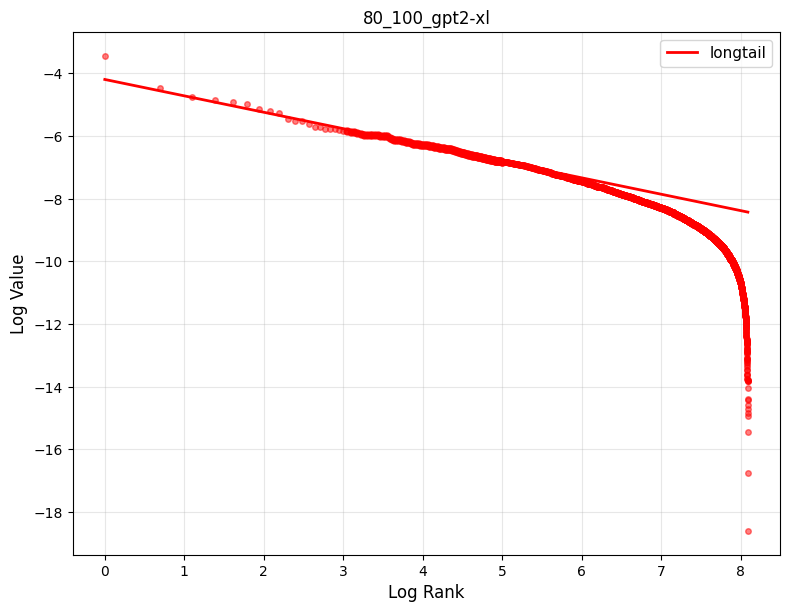

Have not got results of 20: EleutherAI/pythia-70m-deduped
Have not got results of 20: EleutherAI/pythia-160m-deduped
Have not got results of 20: EleutherAI/pythia-410m-deduped
1863


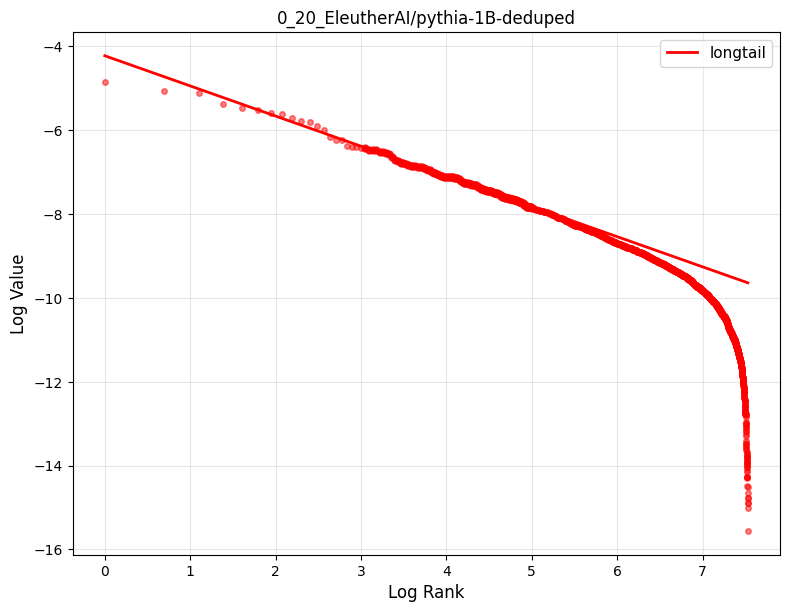

3312


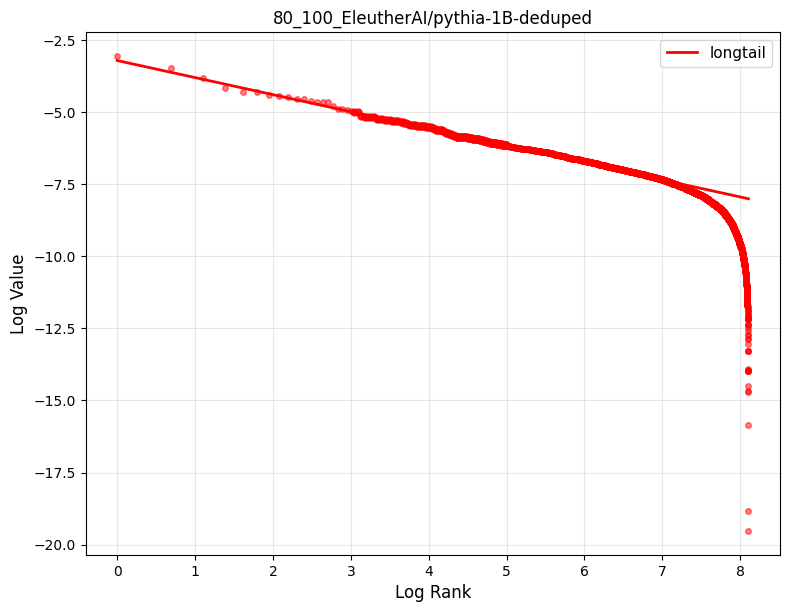

4221


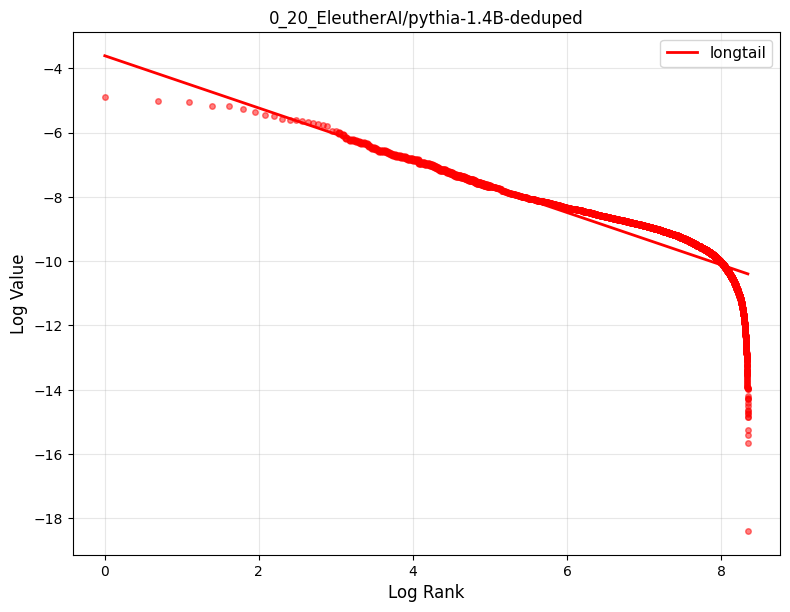

5401


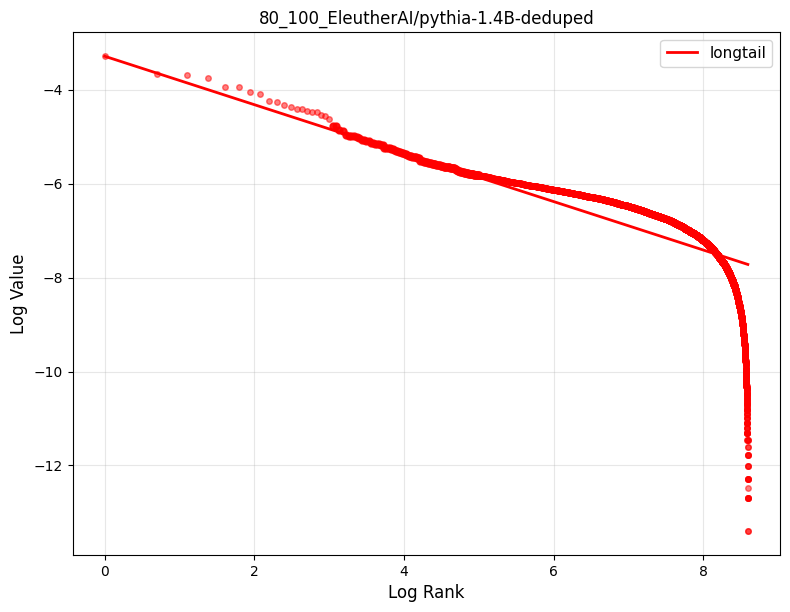

Have not got results of 20: EleutherAI/pythia-2.8B-deduped
1740


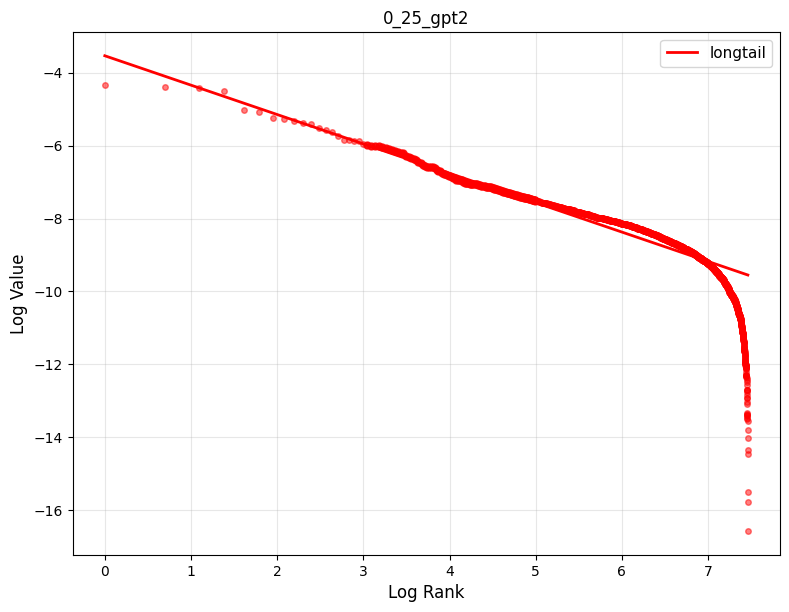

1555


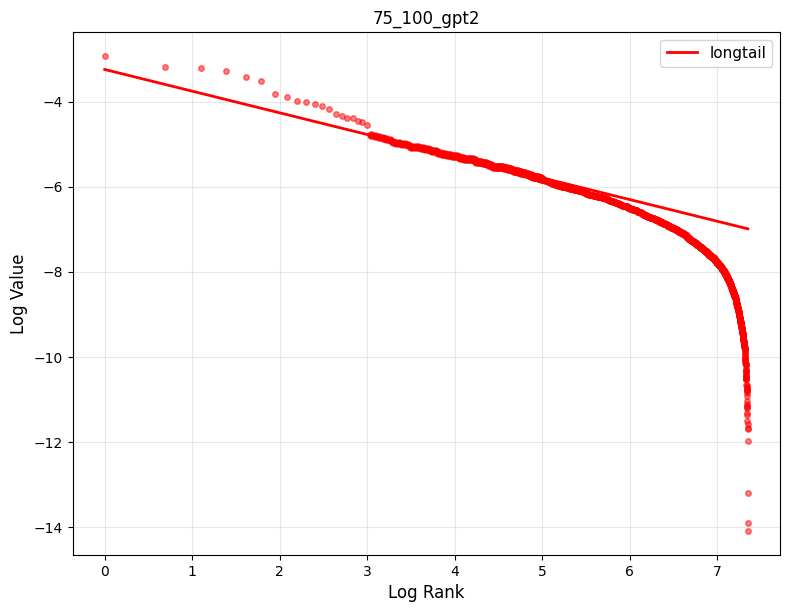

2107


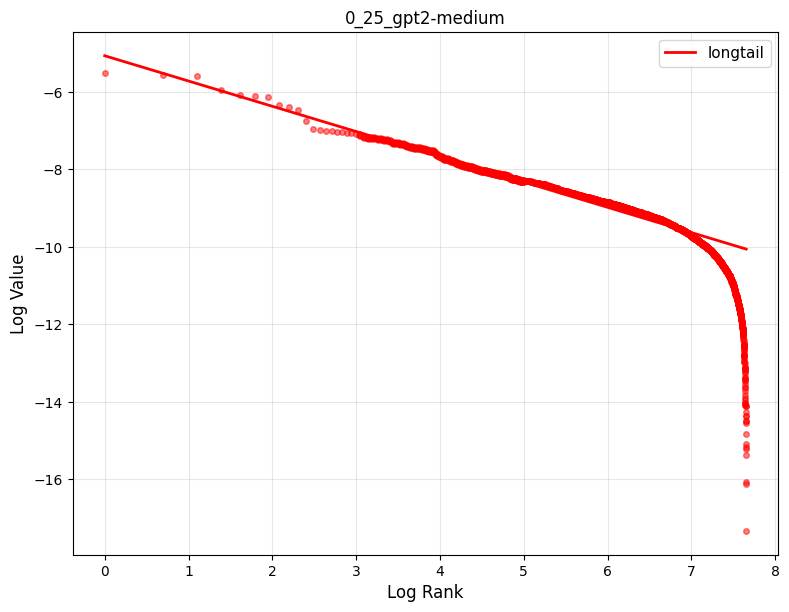

2058


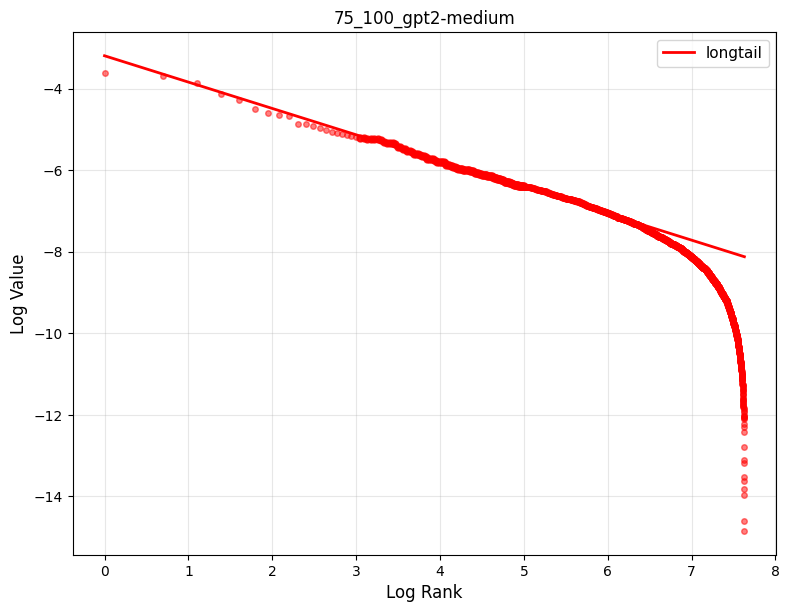

2623


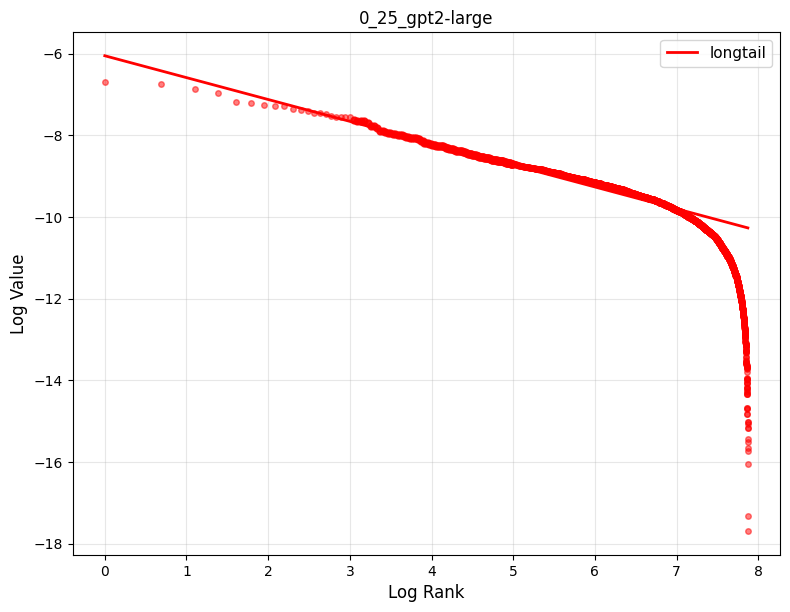

2652


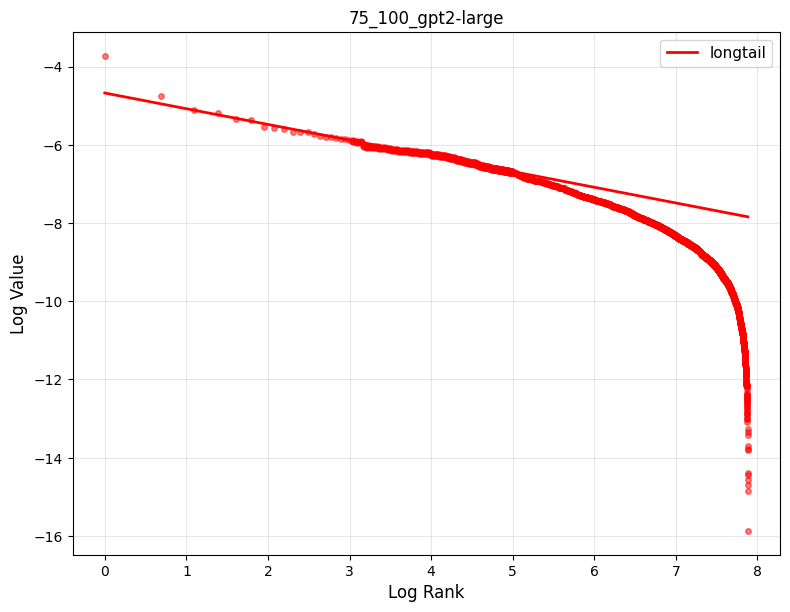

3285


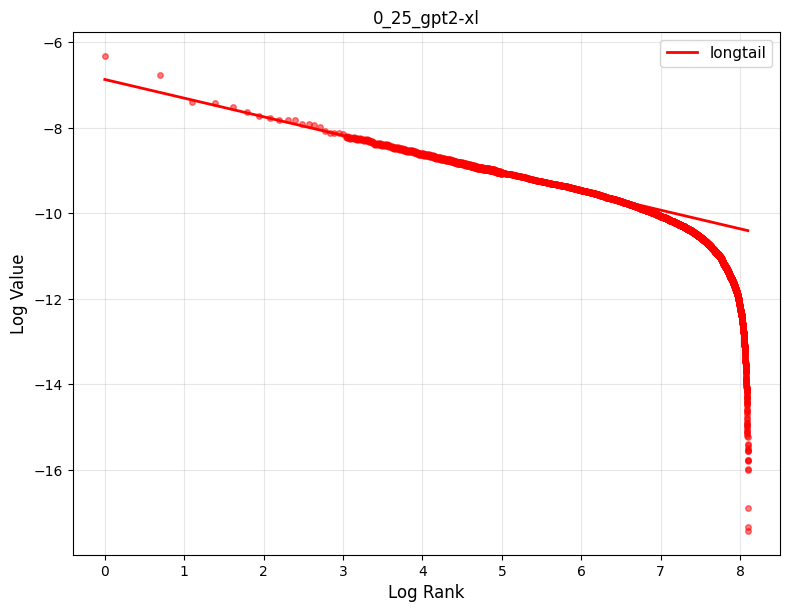

3250


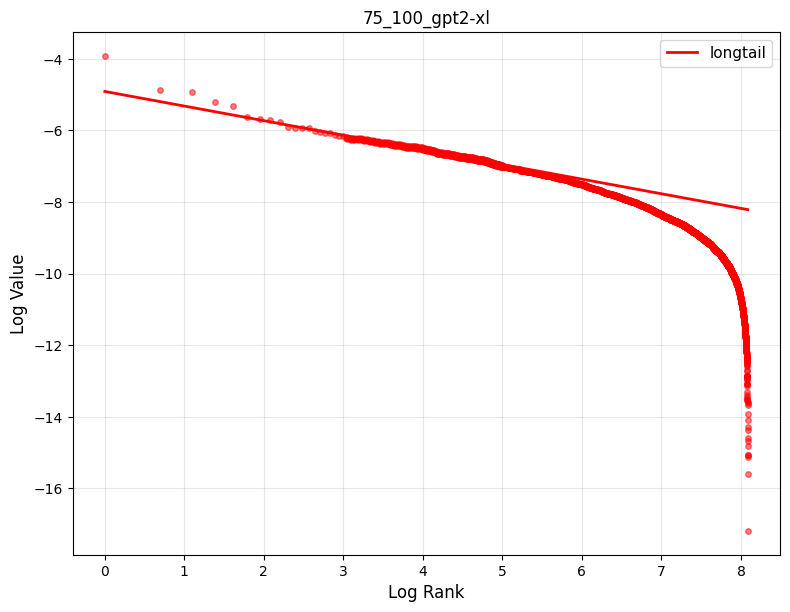

Have not got results of 25: EleutherAI/pythia-70m-deduped
Have not got results of 25: EleutherAI/pythia-160m-deduped
Have not got results of 25: EleutherAI/pythia-410m-deduped
1712


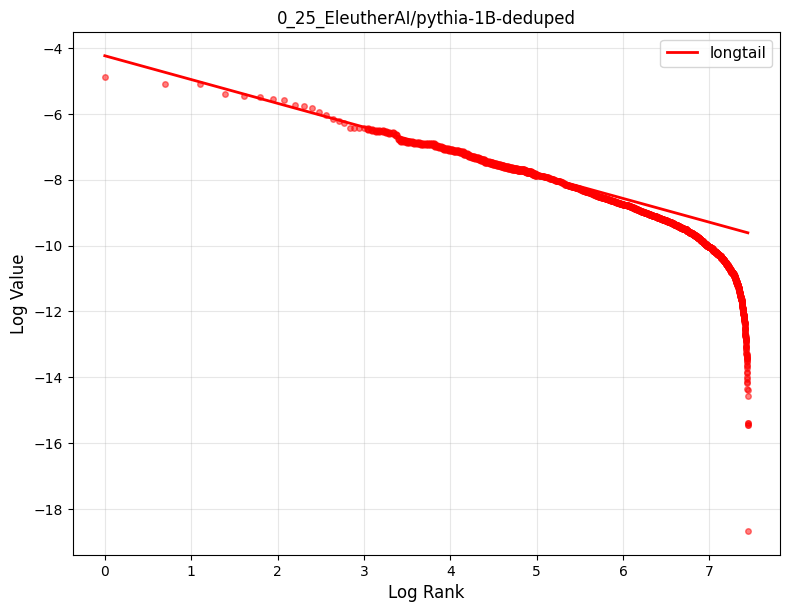

3438


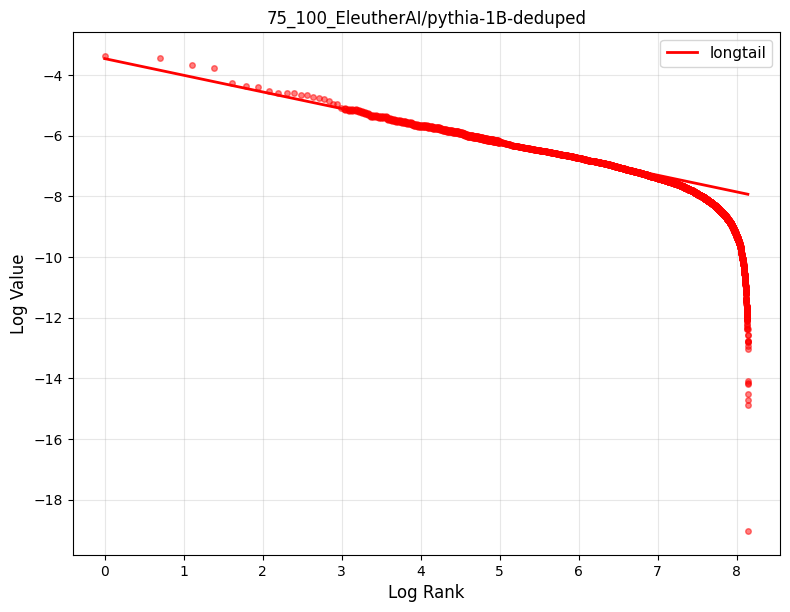

Have not got results of 25: EleutherAI/pythia-1.4B-deduped
Have not got results of 25: EleutherAI/pythia-2.8B-deduped
1736


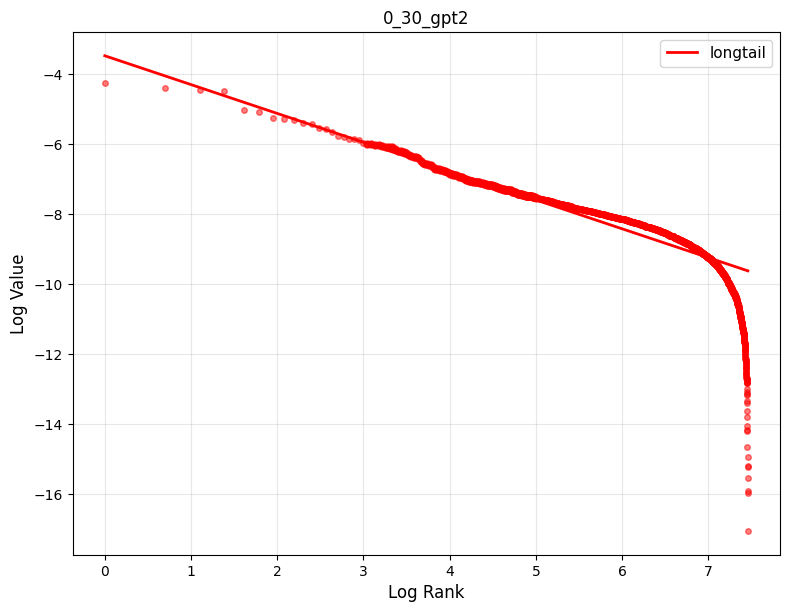

1578


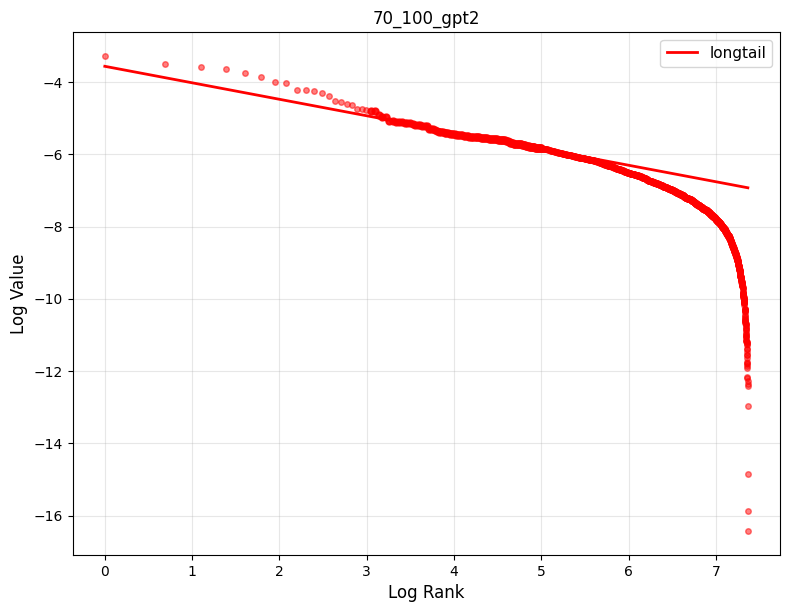

2115


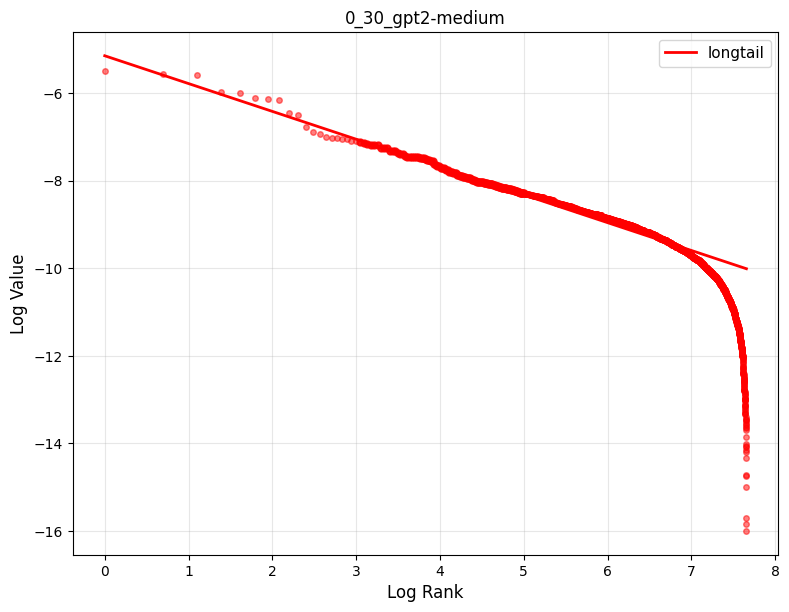

2088


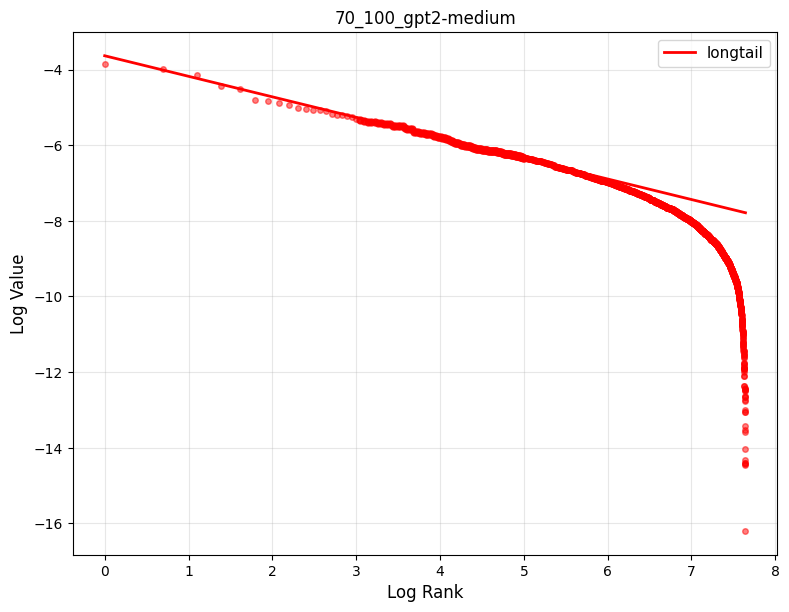

2640


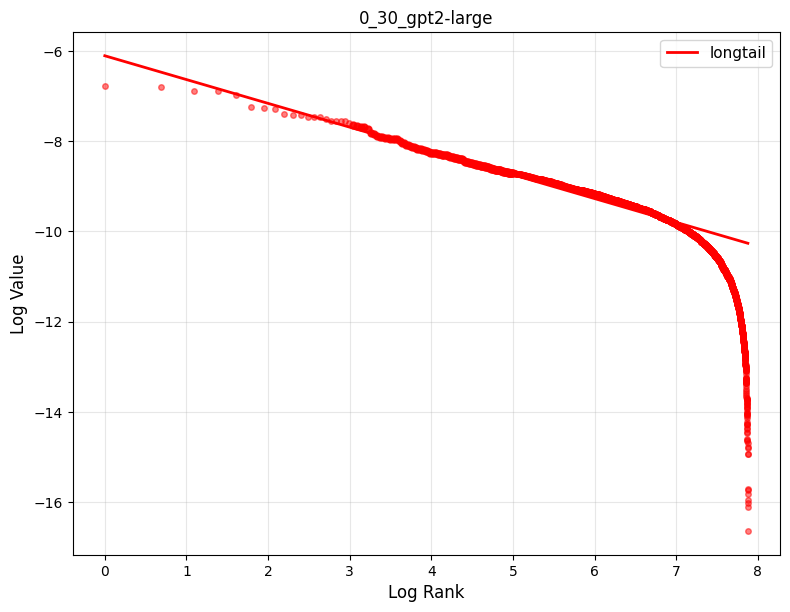

2612


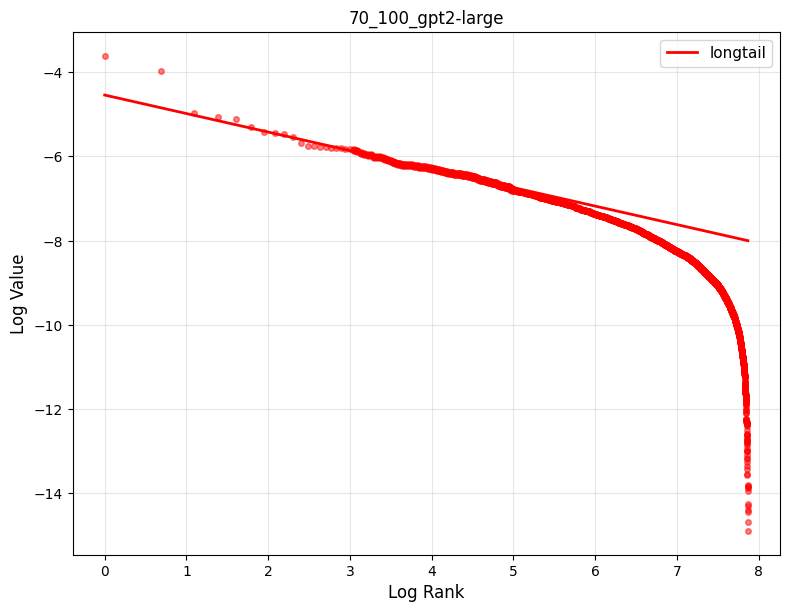

3295


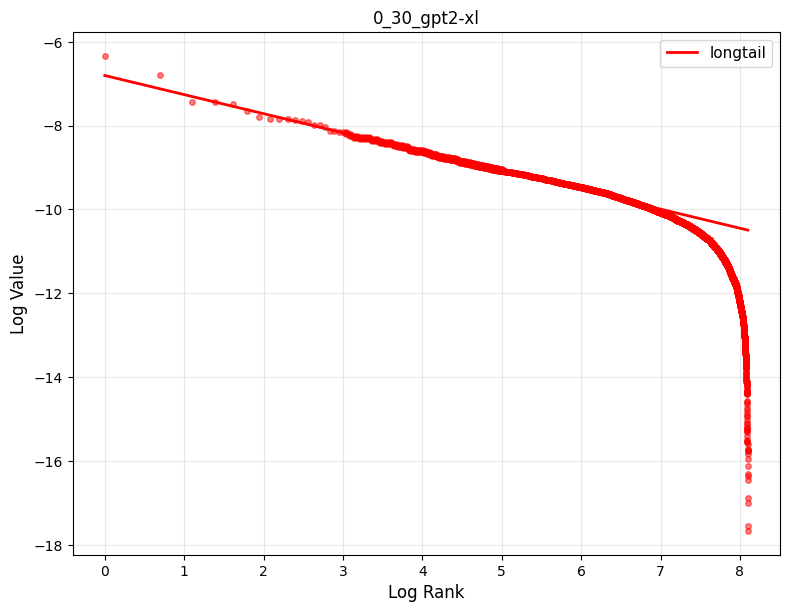

3265


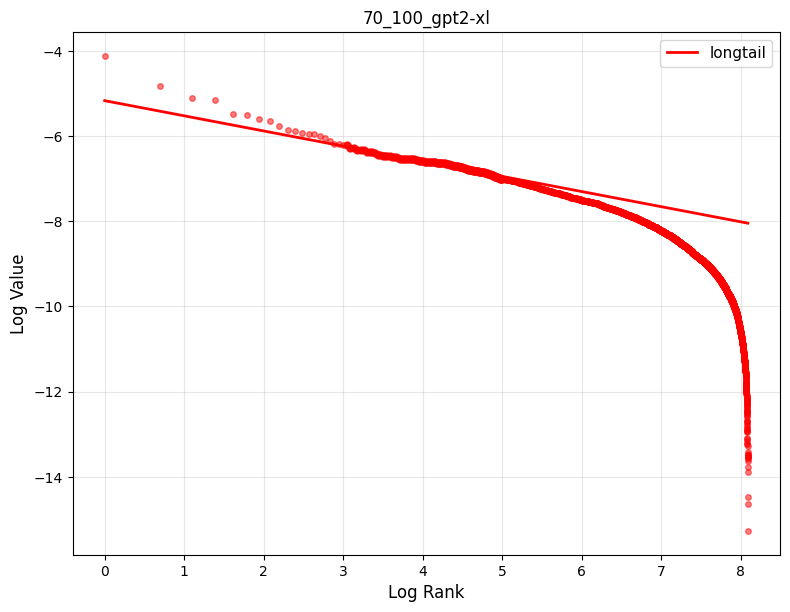

Have not got results of 30: EleutherAI/pythia-70m-deduped
Have not got results of 30: EleutherAI/pythia-160m-deduped
Have not got results of 30: EleutherAI/pythia-410m-deduped
1680


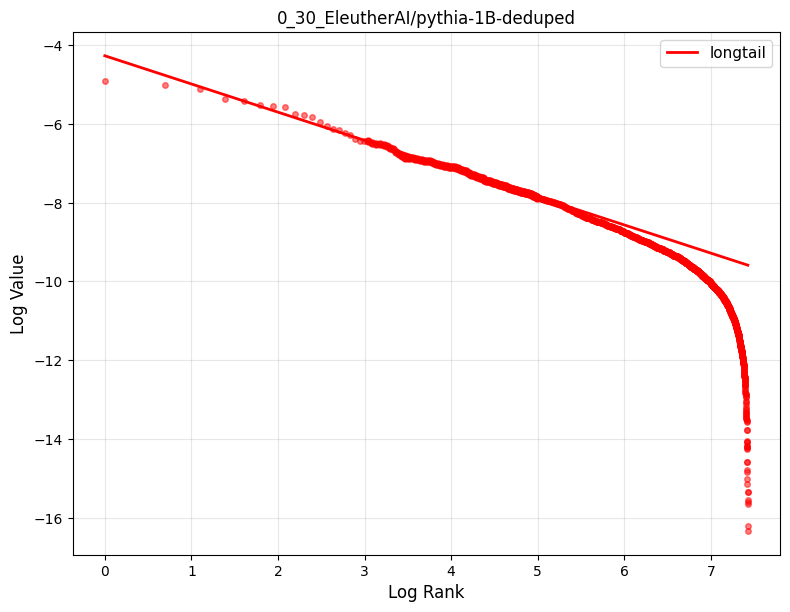

4384


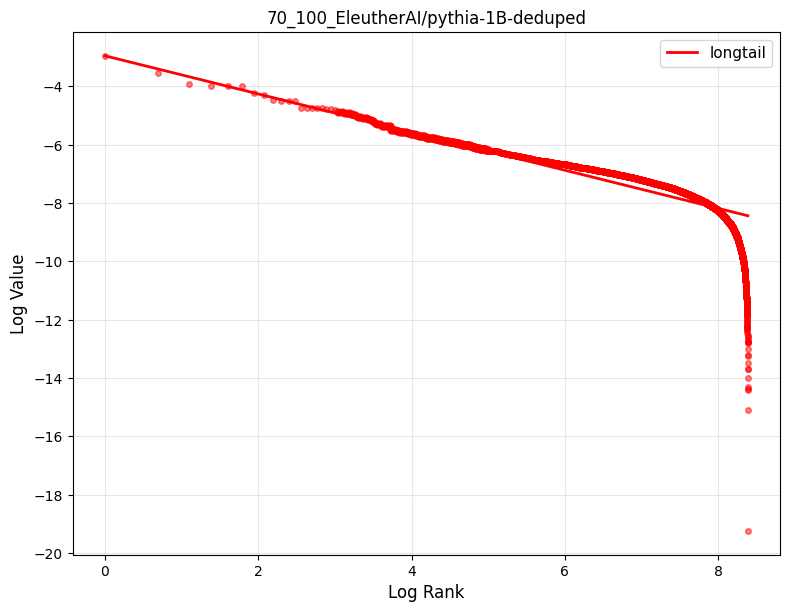

Have not got results of 30: EleutherAI/pythia-1.4B-deduped
3691


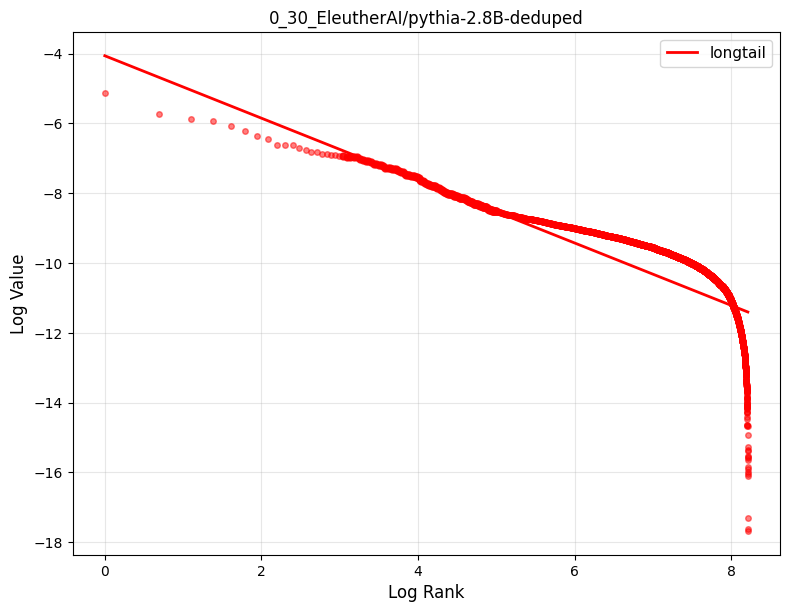

4903


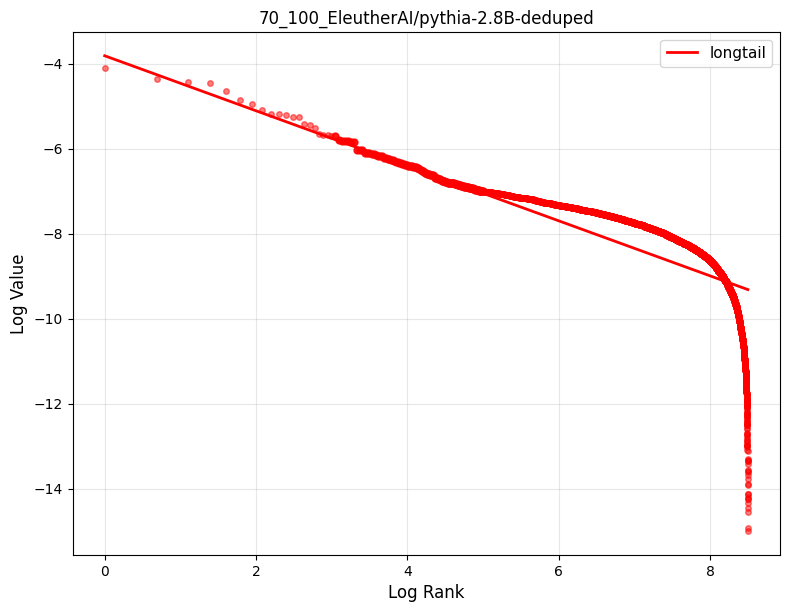

1730


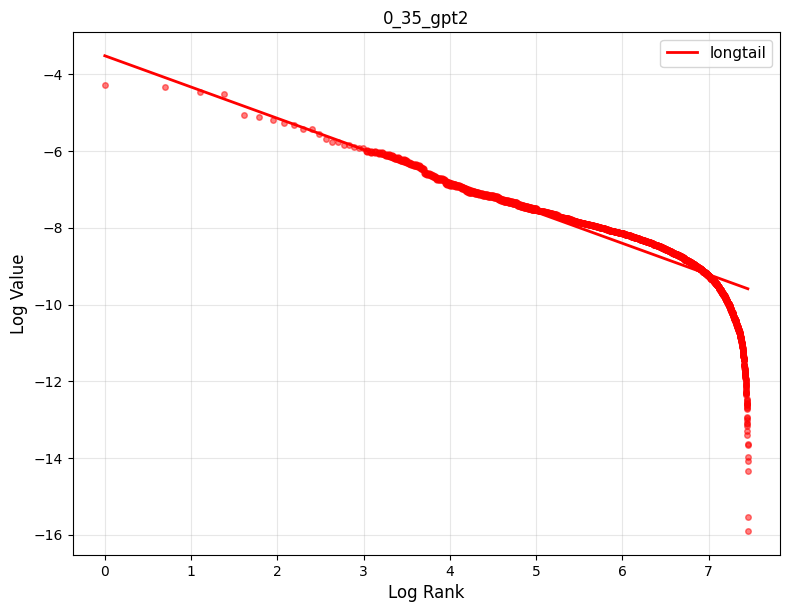

1550


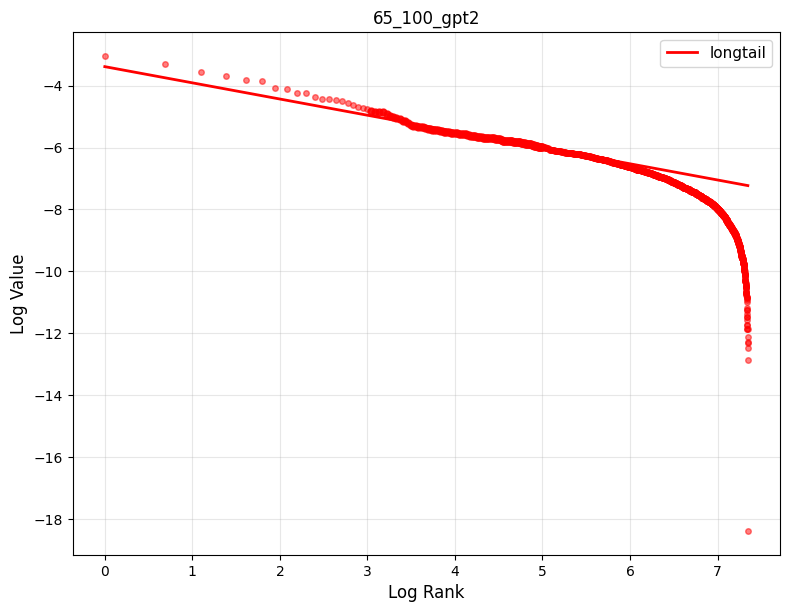

2129


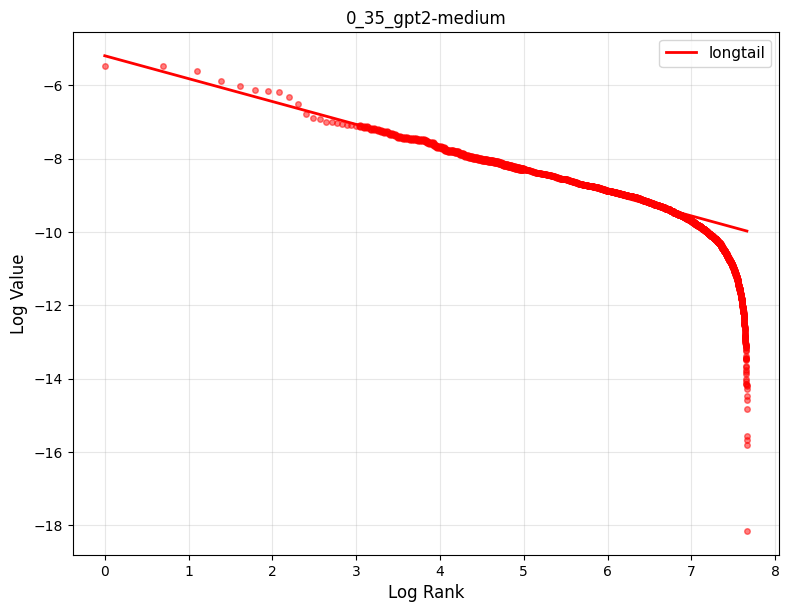

2103


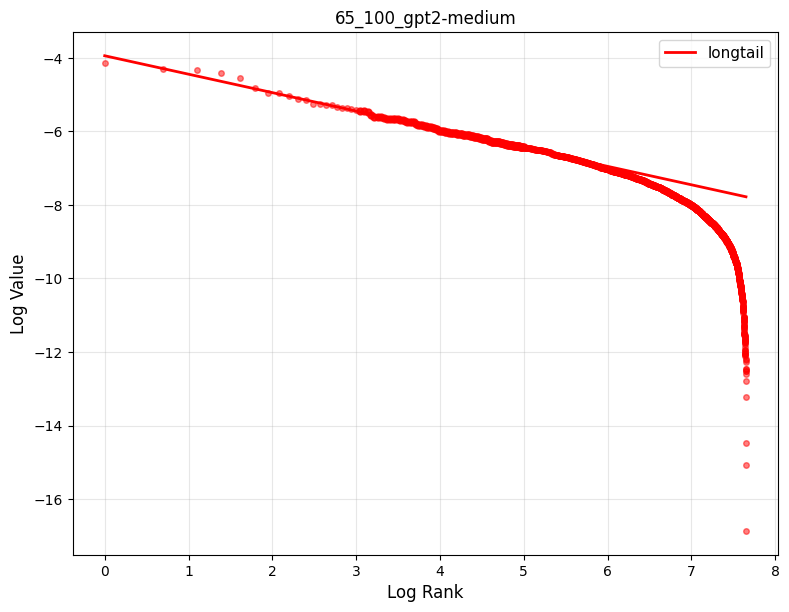

2635


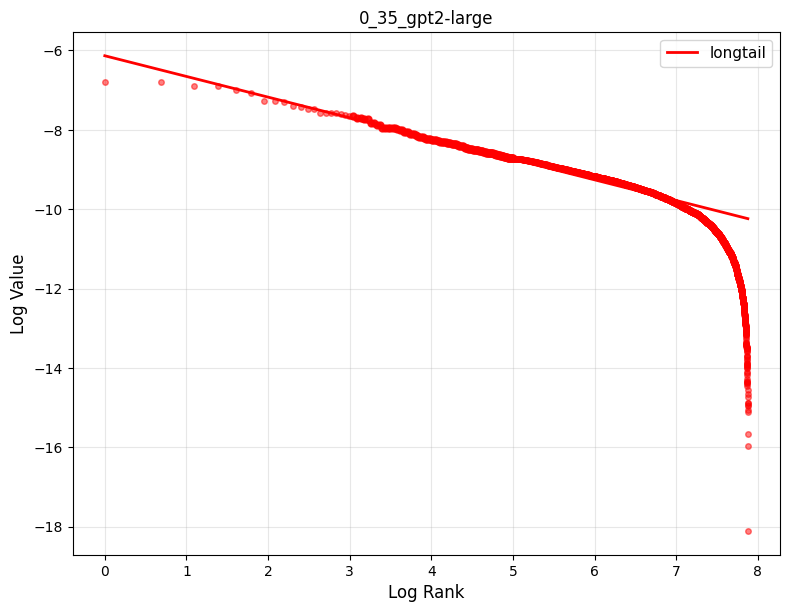

2586


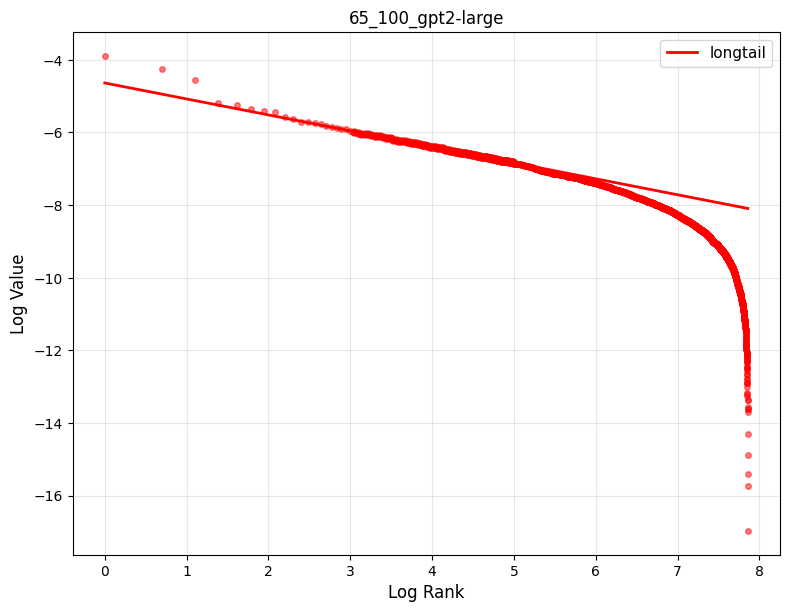

3304


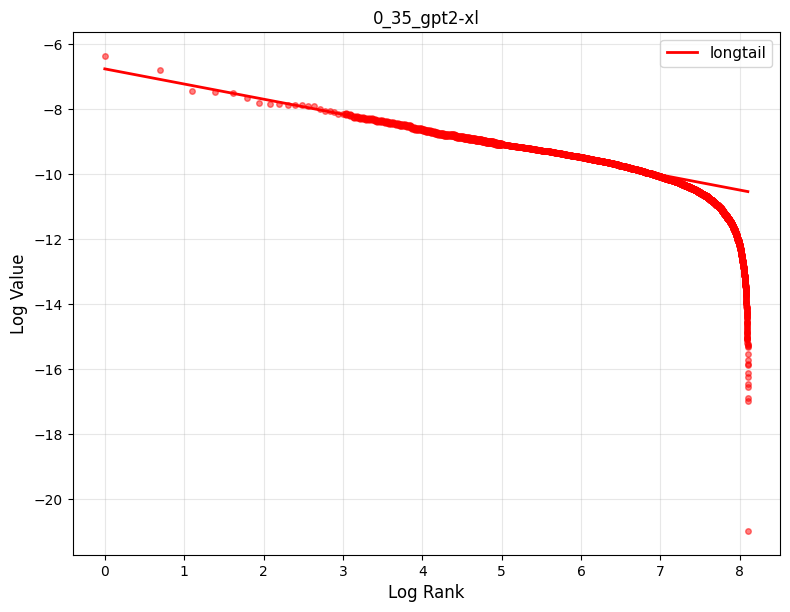

3210


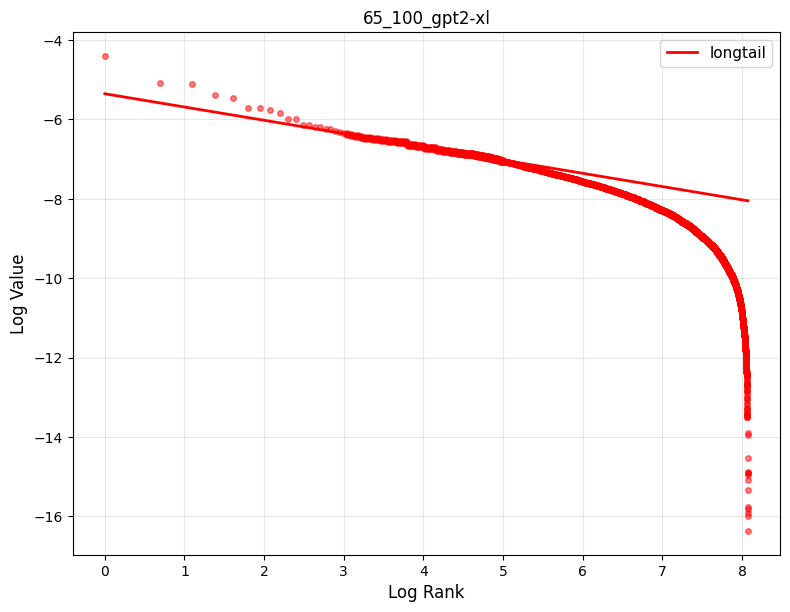

Have not got results of 35: EleutherAI/pythia-70m-deduped
Have not got results of 35: EleutherAI/pythia-160m-deduped
Have not got results of 35: EleutherAI/pythia-410m-deduped
1853


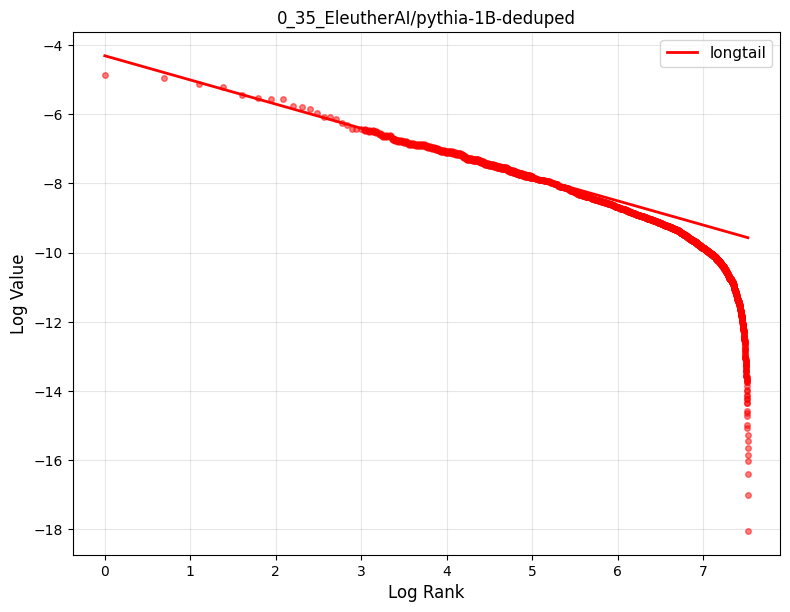

4303


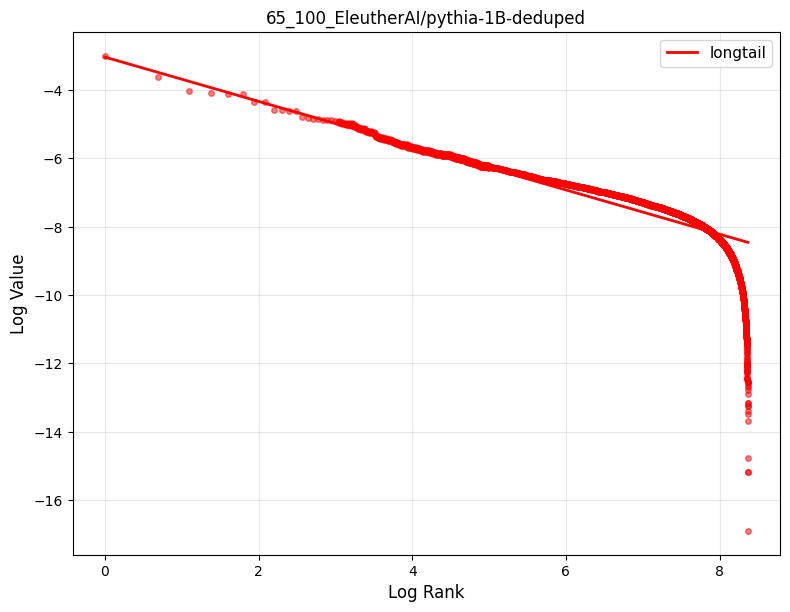

Have not got results of 35: EleutherAI/pythia-1.4B-deduped
Have not got results of 35: EleutherAI/pythia-2.8B-deduped
1730


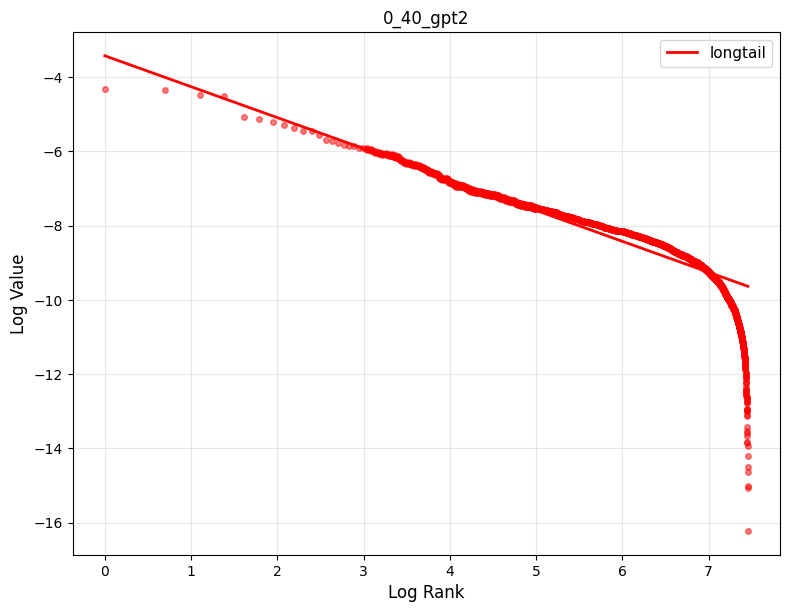

1505


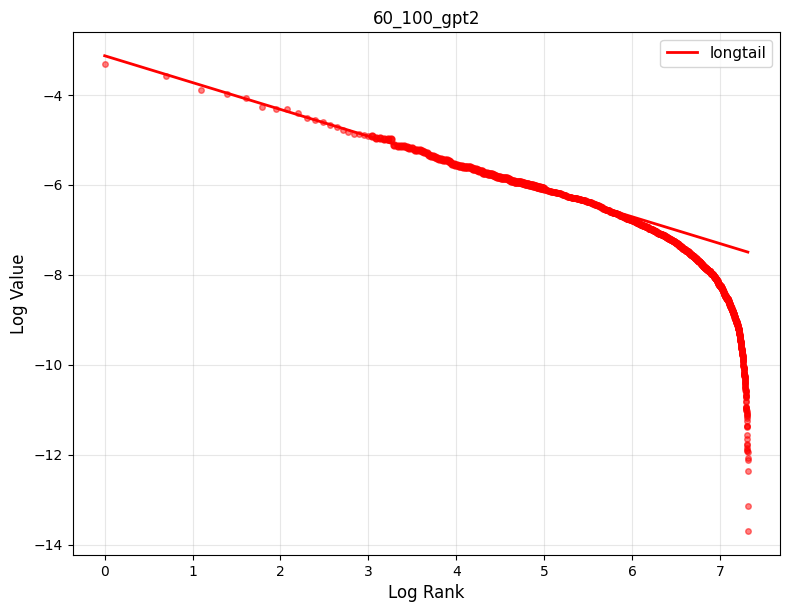

2128


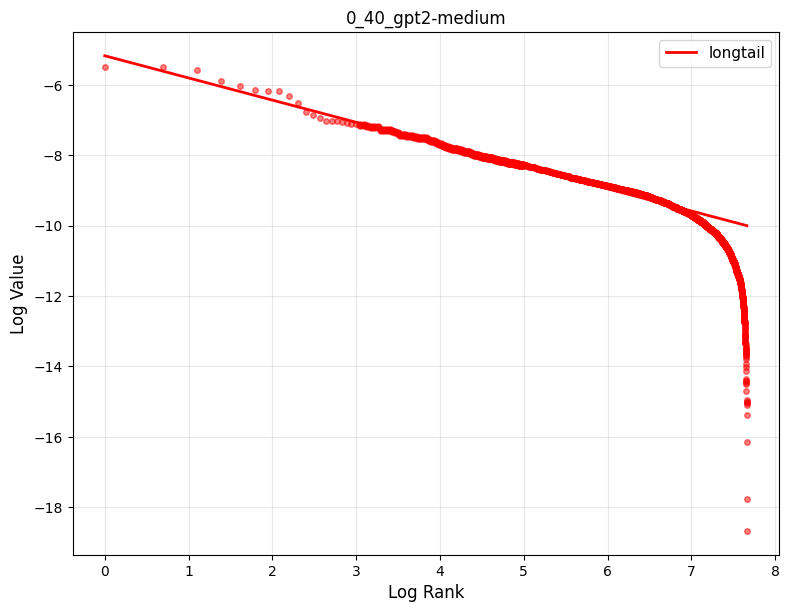

2107


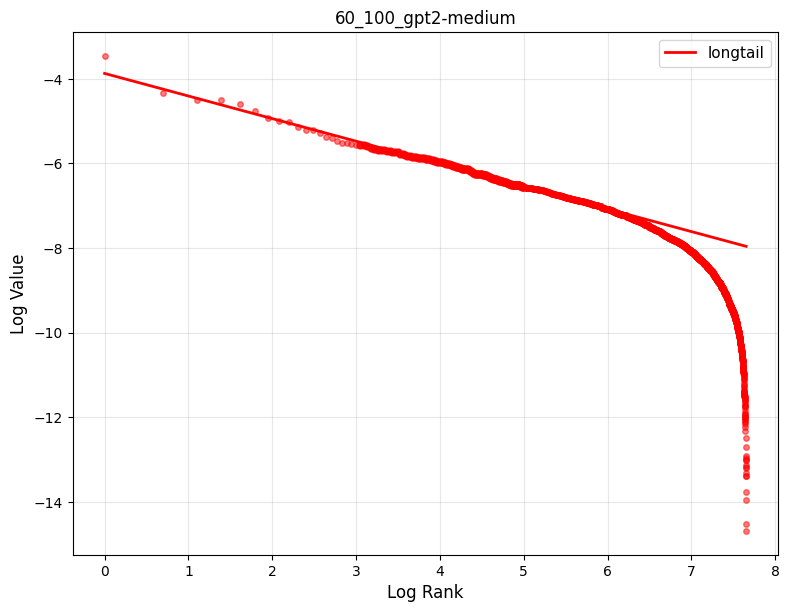

2637


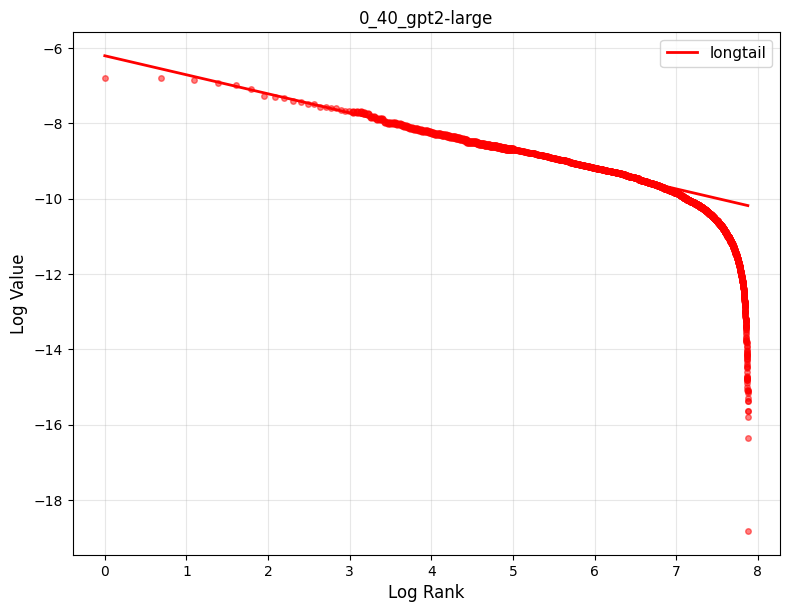

2557


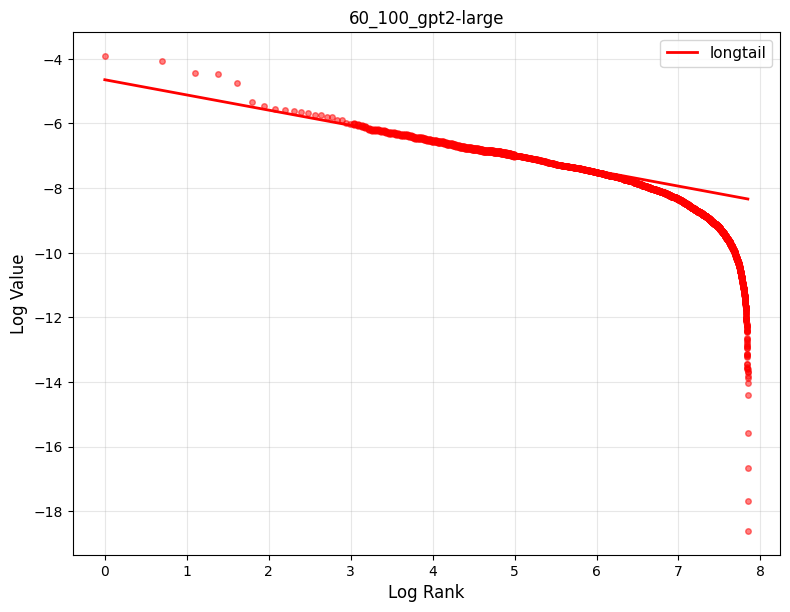

3292


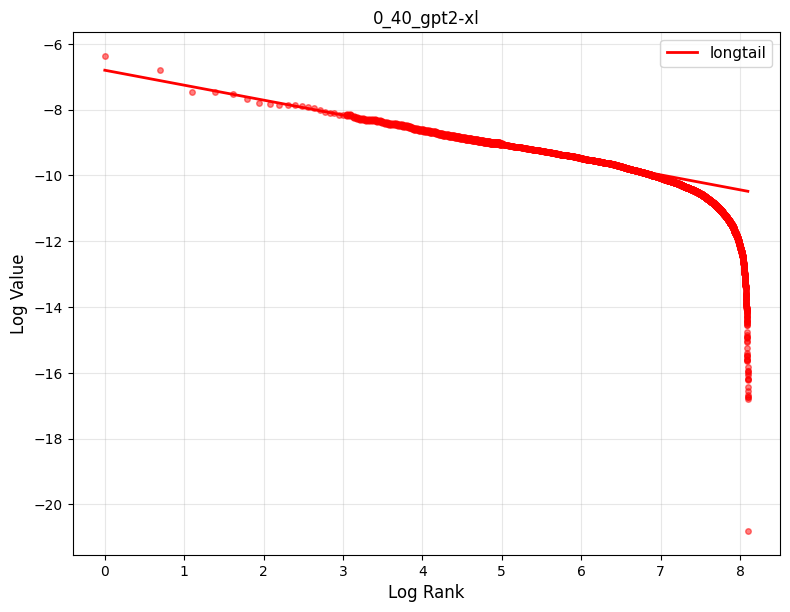

3159


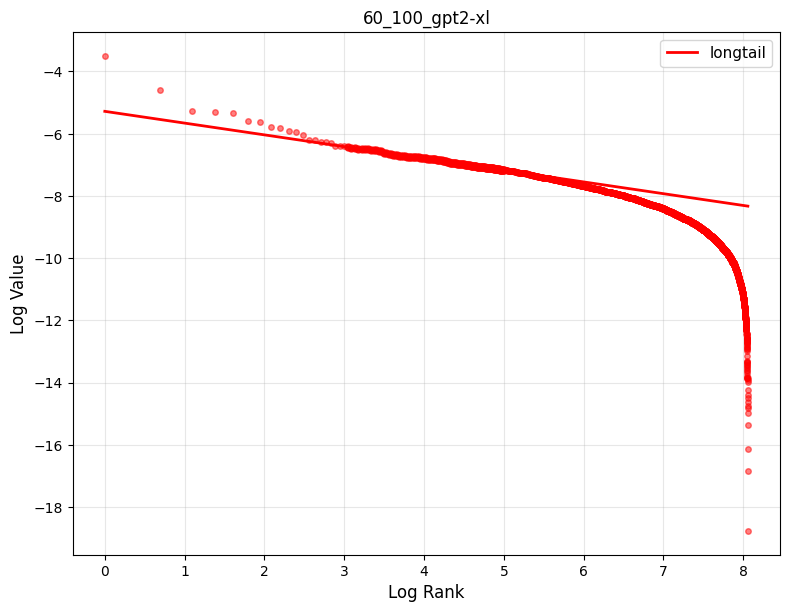

Have not got results of 40: EleutherAI/pythia-70m-deduped
Have not got results of 40: EleutherAI/pythia-160m-deduped
Have not got results of 40: EleutherAI/pythia-410m-deduped
1875


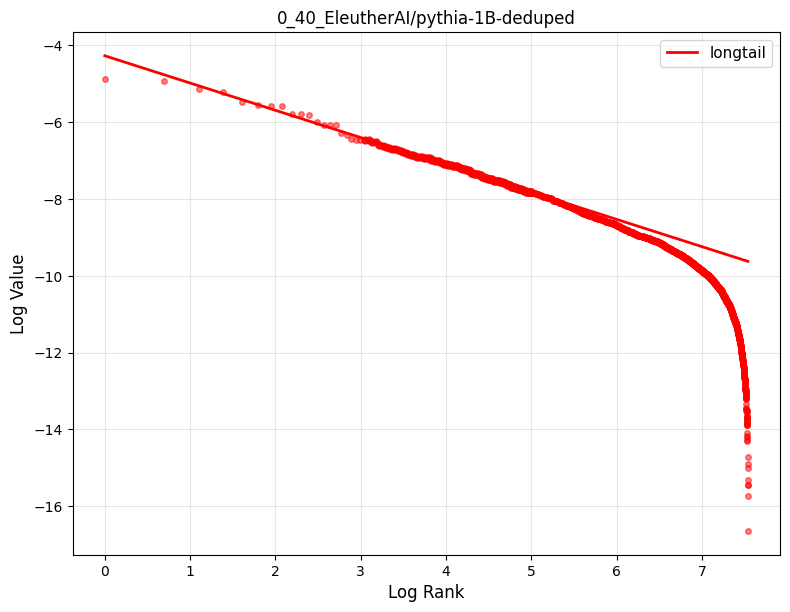

3677


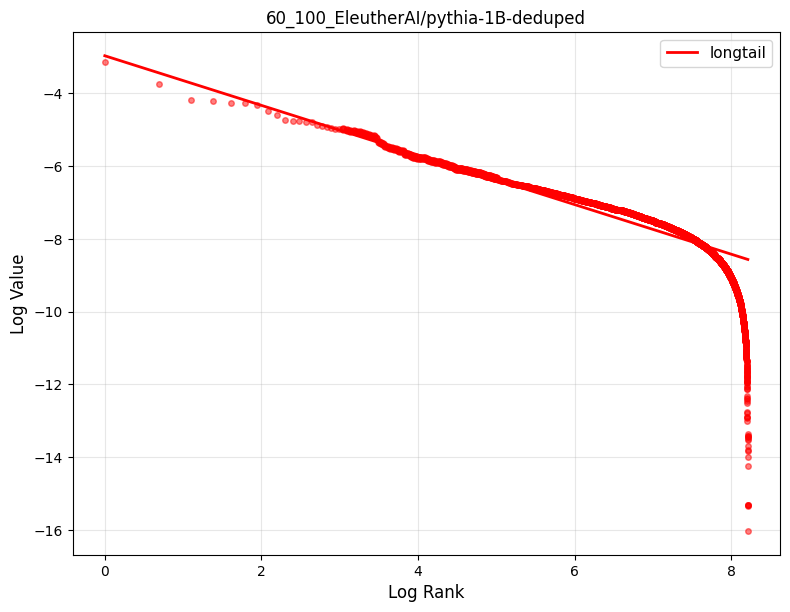

Have not got results of 40: EleutherAI/pythia-1.4B-deduped
Have not got results of 40: EleutherAI/pythia-2.8B-deduped
1735


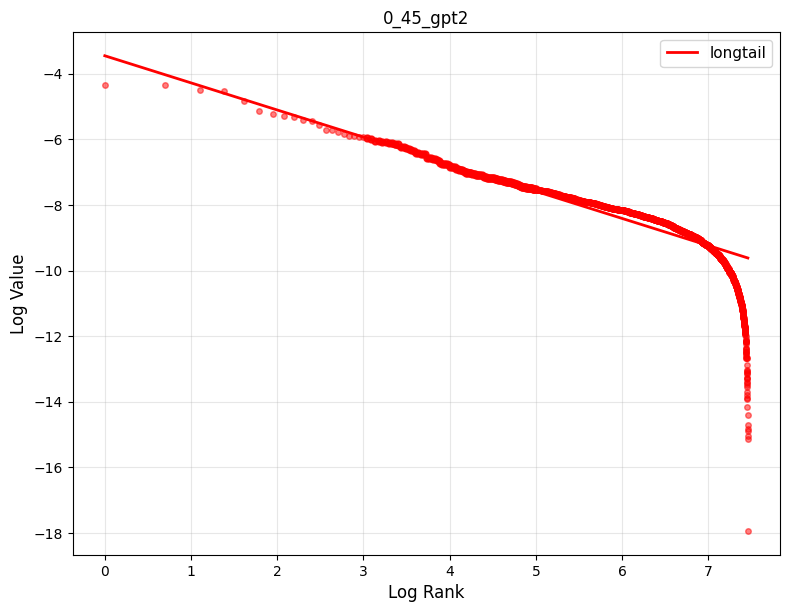

1519


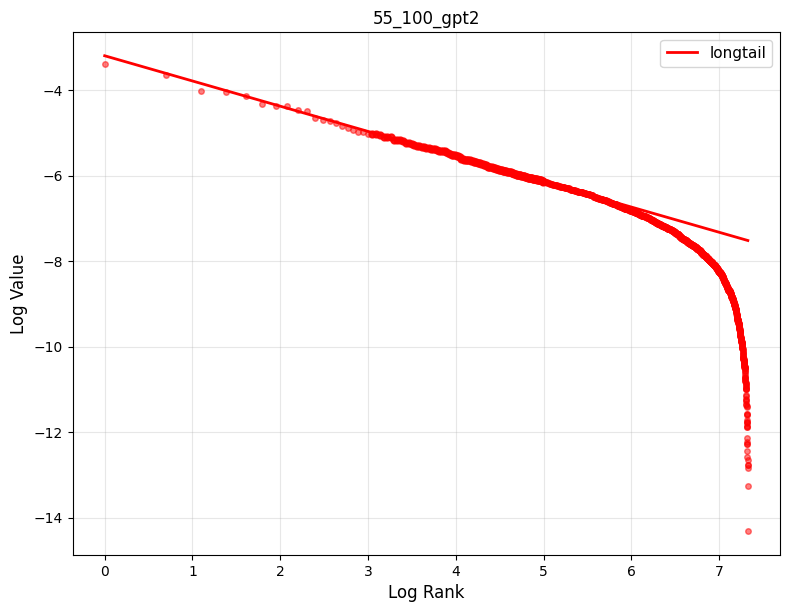

2127


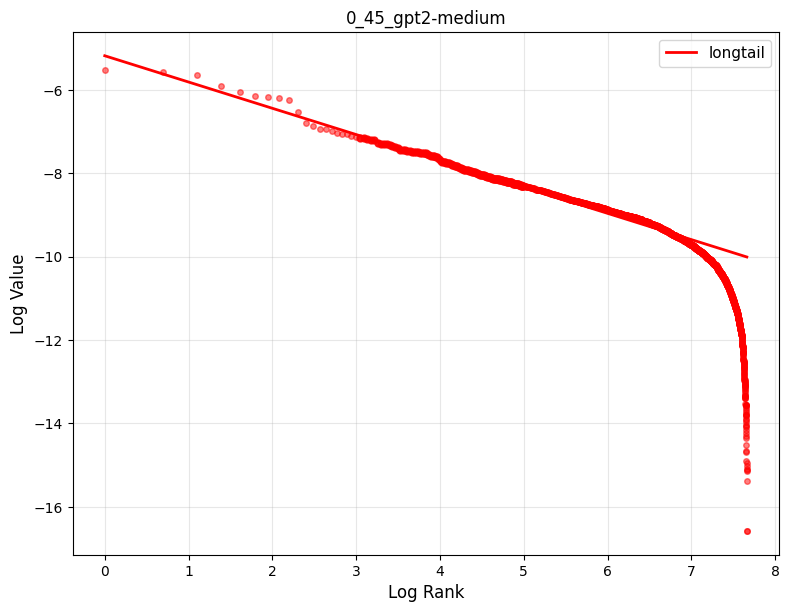

2115


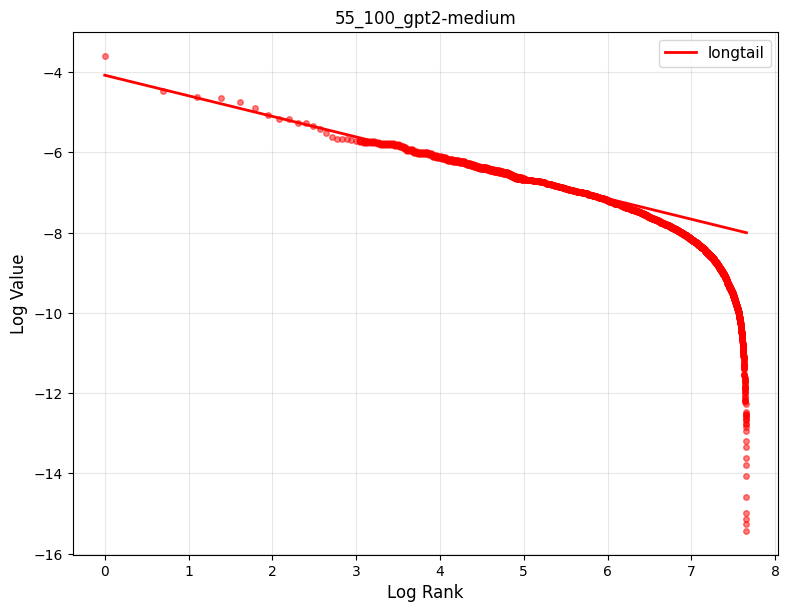

2614


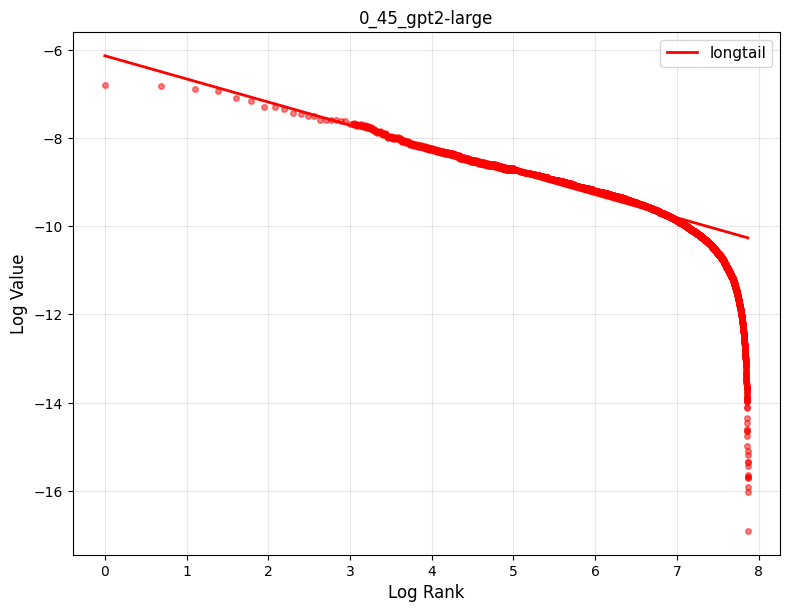

2585


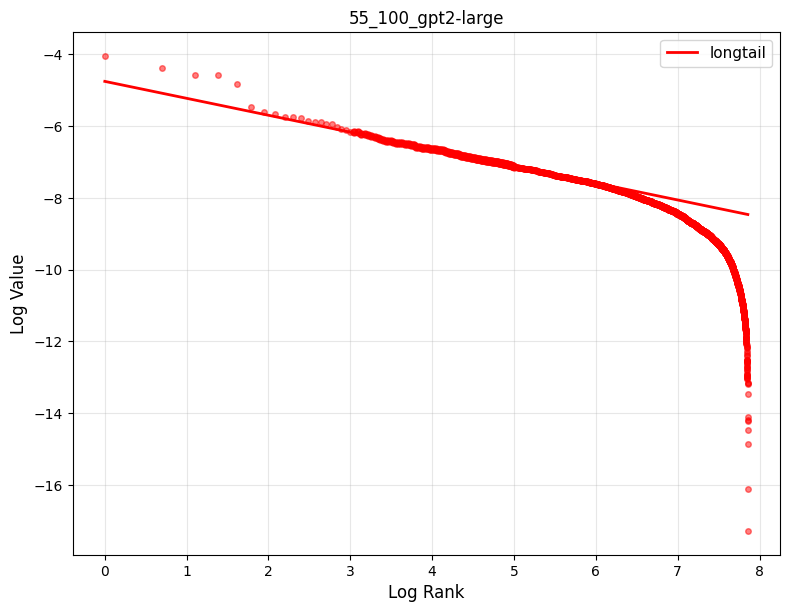

3267


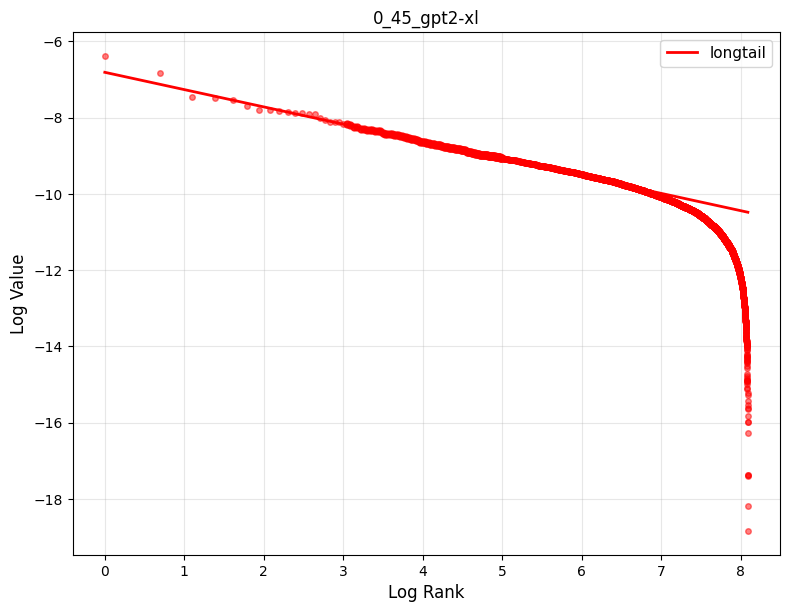

3169


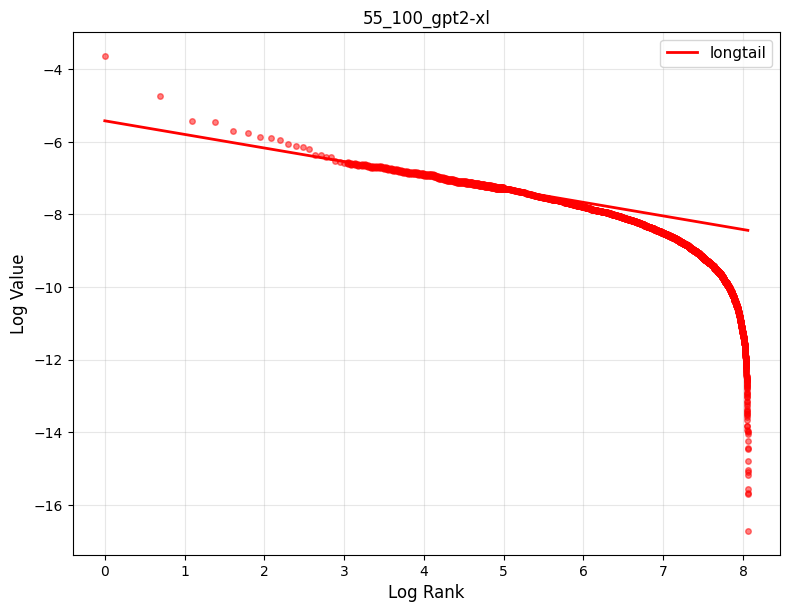

Have not got results of 45: EleutherAI/pythia-70m-deduped
Have not got results of 45: EleutherAI/pythia-160m-deduped
Have not got results of 45: EleutherAI/pythia-410m-deduped
1854


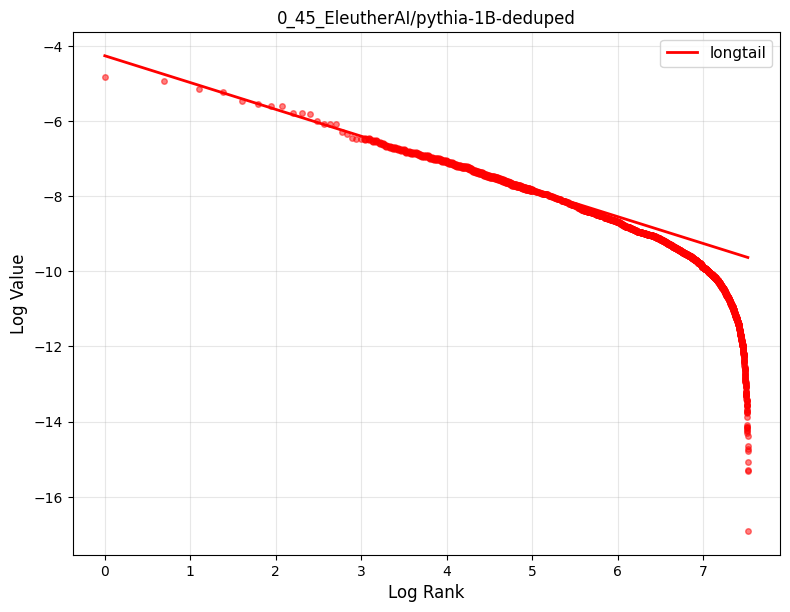

3531


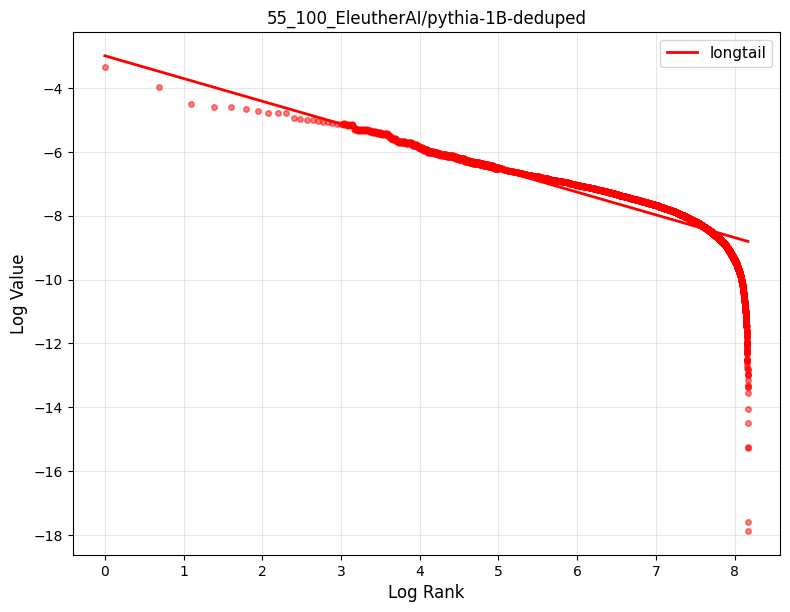

Have not got results of 45: EleutherAI/pythia-1.4B-deduped
Have not got results of 45: EleutherAI/pythia-2.8B-deduped
1735


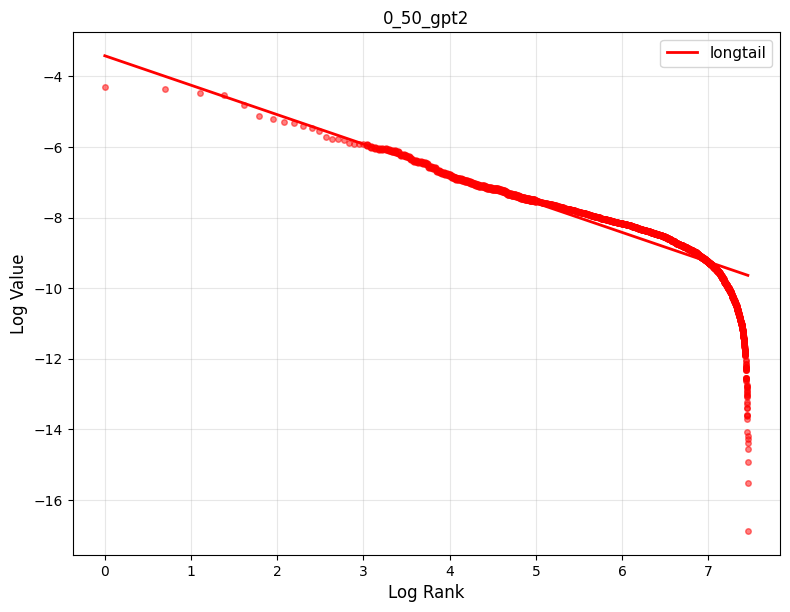

1510


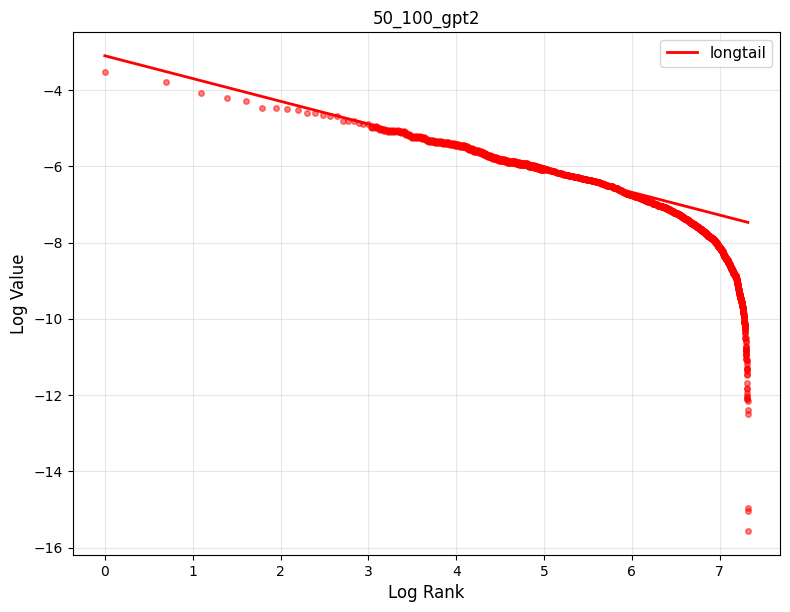

2117


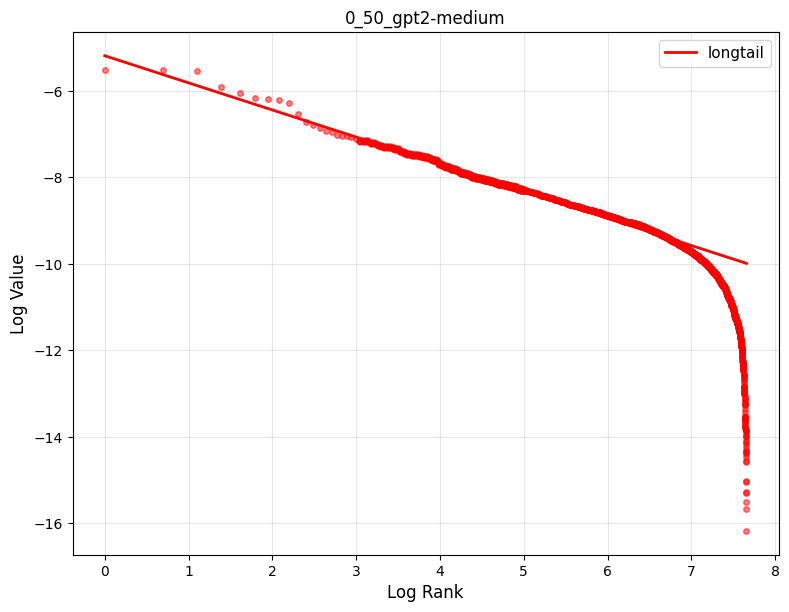

2117


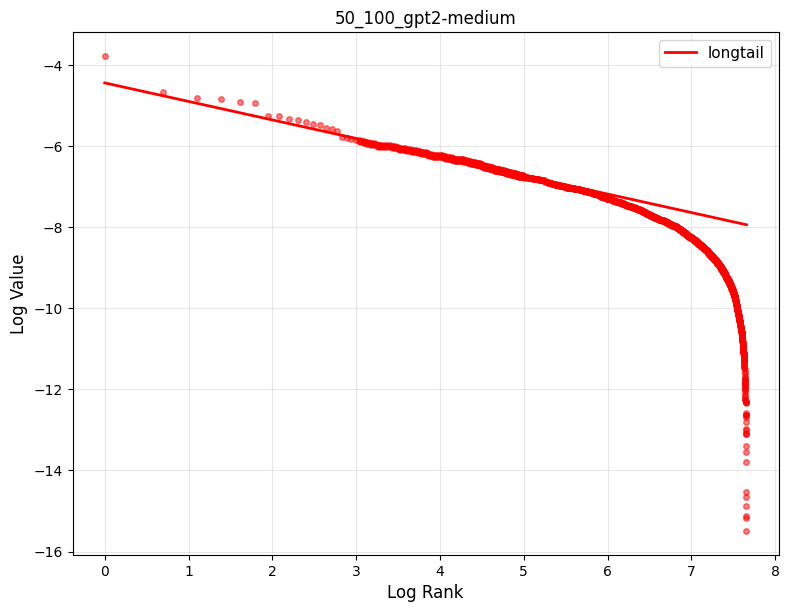

2613


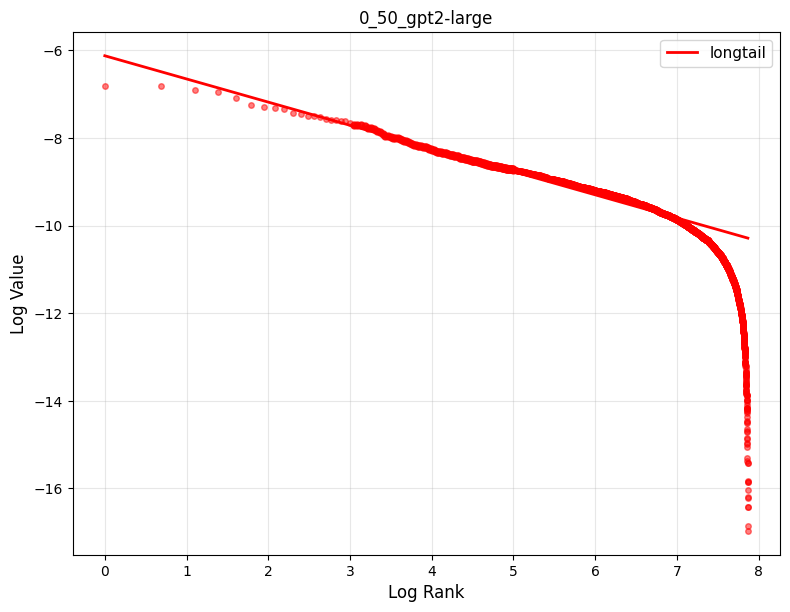

2618


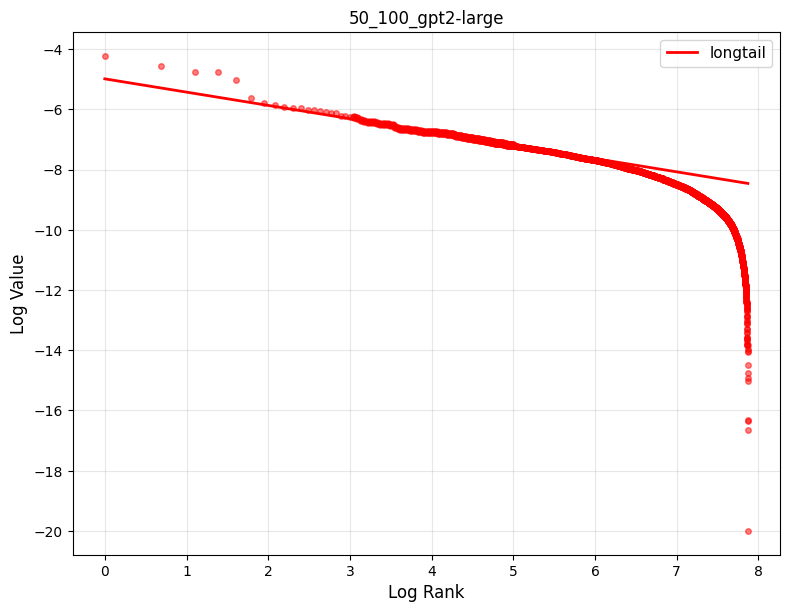

3262


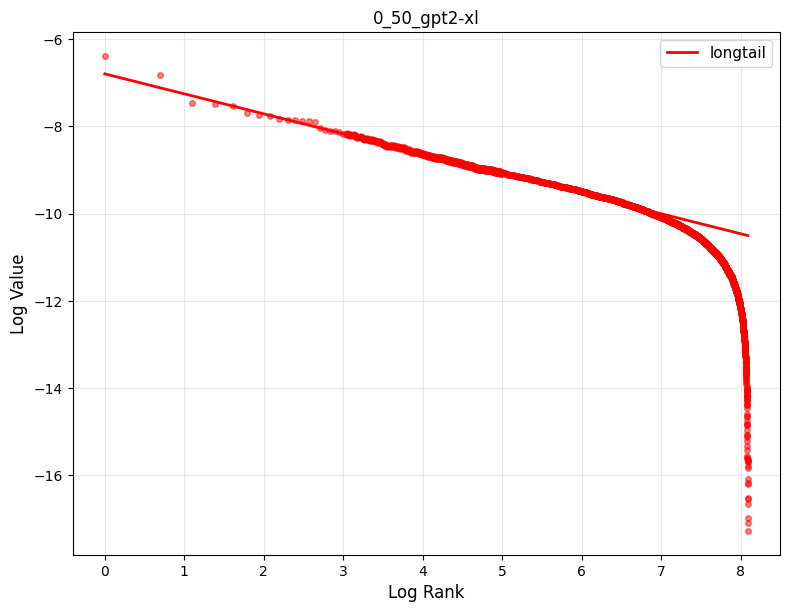

3221


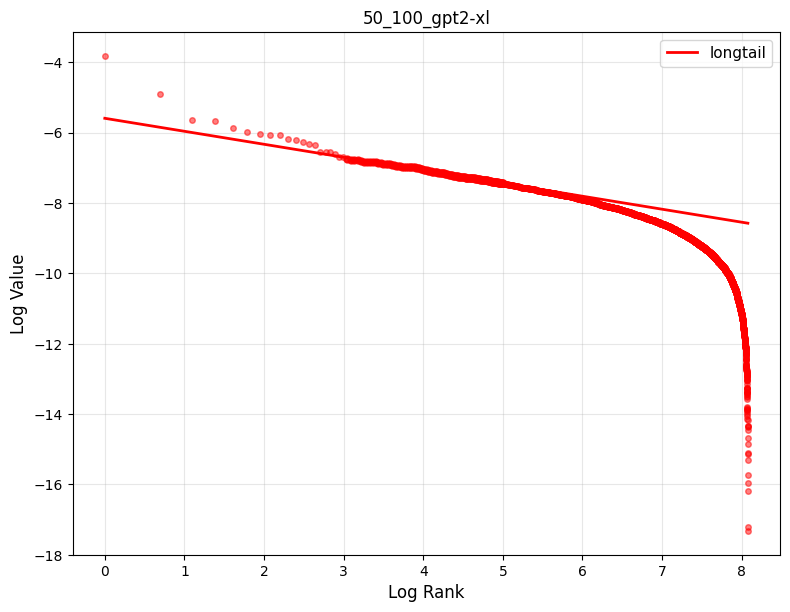

Have not got results of 50: EleutherAI/pythia-70m-deduped
Have not got results of 50: EleutherAI/pythia-160m-deduped
Have not got results of 50: EleutherAI/pythia-410m-deduped
1919


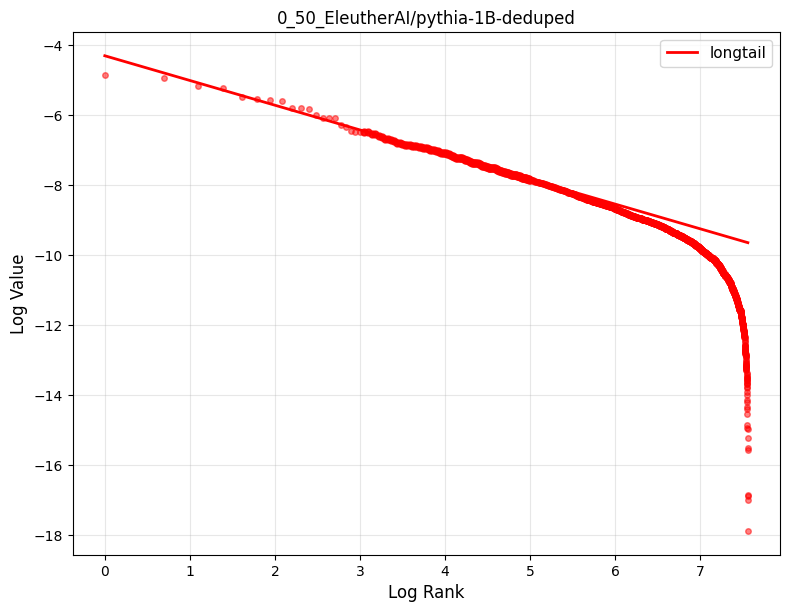

3830


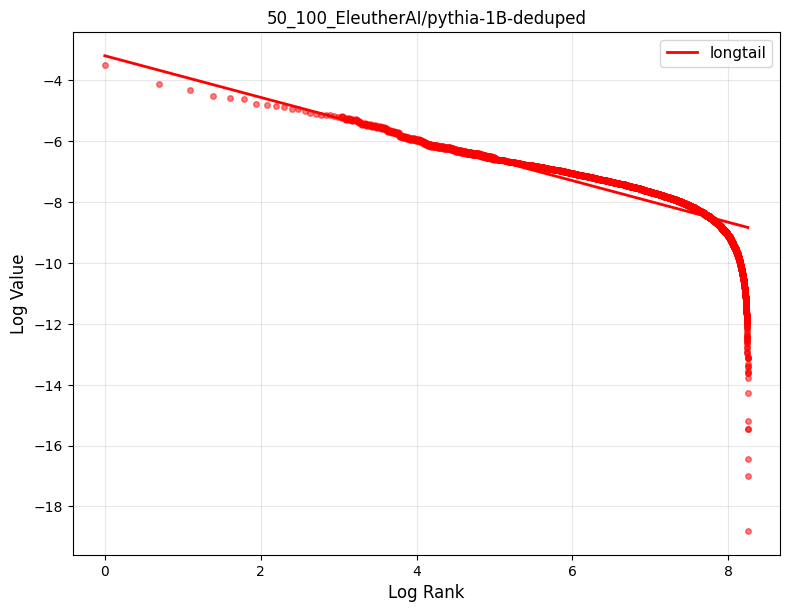

Have not got results of 50: EleutherAI/pythia-1.4B-deduped
Have not got results of 50: EleutherAI/pythia-2.8B-deduped


In [32]:
interval_lst = [5,10,15,20,25,30,35,40,45,50]

model_lst = [
    "gpt2",
    "gpt2-medium",
    "gpt2-large",
    "gpt2-xl",
    "EleutherAI/pythia-70m-deduped",
    "EleutherAI/pythia-160m-deduped",
    "EleutherAI/pythia-410m-deduped",
    "EleutherAI/pythia-1B-deduped",
    "EleutherAI/pythia-1.4B-deduped",
    "EleutherAI/pythia-2.8B-deduped",
]

for interval in interval_lst:
    for model in model_lst:
        try:
            plot_all(interval,model,linear_region=(3, 5))
        except:
            print(f"Have not got results of {interval}: {model}")



3227


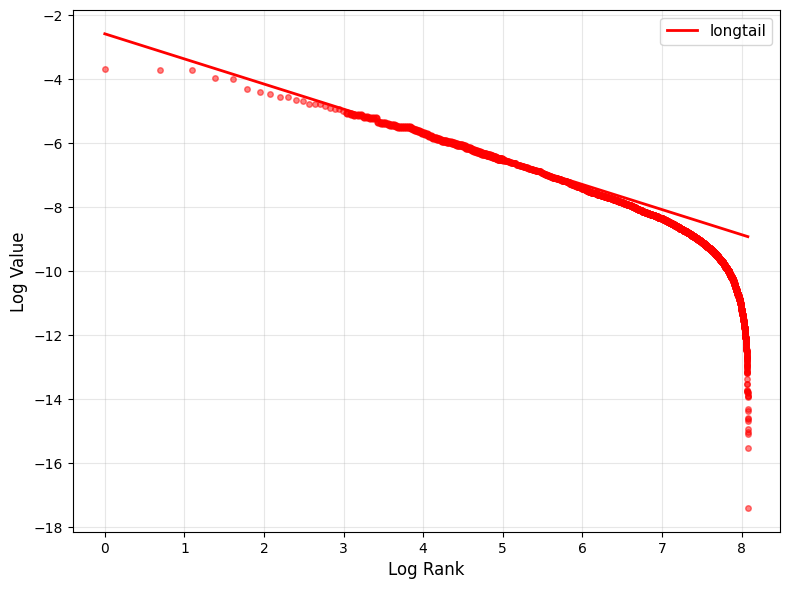

In [ ]:
min_pct = 90
max_pct = 100
model = "gpt2-xl"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


3241


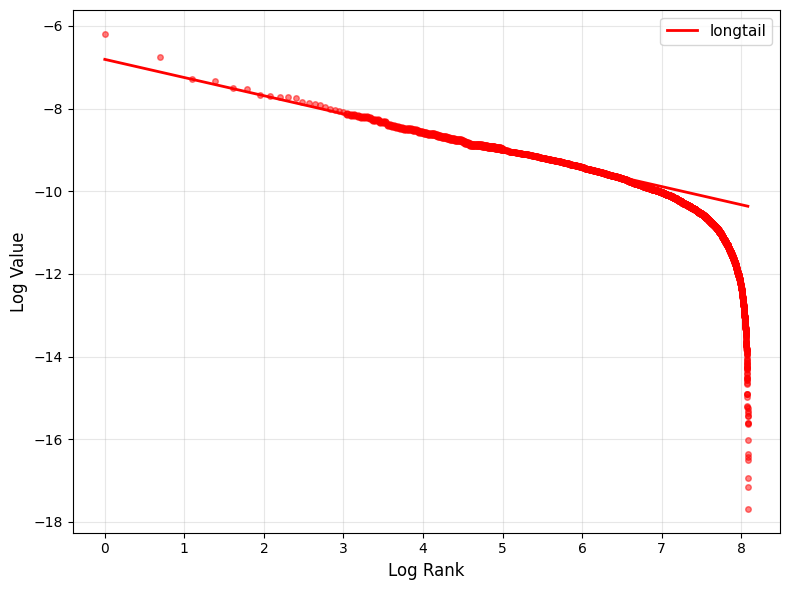

In [6]:
min_pct = 0
max_pct = 10
model = "gpt2-xl"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


3247


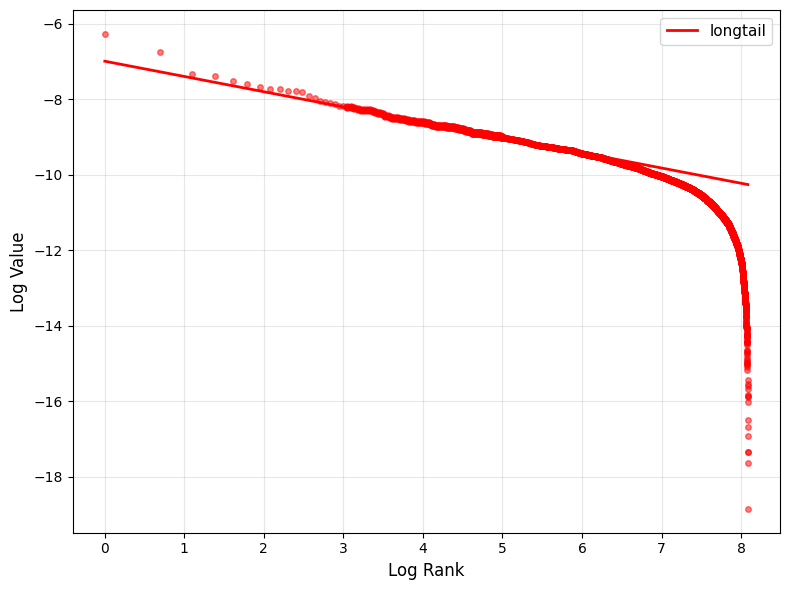

In [7]:
min_pct = 0
max_pct = 15
model = "gpt2-xl"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


3209


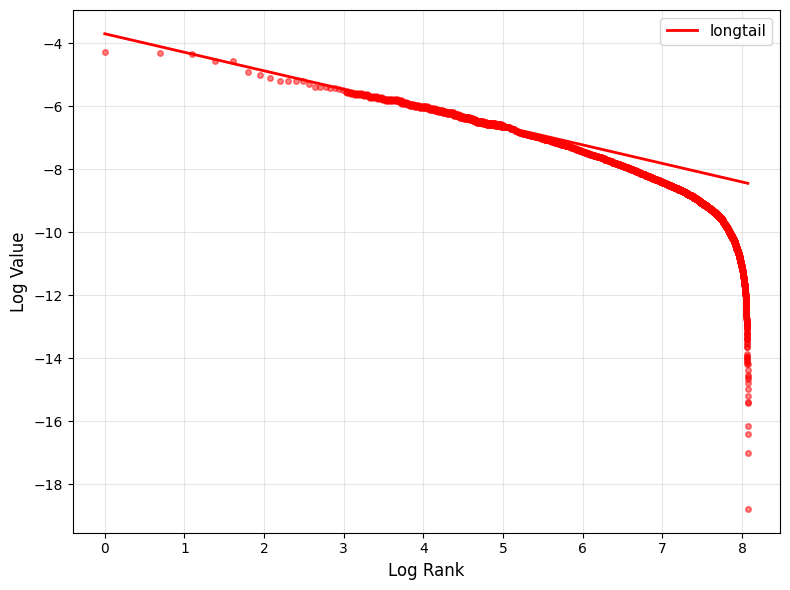

In [11]:
min_pct = 85
max_pct = 100
model = "gpt2-xl"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


1899


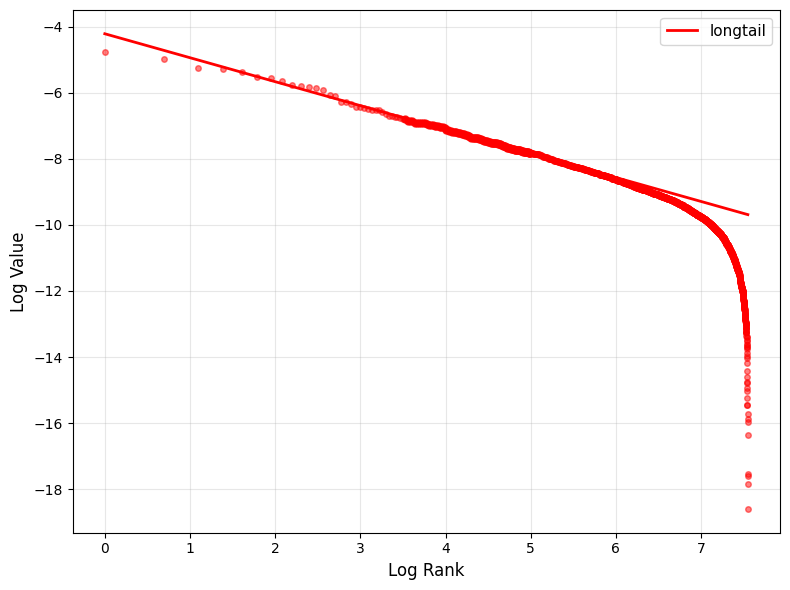

In [14]:
min_pct = 0
max_pct = 10
model = "EleutherAI/pythia-1B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3.5, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


4550


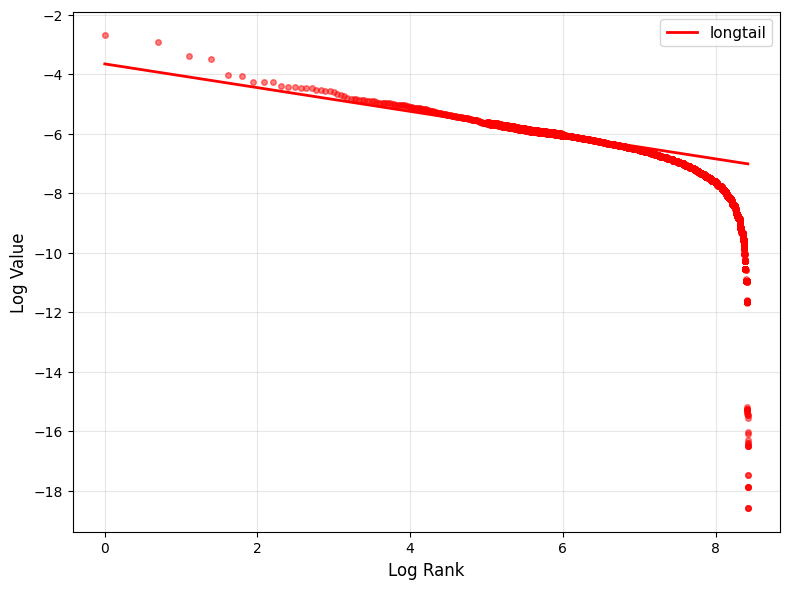

In [17]:
min_pct = 90
max_pct = 100
model = "EleutherAI/pythia-1B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(5, 6)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


1751


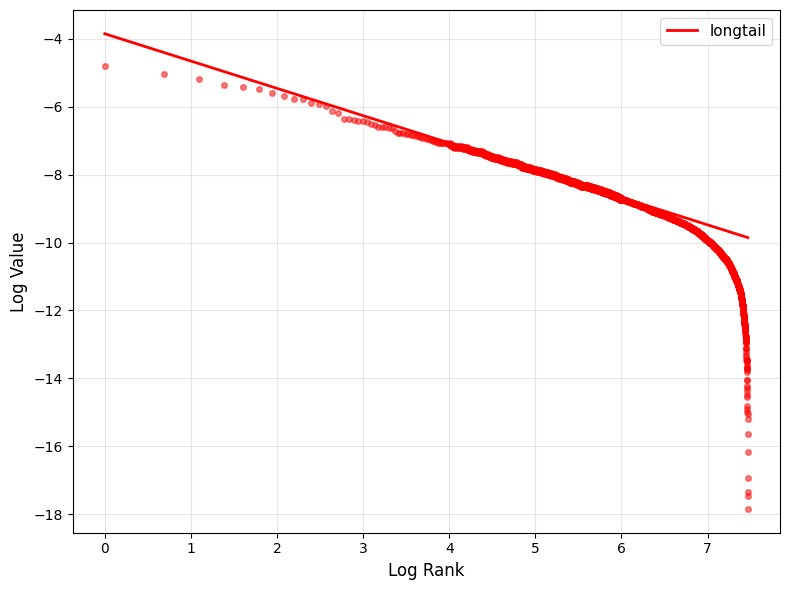

In [21]:
min_pct = 0
max_pct = 15
model = "EleutherAI/pythia-1B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(4, 6)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


3203


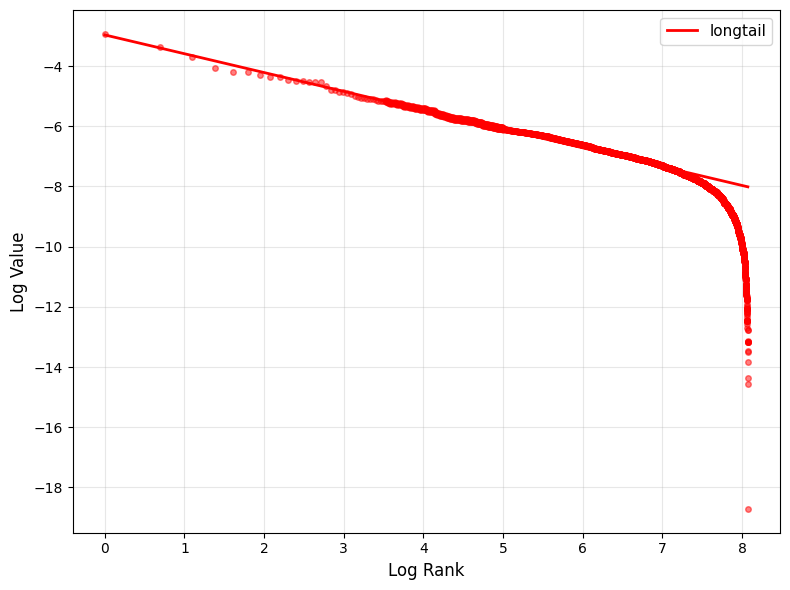

In [22]:
min_pct = 85
max_pct = 100
model = "EleutherAI/pythia-1B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3.5, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


4001


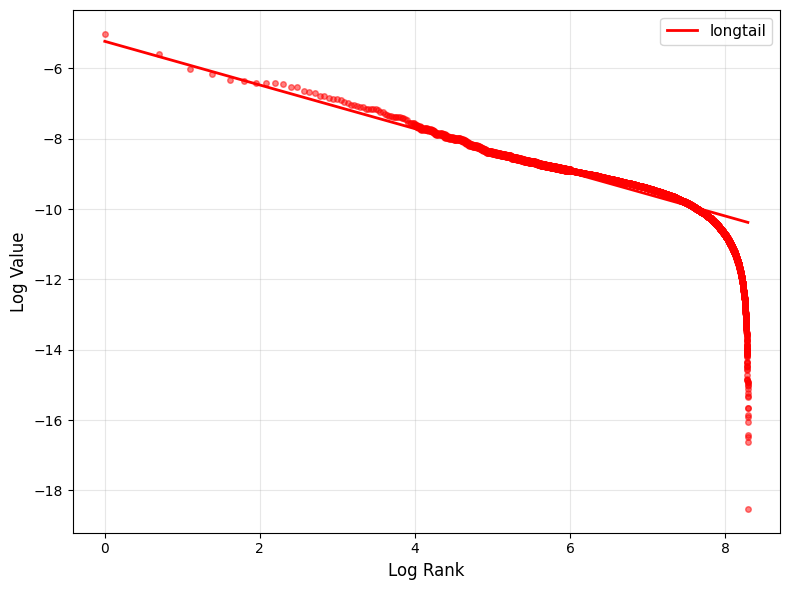

In [24]:
min_pct = 0
max_pct = 10
model = "EleutherAI/pythia-2.8B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(4, 6)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


6935


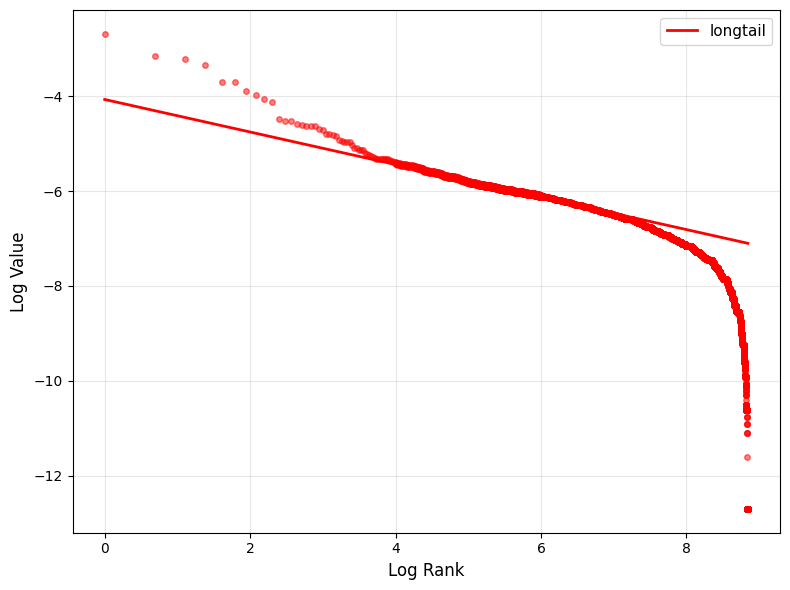

In [25]:
min_pct = 90
max_pct = 100
model = "EleutherAI/pythia-2.8B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(4, 6)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
